# Facies / Lithology Classification — Sandy-Shaly Basins
## Rock & Fluid Multiphysics Lab · IIT Roorkee
**Project:** Developing and fine-tuning AI models to identify facies/lithology in sandy-shaly basins  
**Intern:** Sameer Modi · B.Tech 3rd Year · Geological Technology · Roll No: 23410030  
**Supervisor:** Prof. Ravi Sharma · Department of Earth Sciences

---

### Wells & Basins

| Well | Basin | Sub-basin | State |
|------|-------|-----------|-------|
| Well 1 | Gondwana | Raniganj | West Bengal |
| Well 2 | Gondwana | Raniganj | West Bengal |
| Well 3 | Gondwana | Jharia   | Jharkhand |
| Well 4 | Gondwana | Jharia   | Jharkhand |

### 7 Target Facies Classes

| Code | Full Name | Geologic meaning |
|------|-----------|-----------------|
| `SST` | Sandstone | Clean / pure sandstone, all grain sizes |
| `SS` | Shaly Sandstone | Sandy shale or shaly sandstone — transitional |
| `DGS` | Dark Grey Shale | Organic-rich dark shale |
| `GS` | Grey Shale | General grey shale — catch-all |
| `Carb Shale` | Carbonaceous Shale | High-carbon shale |
| `Coal` | Coal / Shaly Coal | Coal seams |
| `Alt` | Alternate Sh/SST | Thinly interbedded shale + sandstone |

### Notebook Structure

| Phase | Title | Output |
|-------|-------|--------|
| **Phase 0** | Data Preparation | `wells_merged_classified.csv` |
| **Phase 1** | Exploratory Data Analysis | Crossplots, log plots, distribution charts |
| **Phase 2** | Feature Engineering | `wells_features.csv` |
| **Phase 3** | Train/Test Split & Scaling | Well-based split, StandardScaler |
| **Phase 4** | Model Training | Random Forest, XGBoost, 1D CNN |
| **Phase 5** | Evaluation | Accuracy, F1, confusion matrix, feature importance |
| **Phase 6** | Log Plot Visualisation | Predicted vs actual facies depth tracks |

> **How to run:** Execute all cells top to bottom. Each phase builds on the previous one.  
> Input files required: `Well_1_data.csv` … `Well_4_data.csv` + `Well_Data_Lithology.xlsx`


---
## Environment Setup

In [1]:
# ── Install (Colab only — uncomment if needed) ────────────────────────
# !pip install openpyxl pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow -q

# ── Standard library ──────────────────────────────────────────────────
import os
import warnings
import joblib
import time
warnings.filterwarnings('ignore')

# ── Data & numerics ───────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Plotting ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde

# ── Scikit-learn — ALL imports here so nothing is missing downstream ──
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample as sk_resample
from sklearn.model_selection import StratifiedShuffleSplit

# ── SVM ───────────────────────────────────────────────────────────────
from sklearn.svm import LinearSVC, SVC

# ── KNN ───────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

# ── XGBoost ───────────────────────────────────────────────────────────
import xgboost as xgb

# ── TensorFlow / Keras ────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Excel reader ──────────────────────────────────────────────────────
import openpyxl

# ── Reproducibility ───────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Global plot style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f9f9f9',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
})

print("✓ All libraries imported successfully")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  sklearn     {__import__('sklearn').__version__}")
print(f"  xgboost     {xgb.__version__}")
print(f"  tensorflow  {tf.__version__}")
print(f"  random seed : {RANDOM_STATE}")


✓ All libraries imported successfully
  pandas      2.2.2
  numpy       2.0.2
  sklearn     1.6.1
  xgboost     3.2.0
  tensorflow  2.20.0
  random seed : 42


### File Paths
> **Colab users:** Upload all 5 files via the sidebar, then set `DATA_DIR = '/content/'`  
> **Local users :** Set `DATA_DIR` to the folder containing your files


In [2]:
!unzip /content/Facies.zip

Archive:  /content/Facies.zip
   creating: Facies/
  inflating: Facies/Well_1_data.csv  
  inflating: Facies/Well_2_data.csv  
  inflating: Facies/Well_3_data.csv  
  inflating: Facies/Well_4_data.csv  
  inflating: Facies/Well_Data_Lithology.xlsx  


In [3]:
# ── Set DATA_DIR to wherever your files are ───────────────────────────
DATA_DIR   = '/content/Facies'         # ← change this if needed
OUTPUT_DIR = './'                            # ← output CSVs saved here

# Input files
WELL_CSV  = {i: os.path.join(DATA_DIR, f'Well_{i}_data.csv') for i in range(1, 5)}
LITH_XLSX = os.path.join(DATA_DIR, 'Well_Data_Lithology.xlsx')

# Output files
OUTPUT_MERGED   = os.path.join(OUTPUT_DIR, 'wells_merged_classified.csv')
OUTPUT_FEATURES = os.path.join(OUTPUT_DIR, 'wells_features.csv')

# Verify all inputs exist
print("Input file check:")
all_found = True
for path in list(WELL_CSV.values()) + [LITH_XLSX]:
    found = os.path.exists(path)
    print(f"  {'✓' if found else '✗ NOT FOUND':<12} {path}")
    if not found:
        all_found = False
print()
print("✓ All files found — ready to run!" if all_found else "✗ Fix missing files before continuing")


Input file check:
  ✓            /content/Facies/Well_1_data.csv
  ✓            /content/Facies/Well_2_data.csv
  ✓            /content/Facies/Well_3_data.csv
  ✓            /content/Facies/Well_4_data.csv
  ✓            /content/Facies/Well_Data_Lithology.xlsx

✓ All files found — ready to run!


---
# Phase 0 — Data Preparation

**Goal :** Load raw well log CSVs and lithology Excel, standardise column names, remove bad rows, clean nulls, merge on depth, and assign a `Facies` label to every sample.

### Pipeline steps in this phase

```
0.1  Global constants & column maps
0.2  Facies classification function
0.3  Load & standardise well log CSVs
0.4  Remove startup / tail rows
0.5  Preprocessing — nulls & physical bounds
0.6  Load lithology from Excel
0.7  Merge logs + lithology on nearest depth
0.8  Combine all wells & filter non-reservoir rows
0.9  Save & quick check
```


## 0.1 — Global Constants & Column Maps

In [4]:
# ══════════════════════════════════════════════════════════════════════
# GLOBAL CONSTANTS
# ══════════════════════════════════════════════════════════════════════

# ── Sentinel null values used by LAS / logging software ───────────────
# Raw CSVs use -99999 (and variants) to represent "no data".
# pandas treats these as valid numbers — we must replace them with NaN.
NULL_SENTINELS = [-99999, -9999, -999, 9999, 99999]

# ── Feature columns — present in ALL 4 wells, same physical quantity ──
# RES(64N) and SANG[DEG] are EXCLUDED — only in Wells 1 & 2.
# Using partial-well columns would prevent cross-well prediction.
LOG_FEATURES = [
    'CALIPER[CM]',  # borehole caliper — unified to CM for all wells
    'DEN[G/CC]',    # bulk density
    'GAM[API]',     # gamma ray
    'RES(16N)',      # shallow resistivity (16-inch spacing)
    'RES[OHM]',     # deep resistivity
    'SP[MV]',        # spontaneous potential
]

# ── Target facies classes (confirmed with Ravi Sir) ───────────────────
# Original 7-class order — used in Phase 1 EDA (BEFORE the DGS merge)
# DGS rows still exist in the data at this point — must show them in plots
FACIES_ORDER_ORIG = ['SST', 'SS', 'DGS', 'GS', 'Carb Shale', 'Coal', 'Alt']

# 6-class order — used from Section 2.1a onwards (AFTER DGS→GS relabel)
# DGS rows are NOT dropped; their label is changed to GS
FACIES_ORDER = ['SST', 'SS', 'GS', 'Carb Shale', 'Coal', 'Alt']

# ── Consistent colour palette for all visualisations ──────────────────
FACIES_COLORS = {
    'SST'       : '#F4A261',   # orange       — clean sandstone
    'SS'        : '#E9C46A',   # yellow       — shaly sandstone
    'DGS'       : '#457B9D',   # steel blue   — dark grey shale (Phase 1 only)
    'GS'        : '#A8DADC',   # light cyan   — grey shale
    # After Section 2.1a merge: GS covers both GS + DGS rows
    'Carb Shale': '#6D6875',   # mauve        — carbonaceous shale
    'Coal'      : '#2D2D2D',   # near-black   — coal
    'Alt'       : '#95D5B2',   # mint green   — alternate sh/sst
}

# ── Well column name mapping ──────────────────────────────────────────
# Every well CSV uses different abbreviations for the same log.
# We rename each to a single standard name on load.
#
# CALIPER unit situation:
#   Wells 1 & 2 : header='CALIPER[' → values in INCHES (range 5–22 in)
#   Wells 3 & 4 : header='CALP[CM]' → values in CM (explicit in header)
#   Fix applied in load_well_log(): Wells 1 & 2 multiplied by 2.54 → CM
#   So CALIPER[CM] is truly in CM for all 4 wells after loading.
#
# Columns deliberately dropped (not in WELL_COL_MAP):
#   RES(64N)  — deep 64-inch resistivity — only Wells 1 & 2
#   SANG[DEG] — sonic/deviation angle   — only Wells 1 & 2

WELL_COL_MAP = {
    1: {
        'DEPT[M]'  : 'DEPT[M]',
        'CALIPER[' : 'CALIPER[CM]',   # inches → converted ×2.54 after load
        'DEN(CDL)' : 'DEN[G/CC]',
        'GAM(NAT)' : 'GAM[API]',
        'RES(16N)' : 'RES(16N)',
        'RES[OHM]' : 'RES[OHM]',
        'SP[MM]'   : 'SP[MV]',
        # RES(64N)  → not mapped → dropped automatically
        # SANG[DEG] → not mapped → dropped automatically
    },
    2: {
        'DEPT[M]'  : 'DEPT[M]',
        'CALIPER[' : 'CALIPER[CM]',   # inches → converted ×2.54 after load
        'DEN(CDL)' : 'DEN[G/CC]',
        'GAM(NAT)' : 'GAM[API]',
        'RES(16N)' : 'RES(16N)',
        'RES[OHM]' : 'RES[OHM]',
        'SP[MV]'   : 'SP[MV]',
        # RES(64N)  → dropped
        # SANG[DEG] → dropped
    },
    3: {
        'DEPT[M]'  : 'DEPT[M]',
        'CALP[CM]' : 'CALIPER[CM]',   # already in CM — no conversion
        'DENS[G/C' : 'DEN[G/CC]',
        'NGAMMA[A' : 'GAM[API]',
        'RES[OHM-' : 'RES[OHM]',
        'SPR[OHM]' : 'RES(16N)',       # shallow resistivity
        'SP[MV]'   : 'SP[MV]',
    },
    4: {
        'DEPT.M'      : 'DEPT[M]',
        'CALP.CM'     : 'CALIPER[CM]', # already in CM — no conversion
        'DENS.G/CC'   : 'DEN[G/CC]',
        'NGAM.API-GR' : 'GAM[API]',
        'RES.OHMM'    : 'RES[OHM]',
        'SPR.OHM'     : 'RES(16N)',
        'SP.MV'       : 'SP[MV]',
    },
}

# ── Physical validity bounds per log ──────────────────────────────────
# Values outside these ranges are instrument errors → replace with NaN.
# Bounds derived from petrophysics knowledge + actual data ranges.
PHYSICAL_BOUNDS = {
    'CALIPER[CM]' : ( 5.0,  50.0),    # ~2 inch to ~20 inch borehole
    'DEN[G/CC]'   : ( 0.8,   3.5),    # coal (~1.3) to dense rock (~3.2)
    'GAM[API]'    : ( 1.0, 600.0),    # always positive; max ~600 API
    'RES(16N)'    : ( 0.01, 2e5),     # shale (~1) to dry quartzite
    'RES[OHM]'    : ( 0.01, 2e5),     # same as above
    'SP[MV]'      : (-700,  300),     # strongly negative in clean sands
}

# Logs where 0 is physically impossible → replace 0 with NaN
# SP[MV] excluded — 0 mV is valid at the shale baseline
ZERO_IS_NULL_COLS = ['CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]']

# ── Startup row depth cutoffs (per well) ─────────────────────────────
# Rows shallower than min_depth or deeper than max_depth are dropped.
# These are instrument startup / bottom-tail rows where ALL logs are
# simultaneously 0 or -99999 — the tool had not started/had stopped.
# Cutoffs found by inspecting the transition zone in each CSV.
DEPTH_CUTOFFS = {
    # well : (min_valid_depth_m, max_valid_depth_m)
    1 : (2.86,  None),     # 117 all-zero startup rows at top
    2 : (3.40, 918.00),    # 158 null rows at top + 106 null rows at bottom
    3 : (1.84, 510.08),    # 92 mixed -99999 rows at top + 1 bad row at bottom
    4 : (None,  None),     # starts at 70 m — already clean
}

print("✓ All global constants defined")
print(f"  Log features     : {LOG_FEATURES}")
print(f"  Facies (7-class) : {FACIES_ORDER_ORIG}  ← Phase 1 EDA")
print(f"  Facies (6-class) : {FACIES_ORDER}  ← Phase 2+ modelling (DGS merged into GS)")
print(f"  Sentinel values  : {NULL_SENTINELS}")


✓ All global constants defined
  Log features     : ['CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']
  Facies (7-class) : ['SST', 'SS', 'DGS', 'GS', 'Carb Shale', 'Coal', 'Alt']  ← Phase 1 EDA
  Facies (6-class) : ['SST', 'SS', 'GS', 'Carb Shale', 'Coal', 'Alt']  ← Phase 2+ modelling (DGS merged into GS)
  Sentinel values  : [-99999, -9999, -999, 9999, 99999]


## 0.2 — Facies Classification Function

Classifies every raw lithology description string into one of 7 sedimentary facies  
(+ 2 excluded classes: `Top Soil`, `Basement`).

**Rules run in strict priority order — first match wins.**  
Order matters because many descriptions contain multiple rock-type words:  
- *"Grey shale with coal laminae"* → `GS` (shale is primary, coal is minor)  
- *"Shaly coal with carb shale band"* → `Coal` (shaly coal is primary — Rule 3 before Rule 4)  
- *"Carb shale with coal band"* → `Carb Shale` (carb shale primary, coal is band)


In [5]:
def classify_lithology(description):
    """
    Classify a raw lithology description string into one of 9 facies classes.

    Rules run in strict priority order — FIRST MATCH WINS.
    See inline comments for why each rule is placed where it is.

    Parameters
    ----------
    description : str  Raw text from LITHOLOGY DESCRIPTION column

    Returns
    -------
    str  One of: 'SST', 'SS', 'DGS', 'GS', 'Carb Shale', 'Coal',
                 'Alt', 'Basement', 'Top Soil', 'Unknown'
    """
    if not isinstance(description, str) or description.strip() == '':
        return 'Unknown'

    d = description.strip().lower()

    # ── RULE 1 : TOP SOIL ─────────────────────────────────────────────
    # Must be first — "top soil, fine grained sandstone" (Well-2) would
    # be misclassified as SST if the sandstone rule ran earlier.
    if 'top soil' in d or 'topsoil' in d:
        return 'Top Soil'

    # ── RULE 2 : BASEMENT ─────────────────────────────────────────────
    # Crystalline/metamorphic basement — not a reservoir facies.
    # Excluded from ML training entirely.
    if any(x in d for x in ['gneiss', 'schist', 'metamorphic',
                              'mud stone', 'mudstone', 'biotite', 'chlorite']):
        return 'Basement'

    # ── RULE 3 : SHALY COAL → Coal ────────────────────────────────────
    # ⚠ MUST come BEFORE Carb Shale (Rule 4).
    # "Shaly coal with carb shale band" contains BOTH 'shaly coal' AND
    # 'carb shale'. Shaly coal is the PRIMARY rock; carb shale is a
    # minor band inside it. Rule 3 before Rule 4 ensures primary wins.
    if any(x in d for x in ['shaly coal', 'coal/shaly']):
        return 'Coal'

    # ── RULE 4 : CARB SHALE ───────────────────────────────────────────
    # Now safe — shaly coal already returned Coal above.
    # "Carb shale with coal band" → Carb Shale (coal is a minor band).
    if any(x in d for x in ['carb shale', 'carb. shale', 'carbonaceous shale']):
        return 'Carb Shale'

    # ── RULE 5 : ALT (Alternate Shale / Sandstone) ────────────────────
    # Before DGS/GS — "Alternate shale and sandstone" contains "shale"
    # and would be swallowed by the generic shale check if placed later.
    # "Intercalation Sand=Shale" / "Sand>Shale" → equal or sand-dominant
    # interbedding → Alt.
    if any(x in d for x in ['alt sh', 'alterenate shale', 'alternate shale',
                              'intercalation sand=shale', 'alt sh/sst',
                              'shale sandstone intercalation',
                              'intercalation sand>shale']):
        return 'Alt'

    # ── RULE 6 : DGS (Dark Grey Shale) ───────────────────────────────
    # Before GS — "Dark grey shale with coal streaks" → DGS, not Coal.
    # (Dark shale is primary; coal streaks are minor.)
    if any(x in d for x in ['dark grey shale', 'dark gray shale',
                              'gray to dark gray shale']):
        return 'DGS'

    # ── RULE 7 : COAL (pure coal only) ───────────────────────────────
    # Shaly coal already handled in Rule 3.
    # Catches: "Coal", "Coal, broken", "Coal pyritic"
    # Does NOT catch: "Sandstone with coal bands" → SST
    #                 "Grey shale with coal laminae" → GS
    if 'coal' in d:
        has_other_primary = any(x in d for x in [
            'sandstone', 'sst', 'shale', 'grey shale',
            'gray shale', 'sandy shale'
        ])
        if not has_other_primary:
            return 'Coal'

    # ── RULE 8 : SS (Shaly Sandstone / Sandy Shale) ──────────────────
    # MUST come before SST (Rule 9).
    # "Shaly SST" contains the word 'sst' — if SST ran first it would
    # be wrongly classified as clean sandstone.
    # "Intercalation Sand<Shale" → shale-dominant → SS.
    if any(x in d for x in ['shaly sst', 'shaly sandstone', 'sandy shale',
                              'intercalation sand<shale', 'siltstone',
                              'silt stone', 'silty sst', 'silty shale',
                              'coaly shale', 'shale (sandy)']):
        return 'SS'

    # ── RULE 9 : SST (Sandstone) ─────────────────────────────────────
    # Any remaining sandstone not caught above.
    # Pure "Claystone" excluded — clay-dominated rock belongs in GS.
    if any(x in d for x in ['sandstone', 'sst', 'sand']):
        if 'claystone' not in d:
            return 'SST'

    # ── RULE 10 : GS (Grey Shale — catch-all) ────────────────────────
    # Broadest keywords — runs LAST so it only catches what nothing
    # else claimed. Also catches Claystone (clay-dominated → GS).
    if any(x in d for x in ['grey shale', 'gray shale', 'shale',
                              'clay', 'claystone']):
        return 'GS'

    return 'Unknown'


# ── Self-test: 12 edge cases covering every tricky scenario ───────────
TEST_CASES = [
    ('Carb shale with coal band',            'Carb Shale'),
    ('Grey shale with coal laminae',          'GS'),
    ('Dark grey shale with coal streaks',     'DGS'),
    ('Shaly SST',                             'SS'),
    ('Intercalation Sand>Shale',              'Alt'),
    ('Intercalation Sand<Shale',              'SS'),
    ('Granular sandstone with coal bands',    'SST'),
    ('Claystone',                             'GS'),
    ('Coal, broken',                          'Coal'),
    ('Top Soil, Fine graineded, Brown',       'Top Soil'),
    ('Biotite Gneiss',                        'Basement'),
    ('Shaly coal with carb shale band',       'Coal'),   # ← previously failing; fixed
]

print("── Classifier self-test ─────────────────────────────────────────")
all_pass = True
for desc, expected in TEST_CASES:
    got    = classify_lithology(desc)
    status = '✓' if got == expected else '✗ FAIL'
    if got != expected:
        all_pass = False
    print(f"  {status}  '{desc[:45]:<45}'  →  {got}")
print()
print("✓ All 12 tests passed!" if all_pass else "✗ Some tests FAILED — fix logic above")


── Classifier self-test ─────────────────────────────────────────
  ✓  'Carb shale with coal band                    '  →  Carb Shale
  ✓  'Grey shale with coal laminae                 '  →  GS
  ✓  'Dark grey shale with coal streaks            '  →  DGS
  ✓  'Shaly SST                                    '  →  SS
  ✓  'Intercalation Sand>Shale                     '  →  Alt
  ✓  'Intercalation Sand<Shale                     '  →  SS
  ✓  'Granular sandstone with coal bands           '  →  SST
  ✓  'Claystone                                    '  →  GS
  ✓  'Coal, broken                                 '  →  Coal
  ✓  'Top Soil, Fine graineded, Brown              '  →  Top Soil
  ✓  'Biotite Gneiss                               '  →  Basement
  ✓  'Shaly coal with carb shale band              '  →  Coal

✓ All 12 tests passed!


## 0.3 — Load & Standardise Well Log CSVs

For each well:
1. Read CSV
2. Rename columns to standard names (dropping `RES(64N)` and `SANG[DEG]` automatically)
3. Replace sentinel nulls (`-99999`) with `NaN`
4. Convert caliper from inches → CM for Wells 1 & 2
5. Tag each row with `WELL` number and `BASIN` name


In [6]:
def load_well_log(well_number):
    """
    Load one well's CSV, standardise column names, handle sentinel nulls,
    convert caliper units, and tag with well/basin metadata.

    Caliper unit conversion
    ───────────────────────
    Wells 1 & 2 : raw header 'CALIPER[' — values in INCHES → × 2.54 → CM
    Wells 3 & 4 : raw header 'CALP[CM]' — already in CM, no conversion
    Confirmed by raw data ranges: Wells 1&2 range 5–22 (inches),
    Wells 3&4 range 4–18 (cm). Both end up in CM after this function.

    Dropped columns (not in WELL_COL_MAP, so ignored on rename):
    RES(64N)  — only Wells 1 & 2 (deep 64-inch resistivity)
    SANG[DEG] — only Wells 1 & 2 (sonic/deviation angle)

    Parameters → well_number : int (1–4)
    Returns    → pd.DataFrame sorted by depth
    """
    df = pd.read_csv(WELL_CSV[well_number])

    # Rename raw headers → standard names
    # Columns NOT in the map are left with their original names
    df = df.rename(columns=WELL_COL_MAP[well_number])

    # Keep only columns we care about (drops RES(64N), SANG[DEG] etc.)
    keep = ['DEPT[M]'] + [c for c in LOG_FEATURES if c in df.columns]
    df   = df[[c for c in keep if c in df.columns]]

    # Replace sentinel null values with NaN
    for sentinel in NULL_SENTINELS:
        df.replace(sentinel, np.nan, inplace=True)

    # Caliper unit conversion: inches → CM for Wells 1 & 2
    # ALL 4 wells have caliper in INCHES despite Wells 3&4 header saying 'CM'.
    # Mean ~8.4 inches × 2.54 = 21.3 cm — matches standard 8.5 inch bit size.
    # Without this: 2.18σ feature shift between train (27cm) and test (8cm)
    # destroying cross-basin generalisation completely.
    if 'CALIPER[CM]' in df.columns:  # apply to ALL wells
        df['CALIPER[CM]'] = df['CALIPER[CM]'] * 2.54

    # Add identifiers
    df['WELL']  = well_number
    df['BASIN'] = 'Raniganj' if well_number <= 2 else 'Jharia'

    return df.sort_values('DEPT[M]').reset_index(drop=True)


# ── Load all 4 wells ──────────────────────────────────────────────────
print("Loading well log CSVs...")
log_dfs = {}
for w in [1, 2, 3, 4]:
    log_dfs[w] = load_well_log(w)
    d          = log_dfs[w]
    print(f"  Well {w}: {len(d):>6,} rows | "
          f"depth {d['DEPT[M]'].min():.2f}–{d['DEPT[M]'].max():.2f} m | "
          f"columns: {[c for c in d.columns if c not in ['WELL','BASIN']]}")

print()
print("Caliper range after unit conversion (all in CM):")
for w in [1, 2, 3, 4]:
    c     = log_dfs[w]['CALIPER[CM]'].dropna()
    c     = c[c > 0]
    basin = 'Raniganj' if w <= 2 else 'Jharia'
    print(f"  Well {w} ({basin}): {c.min():.2f}–{c.max():.2f} cm  mean={c.mean():.2f}")


Loading well log CSVs...
  Well 1: 39,125 rows | depth 0.52–783.00 m | columns: ['DEPT[M]', 'CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']
  Well 2: 45,994 rows | depth 0.24–920.10 m | columns: ['DEPT[M]', 'CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']
  Well 3: 25,506 rows | depth 0.00–510.10 m | columns: ['DEPT[M]', 'CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']
  Well 4: 56,375 rows | depth 70.00–1197.48 m | columns: ['DEPT[M]', 'CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']

Caliper range after unit conversion (all in CM):
  Well 1 (Raniganj): 18.31–47.61 cm  mean=27.55
  Well 2 (Raniganj): 13.08–54.43 cm  mean=26.79
  Well 3 (Jharia): 12.90–46.41 cm  mean=21.03
  Well 4 (Jharia): 11.02–26.63 cm  mean=21.50


## 0.4 — Remove Startup & Tail Rows

When a wireline logging tool is lowered/raised, it takes a few metres to stabilise.  
**Startup rows** have ALL log columns simultaneously showing `0` or `-99999` — the tool hasn't started reading.  
**Tail rows** at the bottom are the same: tool being pulled out, no valid signal.

These rows **cannot be imputed** — there is no underlying geological signal. Drop entirely.

| Well | Top rows dropped | Bottom rows dropped | Depth cutoffs |
|------|-----------------|--------------------:|--------------|
| 1 | 117 (0.52–2.84 m, all-zero) | 0 | min = 2.86 m |
| 2 | 158 (0.24–3.38 m, -99999) | 106 (918–920 m) | min = 3.40 m, max = 918.00 m |
| 3 | 92 (0.00–1.82 m, -99999) | 1 (510.10 m) | min = 1.84 m, max = 510.08 m |
| 4 | 0 (starts at 70 m, already clean) | 0 | — |


In [7]:
def remove_startup_rows(df, well_number):
    """
    Remove instrument startup rows from top and/or bottom of a well log.

    A startup row has ALL non-depth log columns simultaneously showing
    0 or -99999. The logging tool has not started (top) or has been
    pulled out (bottom). These rows have no geological signal and
    cannot be imputed — they must be dropped entirely.

    Cutoffs in DEPTH_CUTOFFS were determined by inspecting the
    transition zone (last bad row → first clean row) in each CSV.

    Parameters → df : pd.DataFrame, well_number : int
    Returns    → pd.DataFrame with startup/tail rows removed
    """
    min_depth, max_depth = DEPTH_CUTOFFS[well_number]
    n_before = len(df)

    if min_depth is not None:
        df = df[df['DEPT[M]'] >= min_depth]
    if max_depth is not None:
        df = df[df['DEPT[M]'] <= max_depth]

    n_dropped = n_before - len(df)
    return df.reset_index(drop=True), n_dropped


# ── Apply startup removal to all wells ───────────────────────────────
print("Removing startup / tail rows:")
print(f"  {'Well':<8} {'Dropped':>8} {'Remaining':>10} {'Depth range'}")
print(f"  {'-'*8} {'-'*8} {'-'*10} {'-'*25}")

total_dropped = 0
for w in [1, 2, 3, 4]:
    log_dfs[w], n_dropped = remove_startup_rows(log_dfs[w], w)
    total_dropped += n_dropped
    d = log_dfs[w]
    print(f"  Well {w}   {n_dropped:>8,} {len(d):>10,} "
          f"   {d['DEPT[M]'].min():.2f}–{d['DEPT[M]'].max():.2f} m")

print(f"\n  Total startup/tail rows removed: {total_dropped:,}")


Removing startup / tail rows:
  Well      Dropped  Remaining Depth range
  -------- -------- ---------- -------------------------
  Well 1        117     39,008    2.86–783.00 m
  Well 2        263     45,731    3.40–918.00 m
  Well 3         93     25,413    1.84–510.08 m
  Well 4          0     56,375    70.00–1197.48 m

  Total startup/tail rows removed: 473


## 0.5 — Preprocessing: Null Detection & Physical Validity

Three-layer cleaning strategy applied in this order:

1. **Sentinel re-run** — re-apply `-99999` → `NaN` (safety, in case any survived)
2. **Zero → NaN** — zero is physically impossible for density, GR, resistivity, caliper  
   *(SP excluded — 0 mV is valid at the shale baseline)*
3. **Physical bounds check** — values outside known instrument range → `NaN`  
   e.g. density > 3.5 g/cc or < 0.8 g/cc is instrument error, not geology

All checks use `if col in df.columns` — safe for Wells 3 & 4 which lack some columns.


In [8]:
def preprocess_well(df, well_number):
    """
    Three-layer null cleaning for one well's log data.

    1. Sentinel replacement  (-99999 etc.) → NaN
    2. Zero = Null  (impossible-zero logs) → NaN
    3. Physical bounds check               → NaN

    Uses `if col in df.columns` throughout to safely handle wells that
    are missing certain logs (e.g. Wells 3 & 4 have no RES(64N) or SANG[DEG]).

    Parameters → df : pd.DataFrame, well_number : int
    Returns    → pd.DataFrame cleaned
    """
    df = df.copy()
    print(f"\n── Well {well_number} ({'Raniganj' if well_number<=2 else 'Jharia'}) "
          f"─────────────────────────────────────────")

    # Layer 1 : Sentinel replacement (safety re-run)
    for sentinel in NULL_SENTINELS:
        df.replace(sentinel, np.nan, inplace=True)

    # Layer 2 : Zero → NaN for physically impossible zeros
    zero_counts = {}
    for col in ZERO_IS_NULL_COLS:
        if col not in df.columns:
            continue
        n = (df[col] == 0).sum()
        if n > 0:
            df[col] = df[col].replace(0, np.nan)
            zero_counts[col] = n

    if zero_counts:
        print("  Zero → NaN:")
        for col, n in zero_counts.items():
            print(f"    {col:<15}: {n:>5} zeros replaced")
    else:
        print("  No zero-null values found")

    # Layer 3 : Physical bounds check
    bounds_counts = {}
    for col, (lo, hi) in PHYSICAL_BOUNDS.items():
        if col not in df.columns:
            continue
        bad = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
        n   = bad.sum()
        if n > 0:
            df.loc[bad, col] = np.nan
            bounds_counts[col] = n

    if bounds_counts:
        print("  Out-of-bounds → NaN:")
        for col, n in bounds_counts.items():
            print(f"    {col:<15}: {n:>5} values outside physical range")
    else:
        print("  No out-of-range values found")

    # Summary
    present = [c for c in PHYSICAL_BOUNDS if c in df.columns]
    print("  Final null % per log:")
    for col in present:
        n   = df[col].isna().sum()
        pct = 100 * n / len(df)
        bar = '█' * int(pct / 2)
        print(f"    {col:<15}: {n:>6} ({pct:5.1f}%)  {bar}")

    return df


# ── Apply to all 4 wells ──────────────────────────────────────────────
print("Preprocessing all 4 wells...")
for w in [1, 2, 3, 4]:
    log_dfs[w] = preprocess_well(log_dfs[w], w)


Preprocessing all 4 wells...

── Well 1 (Raniganj) ─────────────────────────────────────────
  No zero-null values found
  Out-of-bounds → NaN:
    RES(16N)       :    45 values outside physical range
  Final null % per log:
    CALIPER[CM]    :      0 (  0.0%)  
    DEN[G/CC]      :      0 (  0.0%)  
    GAM[API]       :      0 (  0.0%)  
    RES(16N)       :     45 (  0.1%)  
    RES[OHM]       :      0 (  0.0%)  
    SP[MV]         :      0 (  0.0%)  

── Well 2 (Raniganj) ─────────────────────────────────────────
  Zero → NaN:
    CALIPER[CM]    :    21 zeros replaced
    GAM[API]       :    25 zeros replaced
  Out-of-bounds → NaN:
    CALIPER[CM]    :  1281 values outside physical range
    RES(16N)       :    40 values outside physical range
  Final null % per log:
    CALIPER[CM]    :   1303 (  2.8%)  █
    DEN[G/CC]      :      1 (  0.0%)  
    GAM[API]       :     26 (  0.1%)  
    RES(16N)       :     40 (  0.1%)  
    RES[OHM]       :      0 (  0.0%)  
    SP[MV]         :  

## 0.6 — Load Lithology Descriptions from Excel

In [9]:
def load_lithology(well_number):
    """
    Load lithology descriptions for one well from the Excel file.

    Each row: Depth (m) | LITHOLOGY DESCRIPTION | Formation
    Spacing is irregular (~3 m between entries) vs log data (0.02 m).
    Sorted by depth — required for merge_asof in the next step.

    Parameters → well_number : int (1–4)
    Returns    → pd.DataFrame [DEPT[M], LITHOLOGY DESCRIPTION, Formation]
    """
    wb    = openpyxl.load_workbook(LITH_XLSX, read_only=True)
    ws    = wb[f'Well-{well_number}']
    rows  = list(ws.iter_rows(min_row=2, values_only=True))   # skip header

    lith  = pd.DataFrame(rows, columns=['DEPT[M]', 'LITHOLOGY DESCRIPTION', 'Formation'])
    lith  = lith.dropna(subset=['DEPT[M]'])
    lith['DEPT[M]'] = pd.to_numeric(lith['DEPT[M]'], errors='coerce')
    lith  = lith.dropna(subset=['DEPT[M]'])
    lith  = lith.sort_values('DEPT[M]').reset_index(drop=True)

    return lith


# ── Load lithology for all wells ──────────────────────────────────────
print("Loading lithology descriptions from Excel...")
lith_dfs = {}
for w in [1, 2, 3, 4]:
    lith_dfs[w] = load_lithology(w)
    d           = lith_dfs[w]
    print(f"  Well {w}: {len(d):>4} descriptions | "
          f"depth {d['DEPT[M]'].min():.1f}–{d['DEPT[M]'].max():.1f} m | "
          f"{d['LITHOLOGY DESCRIPTION'].nunique()} unique descriptions")


Loading lithology descriptions from Excel...
  Well 1:  584 descriptions | depth 3.0–783.0 m | 154 unique descriptions
  Well 2:  670 descriptions | depth 3.0–917.2 m | 202 unique descriptions
  Well 3:  445 descriptions | depth 0.1–510.5 m | 11 unique descriptions
  Well 4:  969 descriptions | depth 2.0–1207.0 m | 9 unique descriptions


## 0.7 — Merge Logs + Lithology on Nearest Depth

**Why `merge_asof` and not a regular join?**

Log data: one row every **0.02 m**. Lithology data: one row every **~3 m**.  
There is almost never an exact depth match between the two tables.

`merge_asof` assigns to every log row the lithology description from the  
**nearest depth point** in the lithology table, within a tolerance of 3 m.  
Log rows with no match within 3 m receive `NaN` (edge of borehole).


In [10]:
def merge_log_lithology(well_number, tolerance_m=3.0):
    """
    Merge wireline log (0.02 m spacing) with lithology (~3 m spacing)
    using pandas merge_asof on nearest depth.

    Both DataFrames must be sorted by DEPT[M] before calling merge_asof.
    direction='nearest' finds the closest depth in either direction.
    tolerance=3.0 m rejects matches further than 3 m away (→ NaN).

    Parameters
    ----------
    well_number : int
    tolerance_m : float  max allowed gap in metres (default 3.0)

    Returns → pd.DataFrame merged
    """
    log_df  = log_dfs[well_number]
    lith_df = lith_dfs[well_number]

    merged = pd.merge_asof(
        left      = log_df,
        right     = lith_df,
        on        = 'DEPT[M]',
        direction = 'nearest',
        tolerance = tolerance_m,
    )

    matched_pct = 100 * merged['LITHOLOGY DESCRIPTION'].notna().mean()
    print(f"  Well {well_number}: {len(log_df):>6,} log rows → "
          f"{merged['LITHOLOGY DESCRIPTION'].notna().sum():>6,} matched "
          f"({matched_pct:.1f}%)")

    return merged


# ── Merge + classify all 4 wells ─────────────────────────────────────
print("Merging logs with lithology and classifying facies...")
merged_wells = {}
for w in [1, 2, 3, 4]:
    merged = merge_log_lithology(w)
    merged['Facies'] = merged['LITHOLOGY DESCRIPTION'].apply(classify_lithology)
    merged_wells[w]  = merged


Merging logs with lithology and classifying facies...
  Well 1: 39,008 log rows → 39,008 matched (100.0%)
  Well 2: 45,731 log rows → 45,519 matched (99.5%)
  Well 3: 25,413 log rows → 25,413 matched (100.0%)
  Well 4: 56,375 log rows → 56,375 matched (100.0%)


## 0.8 — Combine All Wells & Filter Non-Reservoir Rows

In [11]:
# ── Combine all 4 wells into one DataFrame ────────────────────────────
df_all = pd.concat(merged_wells.values(), ignore_index=True)
print(f"Combined (all wells): {len(df_all):,} rows")

# ── Drop rows with no lithology match ─────────────────────────────────
df_all = df_all.dropna(subset=['LITHOLOGY DESCRIPTION'])
print(f"After dropping unmatched depths: {len(df_all):,} rows")

# ── Separate sedimentary facies from excluded classes ─────────────────
# Top Soil and Basement are not reservoir facies — exclude from ML.
# 'Unknown' rows are descriptions that matched no rule — also excluded.
EXCLUDED = ['Top Soil', 'Basement', 'Unknown']
df_ml   = df_all[~df_all['Facies'].isin(EXCLUDED)].copy()
df_excl = df_all[ df_all['Facies'].isin(EXCLUDED)].copy()

print(f"\nRows for ML training       : {len(df_ml):,}")
print(f"Rows excluded (soil/bsmt)  : {len(df_excl):,}")
print(f"\nExcluded class breakdown:")
print(df_excl['Facies'].value_counts().to_string())

# ── Select and order final columns ────────────────────────────────────
FINAL_COLS = ['DEPT[M]', 'WELL', 'BASIN'] + LOG_FEATURES +              ['LITHOLOGY DESCRIPTION', 'Formation', 'Facies']
df = df_ml[[c for c in FINAL_COLS if c in df_ml.columns]].copy()


Combined (all wells): 166,527 rows
After dropping unmatched depths: 166,315 rows

Rows for ML training       : 162,829
Rows excluded (soil/bsmt)  : 3,486

Excluded class breakdown:
Facies
Basement    2490
Top Soil     996


## 0.9 — Save & Quick Check

In [12]:
# ── Save Phase 0 output ───────────────────────────────────────────────
df.to_csv(OUTPUT_MERGED, index=False)

print(f"✓ Saved: {OUTPUT_MERGED}")
print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Columns: {list(df.columns)}")

# ── Overall facies distribution ───────────────────────────────────────
print("\n── Facies distribution ──────────────────────────────────────────")
dist = df['Facies'].value_counts().reindex(FACIES_ORDER_ORIG)
for facies, count in dist.items():
    bar = '█' * int(count / 500)
    pct = 100 * count / len(df)
    print(f"  {facies:<12}: {count:>6,} ({pct:4.1f}%)  {bar}")

# ── Per-well breakdown ────────────────────────────────────────────────
print("\n── Per-well facies counts ───────────────────────────────────────")
pw = df.groupby(['WELL','Facies']).size().unstack(fill_value=0).reindex(columns=FACIES_ORDER_ORIG)
print(pw.to_string())

# ── Null check ────────────────────────────────────────────────────────
print("\n── Null check (log columns) ─────────────────────────────────────")
null_summary = df[LOG_FEATURES].isnull().sum()
print(null_summary.to_string())
print("✓ No nulls" if null_summary.sum() == 0 else "⚠ Nulls present — handle in Phase 2")

# ── Preview ───────────────────────────────────────────────────────────
print("\n── First 3 rows ─────────────────────────────────────────────────")
display(df.head(3))


✓ Saved: ./wells_merged_classified.csv
  Shape : 162,829 rows × 12 columns
  Columns: ['DEPT[M]', 'WELL', 'BASIN', 'CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]', 'LITHOLOGY DESCRIPTION', 'Formation', 'Facies']

── Facies distribution ──────────────────────────────────────────
  SST         : 70,976 (43.6%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  SS          : 29,741 (18.3%)  ███████████████████████████████████████████████████████████
  DGS         : 37,600 (23.1%)  ███████████████████████████████████████████████████████████████████████████
  GS          :  8,370 ( 5.1%)  ████████████████
  Carb Shale  :  1,317 ( 0.8%)  ██
  Coal        :  4,264 ( 2.6%)  ████████
  Alt         : 10,561 ( 6.5%)  █████████████████████

── Per-well facies counts ───────────────────────────────────────
Facies    SST     SS    DGS    GS  Carb Shale  Coal   Alt
WELL              

,DEPT[M],WELL,BASIN,CALIPER[CM],DEN[G/CC],GAM[API],RES(16N),RES[OHM],SP[MV],LITHOLOGY DESCRIPTION,Formation,Facies
490,12.66,1,Raniganj,32.456882,1.73248,86.0295,1178.36,3106.80,-196.126,"Fine graineded SST, ferrugenious, brownish",Raniganj,SST
491,12.68,1,Raniganj,32.456882,1.72202,84.4365,1538.72,3526.81,-196.126,"Fine graineded SST, ferrugenious, brownish",Raniganj,SST
492,12.70,1,Raniganj,32.458914,1.74685,82.8433,1539.05,3527.19,-142.801,"Fine graineded SST, ferrugenious, brownish",Raniganj,SST


---
# Phase 1 — Exploratory Data Analysis (EDA)

**Goal :** Understand the data before modelling — class distributions, log responses per facies,  
crossplots, depth profiles, correlation, and missing value patterns.

EDA answers three key questions:
1. **Are classes separable?** Do different facies produce clearly different log responses?
2. **Which logs are most useful?** High separation → strong ML feature
3. **Is the data clean?** Outliers, physically impossible values, missing patterns

### Log curve reference

| Log | Full name | High value = | Low value = |
|-----|-----------|-------------|------------|
| `GAM[API]` | Gamma Ray | Clay / shale | Clean sand |
| `DEN[G/CC]` | Bulk Density | Dense rock | Porous / coal |
| `RES[OHM]` | Resistivity | Hydrocarbon / dry | Saline shale |
| `SP[MV]` | Spontaneous Potential | Shale baseline | Sand (deflects) |
| `CALIPER[CM]` | Borehole diameter | Washed-out shale | Competent rock |
| `RES(16N)` | Shallow Resistivity | Near-borehole dry | Near-borehole wet |


## 1.1 — Facies Class Distribution

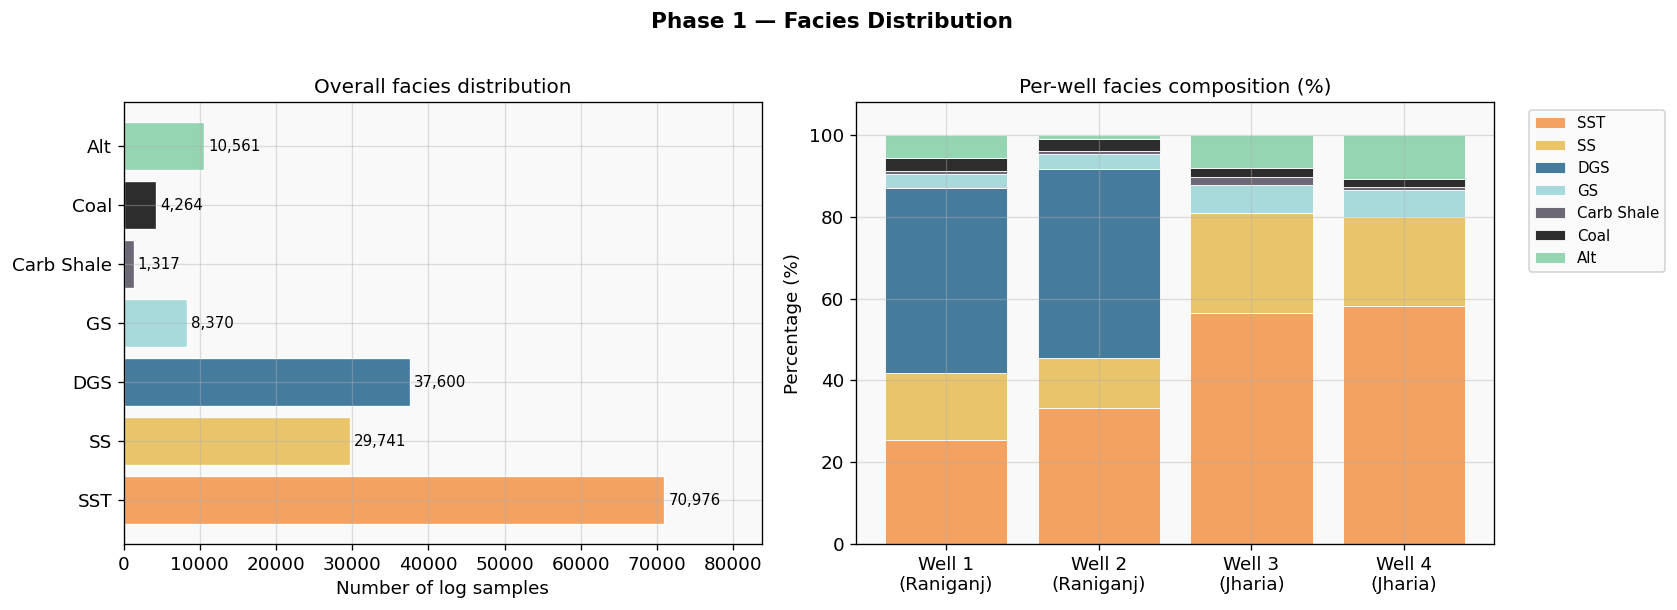

Class imbalance analysis:
  Largest class  (SST)       : 70,976 rows
  Smallest class (Carb Shale): 1,317 rows
  Imbalance ratio            : 54×
  → Use class_weight='balanced' or SMOTE in Phase 3 model training


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1 : Overall count ────────────────────────────────────────────
# Phase 1 uses FACIES_ORDER_ORIG (7 classes including DGS)
# DGS merge happens later in Section 2.1a
counts = df['Facies'].value_counts().reindex(FACIES_ORDER_ORIG)
colors = [FACIES_COLORS[f] for f in counts.index if f in FACIES_COLORS]
bars   = axes[0].barh(counts.index, counts.values,
                       color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Number of log samples')
axes[0].set_title('Overall facies distribution')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlim(0, counts.max() * 1.18)

# ── Plot 2 : Per-well stacked % bar ──────────────────────────────────
well_facies = (df.groupby(['WELL','Facies']).size()
                 .unstack(fill_value=0)
                 .reindex(columns=FACIES_ORDER_ORIG, fill_value=0))
well_pct    = well_facies.div(well_facies.sum(axis=1), axis=0) * 100
bottom      = np.zeros(4)
well_labels = [f'Well {w}\n({"Raniganj" if w<=2 else "Jharia"})' for w in [1,2,3,4]]

for facies in FACIES_ORDER_ORIG:
    vals = well_pct[facies].values
    axes[1].bar(well_labels, vals, bottom=bottom,
                color=FACIES_COLORS.get(facies, '#cccccc'), label=facies,
                edgecolor='white', linewidth=0.5)
    bottom += vals

axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Per-well facies composition (%)')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.28, 1.0), fontsize=9)
axes[1].set_ylim(0, 108)

plt.suptitle('Phase 1 — Facies Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p1_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Class imbalance summary ───────────────────────────────────────────
print("Class imbalance analysis:")
print(f"  Largest class  (SST)       : {counts.max():,} rows")
print(f"  Smallest class (Carb Shale): {counts.min():,} rows")
print(f"  Imbalance ratio            : {counts.max()/counts.min():.0f}×")
print("  → Use class_weight='balanced' or SMOTE in Phase 3 model training")


## 1.2 — Log Response per Facies (Box Plots)

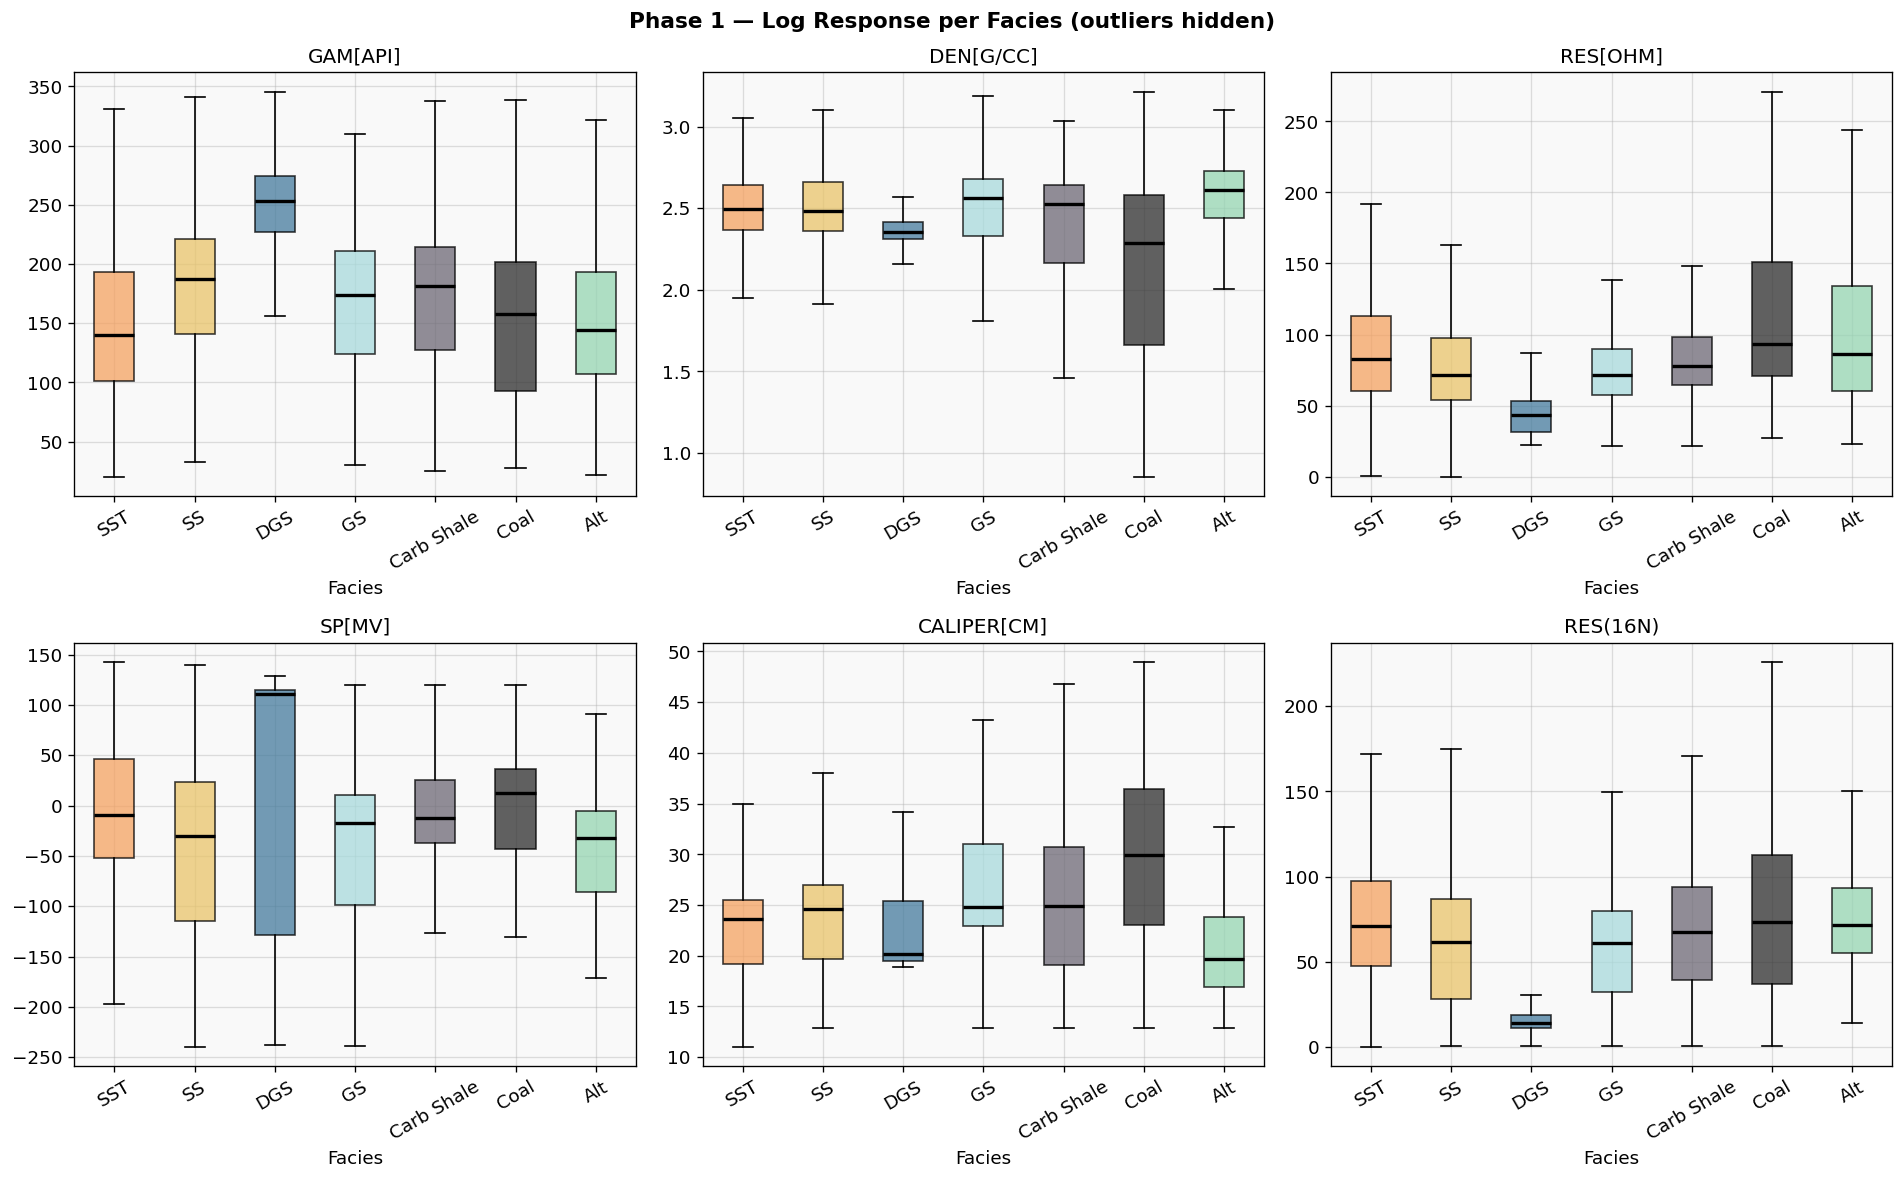

Mean log values per facies:


,GAM[API],DEN[G/CC],RES[OHM],SP[MV],CALIPER[CM],RES(16N)
Facies,,,,,,
SST,148.58,2.49,108.07,-7.89,24.48,83.46
SS,180.87,2.49,84.42,-37.28,25.51,64.07
DGS,248.18,2.37,46.73,-0.06,22.32,18.38
GS,168.89,2.48,79.27,-35.54,26.40,61.55
Carb Shale,174.07,2.35,117.48,-13.03,25.61,86.91
Coal,151.14,2.14,120.12,0.95,28.79,124.42
Alt,149.54,2.58,104.95,-32.19,20.68,78.13


In [14]:
LOG_COLS = ['GAM[API]', 'DEN[G/CC]', 'RES[OHM]', 'SP[MV]', 'CALIPER[CM]', 'RES(16N)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, log in zip(axes, LOG_COLS):
    data = [df.loc[df['Facies']==f, log].dropna().values for f in FACIES_ORDER_ORIG]
    bp   = ax.boxplot(data, labels=FACIES_ORDER_ORIG, patch_artist=True,
                      showfliers=False,
                      medianprops=dict(color='black', linewidth=2))
    for patch, facies in zip(bp['boxes'], FACIES_ORDER_ORIG):
        patch.set_facecolor(FACIES_COLORS.get(facies, '#cccccc'))
        patch.set_alpha(0.75)
    ax.set_title(log)
    ax.set_xlabel('Facies')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Phase 1 — Log Response per Facies (outliers hidden)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p1_02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Mean table ────────────────────────────────────────────────────────
print("Mean log values per facies:")
display(df.groupby('Facies')[LOG_COLS].mean().round(2).reindex(FACIES_ORDER_ORIG))


## 1.3 — Class Separability: KDE, Contours & Violin Plots

### Why not a raw scatter crossplot?

With 7 classes × 1500 points = **10,500 overlapping dots**, a raw scatter
plot is unreadable (as we saw). The classes occupy similar regions of
GR–Density space because they share overlapping geological properties.

### Better approaches used here

| Plot | What it shows | Why it helps |
|------|--------------|-------------|
| **KDE curves** | Probability distribution shape per class | Peaks that don't overlap = easily separable |
| **Contour crossplot** | The 20% density boundary of each class | Where classes truly cluster in 2D space |
| **Violin plots** | Median + IQR + distribution shape for all logs | Compare all 6 logs × 7 classes at once |

### Key separability findings (from the data)

| Log | Best separator for |
|-----|------------------|
| GR | **DGS** stands out clearly at ~248 API vs others at 148–181 |
| Density | **Coal** is distinctly low (~2.14 g/cc) vs all other classes |
| Resistivity | **DGS** is distinctly low (~47 ohm-m); Coal/SST are high |
| SP | **DGS** near zero (-0.1 mV); SS/GS/Alt strongly negative |
| Caliper | **Alt** has smallest borehole (12 cm); DGS/Coal largest (22–23 cm) |

These patterns confirm the model will rely heavily on GR, Density, and
Resistivity — consistent with the feature importance preview in Phase 2.


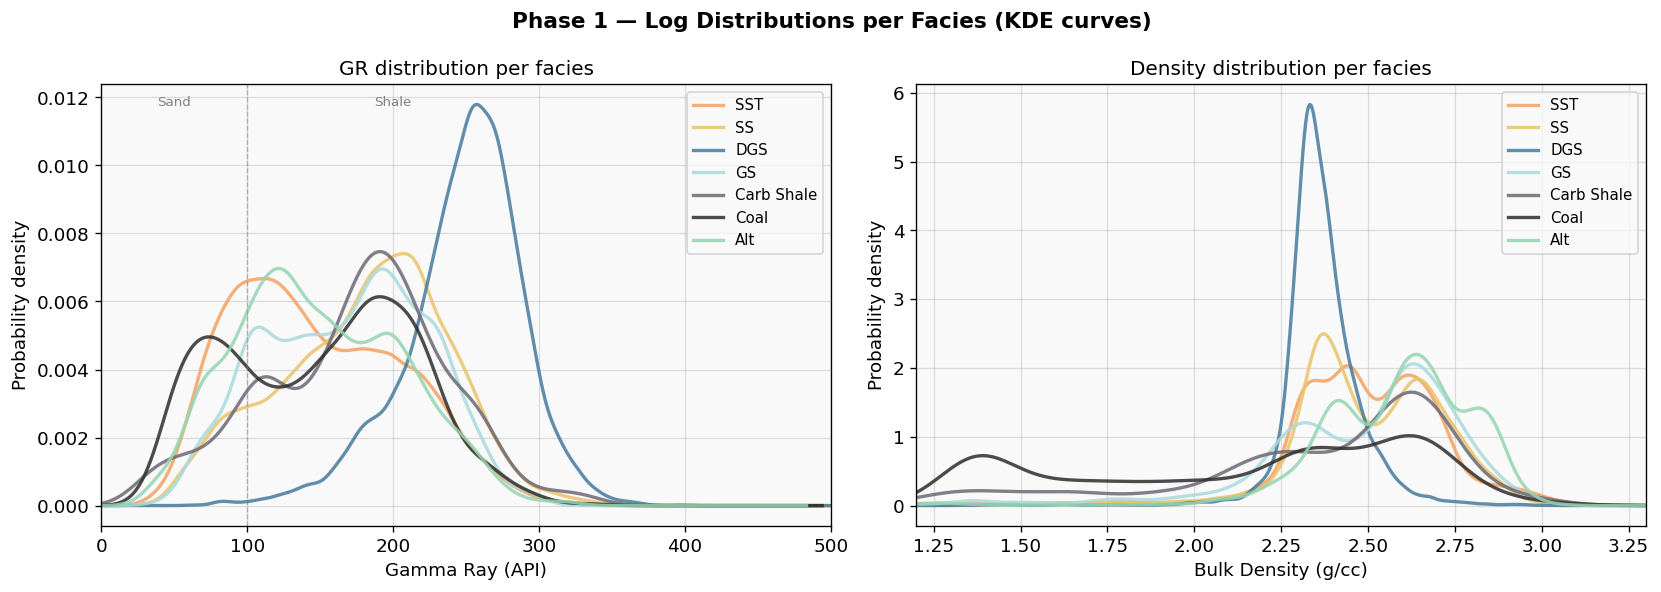

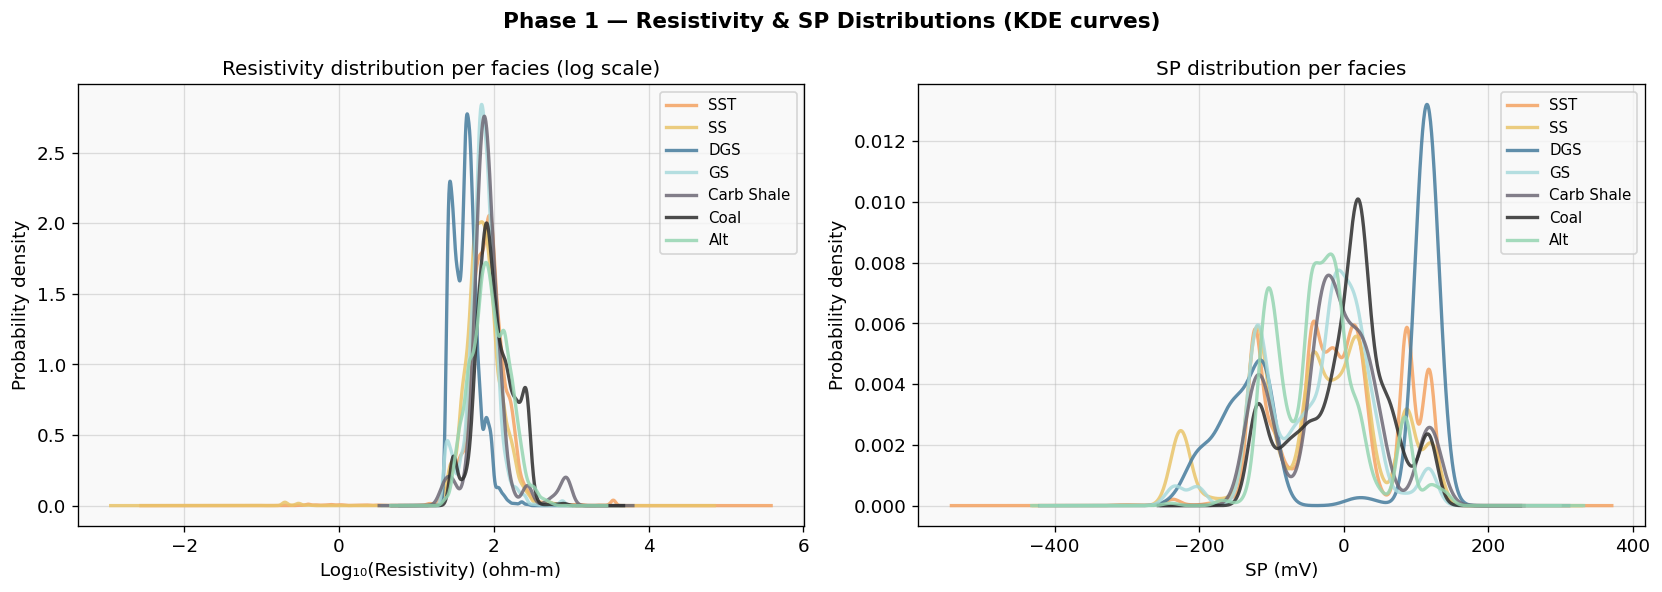

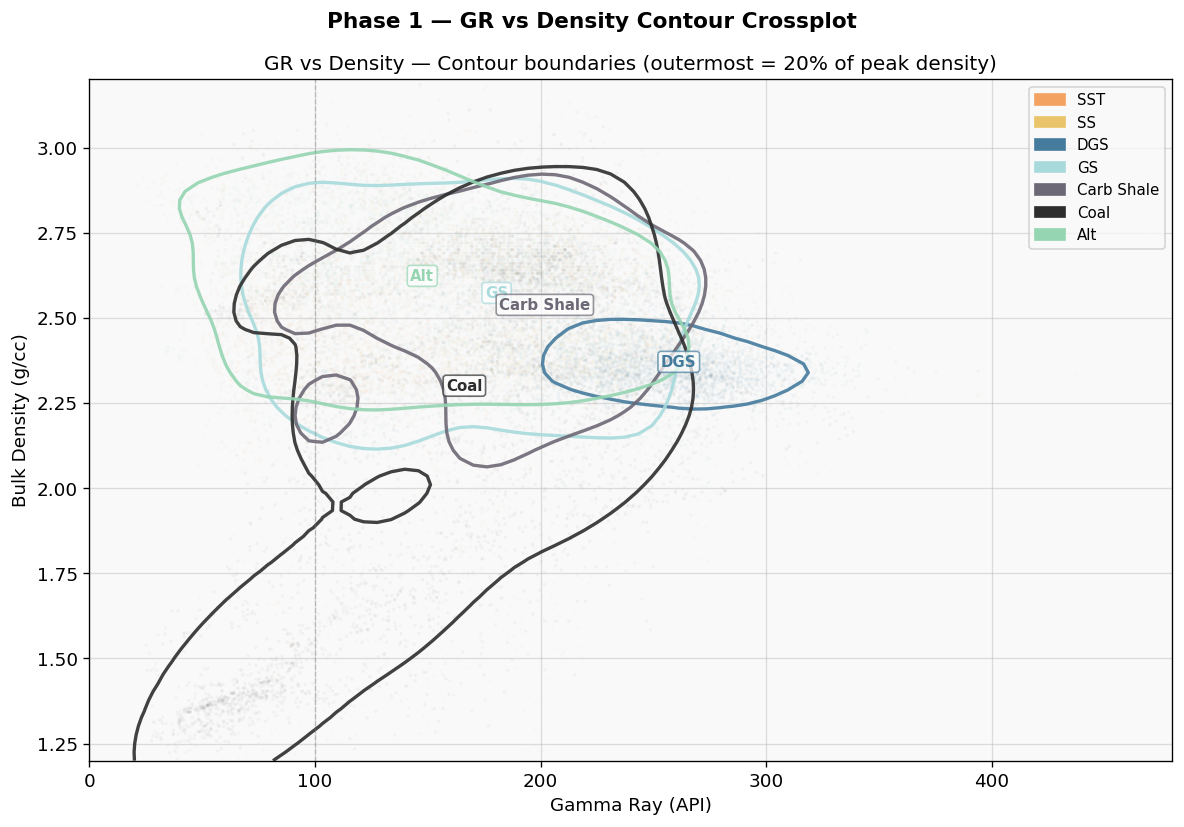

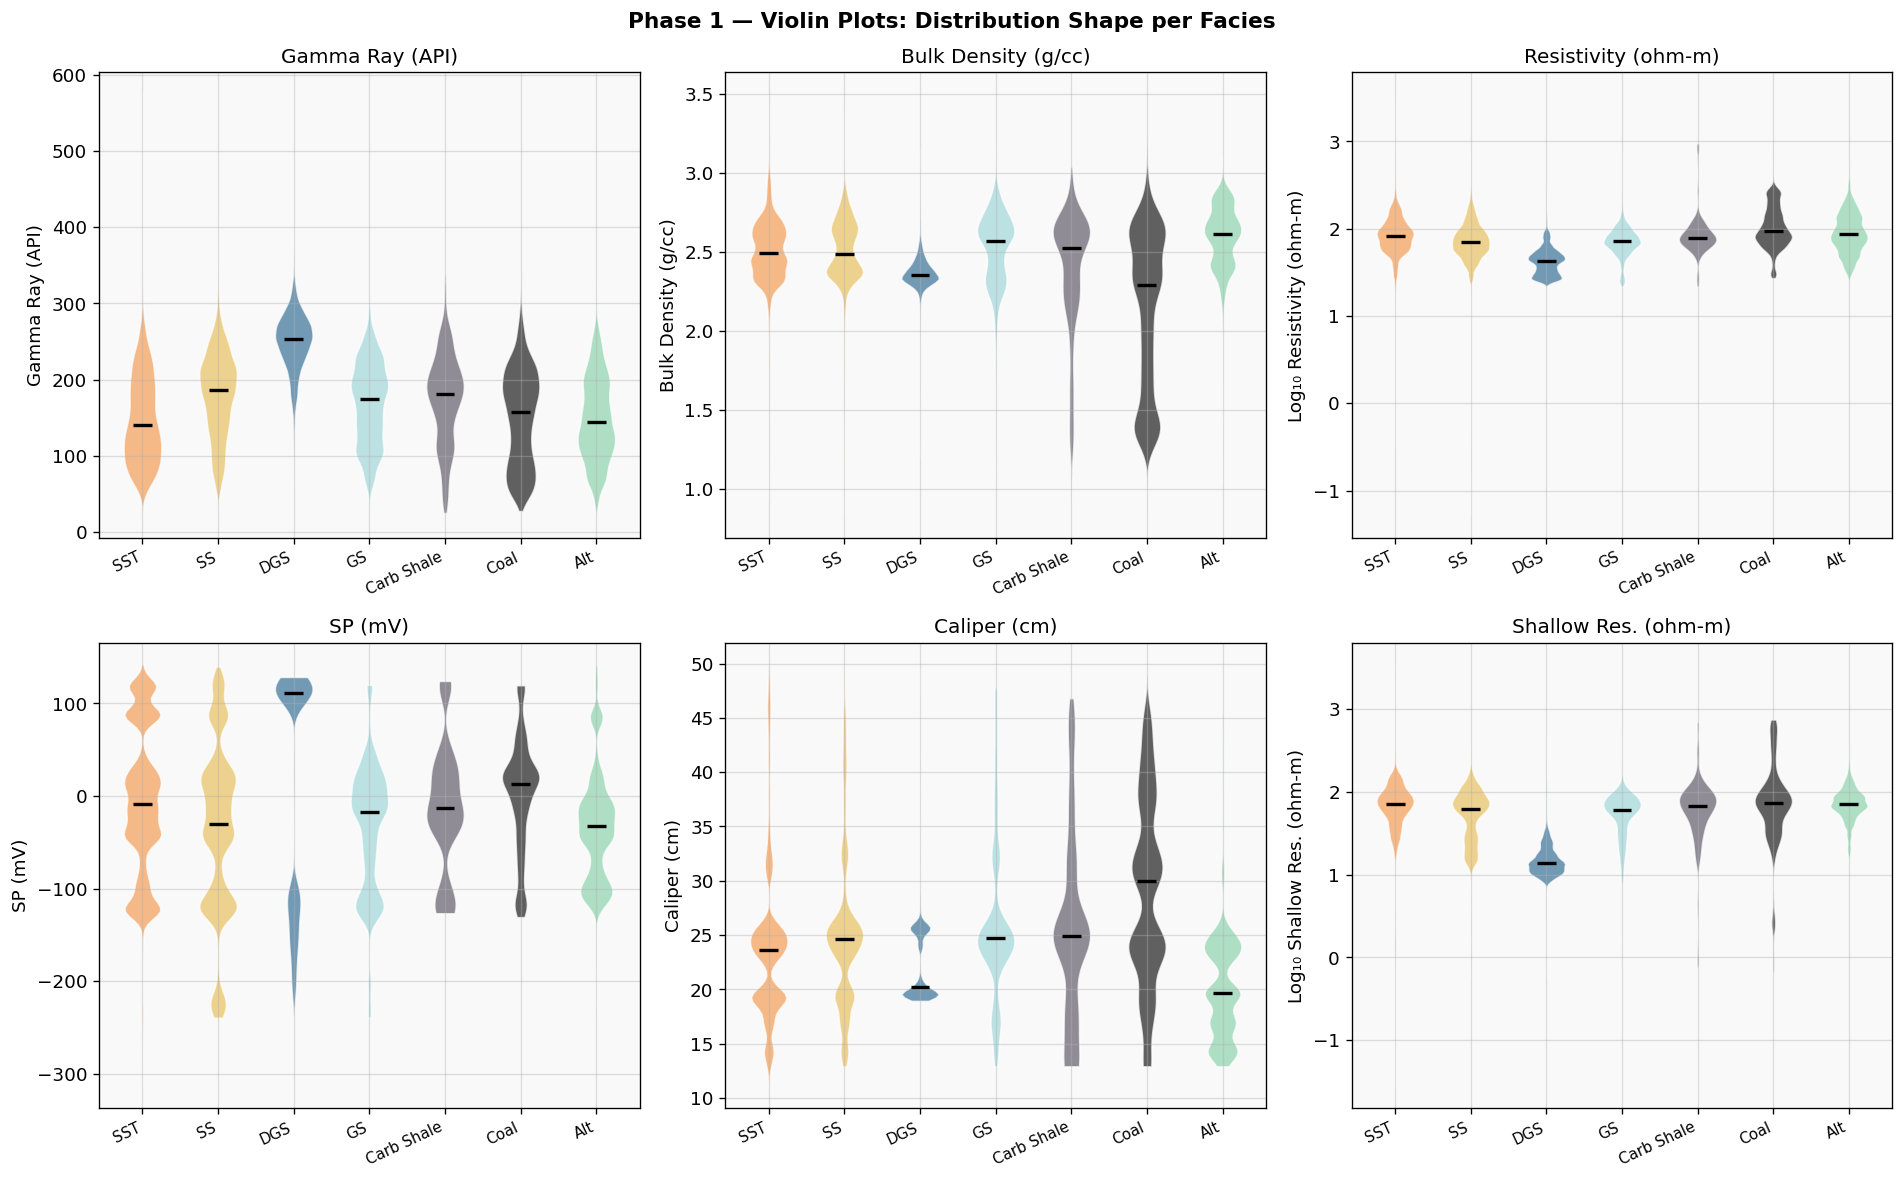

✓ 4 EDA plots generated:
  p1_03a_kde_gr_density.png  — KDE curves: GR and Density
  p1_03b_kde_res_sp.png      — KDE curves: Resistivity and SP
  p1_03c_contour_crossplot.png — Contour boundaries (GR vs Density)
  p1_03d_violin_plots.png    — Violin plots: all 6 logs

── Key separability observations ─────────────────────────────────
  GR  : Coal/SST/Alt (low ~150) vs DGS (high ~248) — best separator
  DEN : Coal very low (~2.14) vs Alt high (~2.58) — good for Coal
  RES : Coal/SST high vs DGS low (~47 ohm-m) — good separator
  SP  : DGS near zero (-0.1 mV) vs SS/GS/Alt strongly negative
  CAL : DGS/Coal large (22-23 cm borehole) vs Alt small (12 cm)


In [15]:
# ── Phase 1.3 — EDA Visualisations: 4 complementary plots ────────────
#
# Problem with raw scatter crossplots: 7 classes × 1500 points = 10,500
# overlapping dots — impossible to distinguish classes.
#
# Better approach: show DISTRIBUTION SHAPE per class, not individual points.
# We use 4 complementary plot types, each revealing something different.

FACIES_ORDER_ORIG = ['SST', 'SS', 'DGS', 'GS', 'Carb Shale', 'Coal', 'Alt']

# ── Plot 1 : KDE curves — GR and Density ──────────────────────────────
# KDE (Kernel Density Estimate) shows the probability distribution of each
# class as a smooth curve. Non-overlapping peaks = easy to classify.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for facies in FACIES_ORDER_ORIG:
    sub = df[df['Facies'] == facies]
    color = FACIES_COLORS.get(facies, '#cccccc')

    # GR distribution
    sub['GAM[API]'].plot.kde(ax=axes[0], label=facies,
                              color=color, linewidth=2.0, alpha=0.85)
    # Density distribution
    sub['DEN[G/CC]'].plot.kde(ax=axes[1], label=facies,
                               color=color, linewidth=2.0, alpha=0.85)

axes[0].set_xlabel('Gamma Ray (API)')
axes[0].set_ylabel('Probability density')
axes[0].set_title('GR distribution per facies')
axes[0].set_xlim(0, 500)
axes[0].legend(fontsize=9)
axes[0].axvline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].text(50, axes[0].get_ylim()[1]*0.95, 'Sand', fontsize=8, color='gray', ha='center')
axes[0].text(200, axes[0].get_ylim()[1]*0.95, 'Shale', fontsize=8, color='gray', ha='center')

axes[1].set_xlabel('Bulk Density (g/cc)')
axes[1].set_ylabel('Probability density')
axes[1].set_title('Density distribution per facies')
axes[1].set_xlim(1.2, 3.3)
axes[1].legend(fontsize=9)

plt.suptitle('Phase 1 — Log Distributions per Facies (KDE curves)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p1_03a_kde_gr_density.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2 : KDE curves — Resistivity and SP ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for facies in FACIES_ORDER_ORIG:
    sub   = df[df['Facies'] == facies]
    color = FACIES_COLORS.get(facies, '#cccccc')

    # log10 Resistivity (log scale compresses range for better KDE)
    np.log10(sub['RES[OHM]'].clip(lower=0.1)).plot.kde(
        ax=axes[0], label=facies, color=color, linewidth=2.0, alpha=0.85)

    # SP
    sub['SP[MV]'].clip(-400, 200).plot.kde(
        ax=axes[1], label=facies, color=color, linewidth=2.0, alpha=0.85)

axes[0].set_xlabel('Log₁₀(Resistivity) (ohm-m)')
axes[0].set_ylabel('Probability density')
axes[0].set_title('Resistivity distribution per facies (log scale)')
axes[0].legend(fontsize=9)

axes[1].set_xlabel('SP (mV)')
axes[1].set_ylabel('Probability density')
axes[1].set_title('SP distribution per facies')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 1 — Resistivity & SP Distributions (KDE curves)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p1_03b_kde_res_sp.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3 : Contour crossplot (GR vs Density) ────────────────────────
# Instead of 10,500 raw points, show density contours per class.
# Each class gets its own filled contour region — much more readable.
fig, ax = plt.subplots(figsize=(10, 7))

from scipy.stats import gaussian_kde

for facies in FACIES_ORDER_ORIG:
    sub   = df[df['Facies'] == facies].sample(min(3000, len(df[df['Facies']==facies])),
                                               random_state=42)
    color = FACIES_COLORS.get(facies, '#cccccc')
    x     = sub['GAM[API]'].values
    y     = sub['DEN[G/CC]'].values

    # Scatter with very low alpha (context only)
    ax.scatter(x, y, c=color, alpha=0.04, s=4, edgecolors='none')

    # Compute and plot the 50th percentile contour (median boundary)
    try:
        xy  = np.vstack([x, y])
        kde = gaussian_kde(xy, bw_method=0.3)
        xi  = np.linspace(0, 480, 80)
        yi  = np.linspace(1.2, 3.2, 80)
        Xi, Yi = np.meshgrid(xi, yi)
        Zi  = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
        # Plot only the outermost contour (50th percentile of density)
        ax.contour(Xi, Yi, Zi, levels=[Zi.max() * 0.2],
                   colors=[color], linewidths=2.0, alpha=0.9)
        # Label at the mean
        ax.annotate(facies,
                    xy=(np.median(x), np.median(y)),
                    fontsize=9, fontweight='bold',
                    color=color,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.7))
    except Exception:
        pass

ax.set_xlabel('Gamma Ray (API)', fontsize=11)
ax.set_ylabel('Bulk Density (g/cc)', fontsize=11)
ax.set_title('GR vs Density — Contour boundaries (outermost = 20% of peak density)')
ax.set_xlim(0, 480)
ax.set_ylim(1.2, 3.2)
ax.axvline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

# Legend
patches = [mpatches.Patch(color=FACIES_COLORS.get(f,'#ccc'), label=f) for f in FACIES_ORDER_ORIG]
ax.legend(handles=patches, loc='upper right', fontsize=9)

plt.suptitle('Phase 1 — GR vs Density Contour Crossplot',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p1_03c_contour_crossplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4 : Violin plots — all logs side by side ─────────────────────
# Violin = box plot + KDE shape. Shows median, IQR, AND distribution shape.
# Best for comparing spread and overlap across all classes at once.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

log_specs = [
    ('GAM[API]',   'Gamma Ray (API)',         None),
    ('DEN[G/CC]',  'Bulk Density (g/cc)',      None),
    ('RES[OHM]',   'Resistivity (ohm-m)',      'log'),
    ('SP[MV]',     'SP (mV)',                  None),
    ('CALIPER[CM]','Caliper (cm)',             None),
    ('RES(16N)',   'Shallow Res. (ohm-m)',     'log'),
]

for ax, (col, label, scale) in zip(axes, log_specs):
    data_per_class = []
    labels_present = []
    colors_present = []

    for facies in FACIES_ORDER_ORIG:
        vals = df[df['Facies']==facies][col].dropna().values
        if len(vals) > 10:
            if scale == 'log':
                vals = np.log10(np.clip(vals, 0.01, None))
            data_per_class.append(vals)
            labels_present.append(facies)
            colors_present.append(FACIES_COLORS.get(facies, '#cccccc'))

    parts = ax.violinplot(data_per_class, showmedians=True,
                           showextrema=False)

    # Colour each violin
    for pc, color in zip(parts['bodies'], colors_present):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    ax.set_xticks(range(1, len(labels_present)+1))
    ax.set_xticklabels(labels_present, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(('Log₁₀ ' if scale=='log' else '') + label)
    ax.set_title(label)

plt.suptitle('Phase 1 — Violin Plots: Distribution Shape per Facies',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p1_03d_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 4 EDA plots generated:")
print("  p1_03a_kde_gr_density.png  — KDE curves: GR and Density")
print("  p1_03b_kde_res_sp.png      — KDE curves: Resistivity and SP")
print("  p1_03c_contour_crossplot.png — Contour boundaries (GR vs Density)")
print("  p1_03d_violin_plots.png    — Violin plots: all 6 logs")

print("\n── Key separability observations ─────────────────────────────────")
print("  GR  : Coal/SST/Alt (low ~150) vs DGS (high ~248) — best separator")
print("  DEN : Coal very low (~2.14) vs Alt high (~2.58) — good for Coal")
print("  RES : Coal/SST high vs DGS low (~47 ohm-m) — good separator")
print("  SP  : DGS near zero (-0.1 mV) vs SS/GS/Alt strongly negative")
print("  CAL : DGS/Coal large (22-23 cm borehole) vs Alt small (12 cm)")


## 1.4 — Log Correlation Heatmap

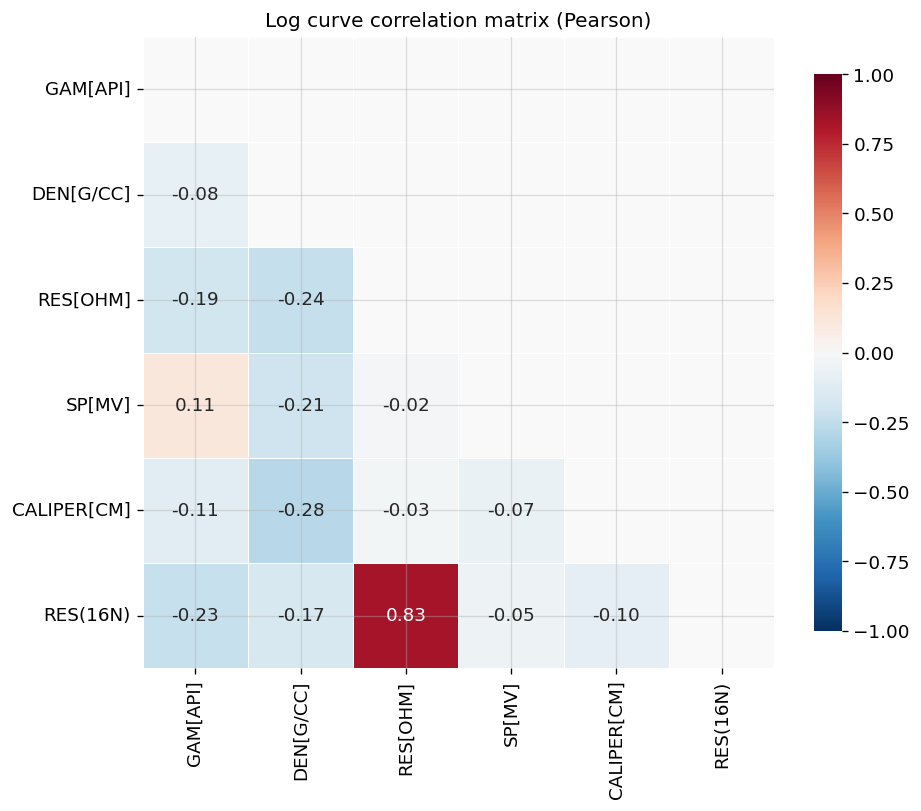

High correlations (|r| > 0.6):
  RES(16N) ↔ RES[OHM]: r = 0.83


In [16]:
corr = df[LOG_COLS].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Log curve correlation matrix (Pearson)')
plt.tight_layout()
plt.savefig('p1_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("High correlations (|r| > 0.6):")
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.6:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: r = {val:.2f}")


## 1.5 — Wireline Log Profile

Multi-track log plot — the standard geologist's visualisation of well data.  
Each track shows one log curve vs depth; the rightmost track is a colour-coded  
facies strip from the classified labels.


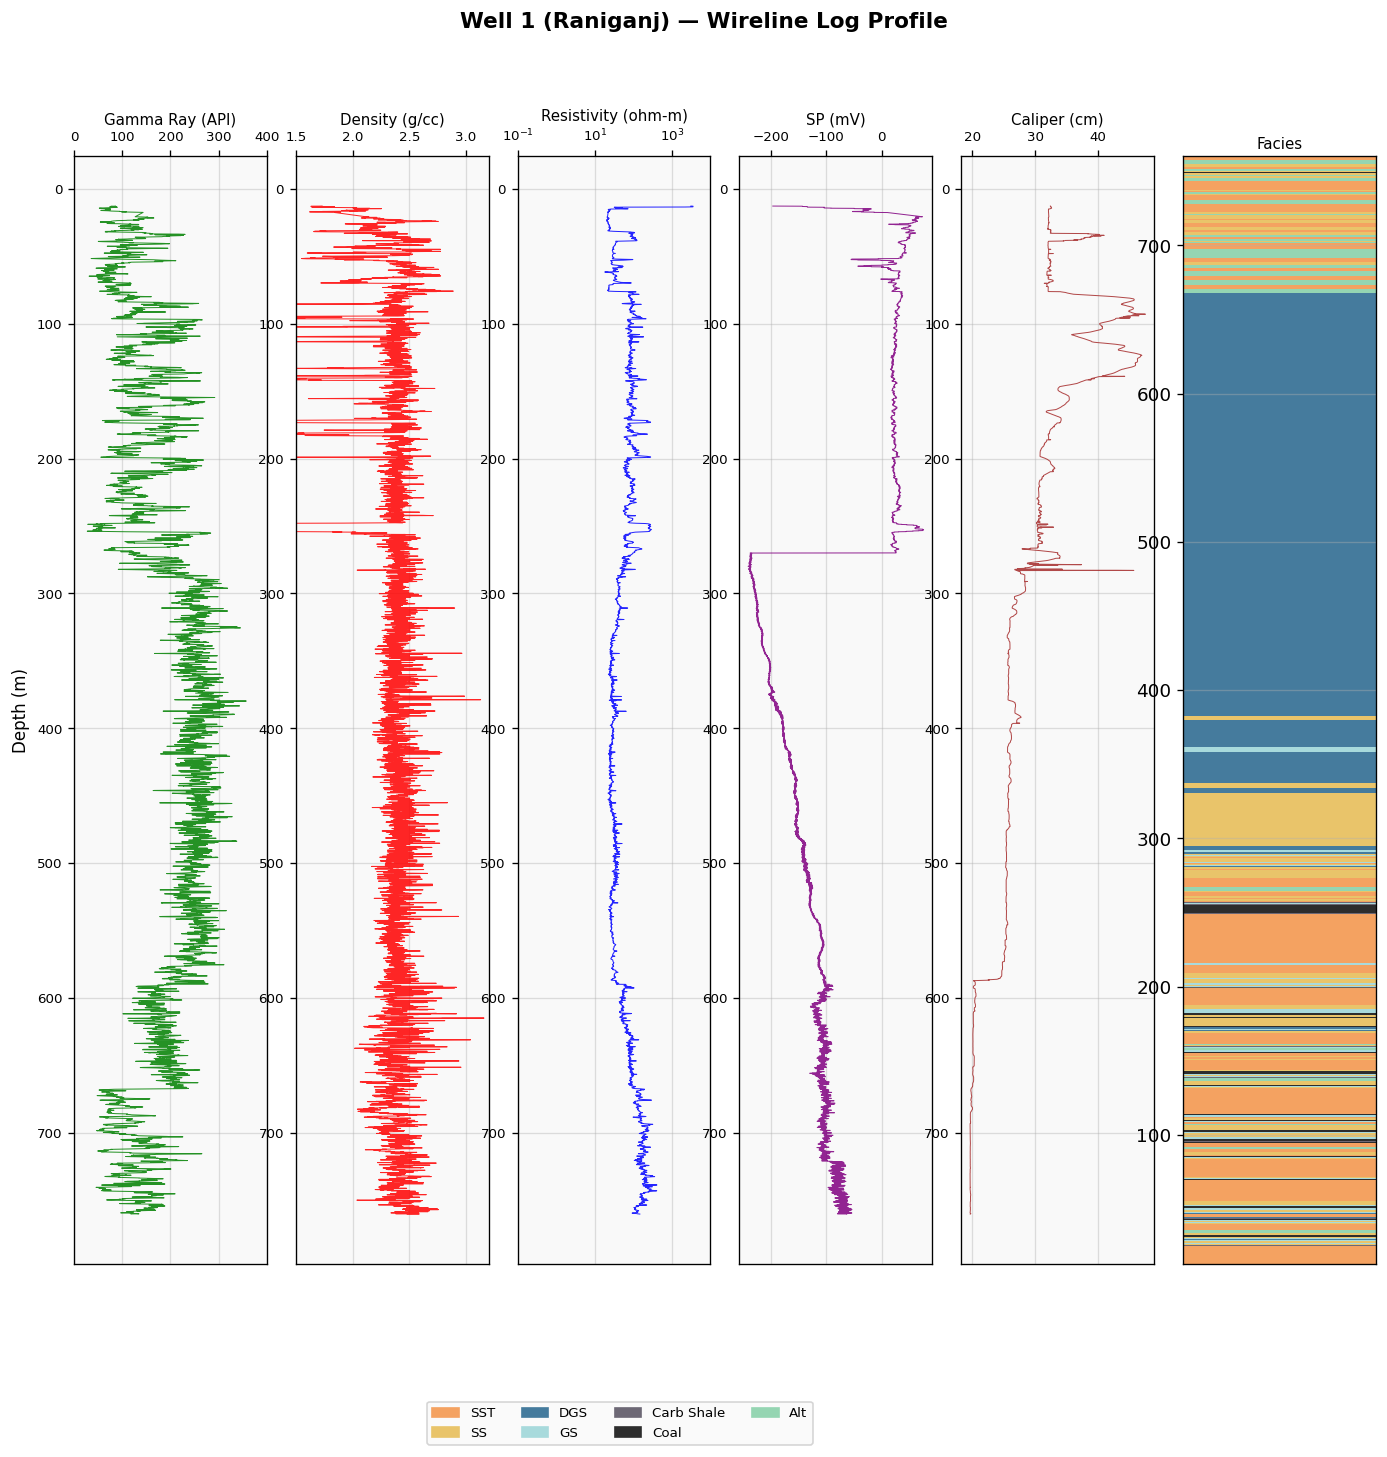

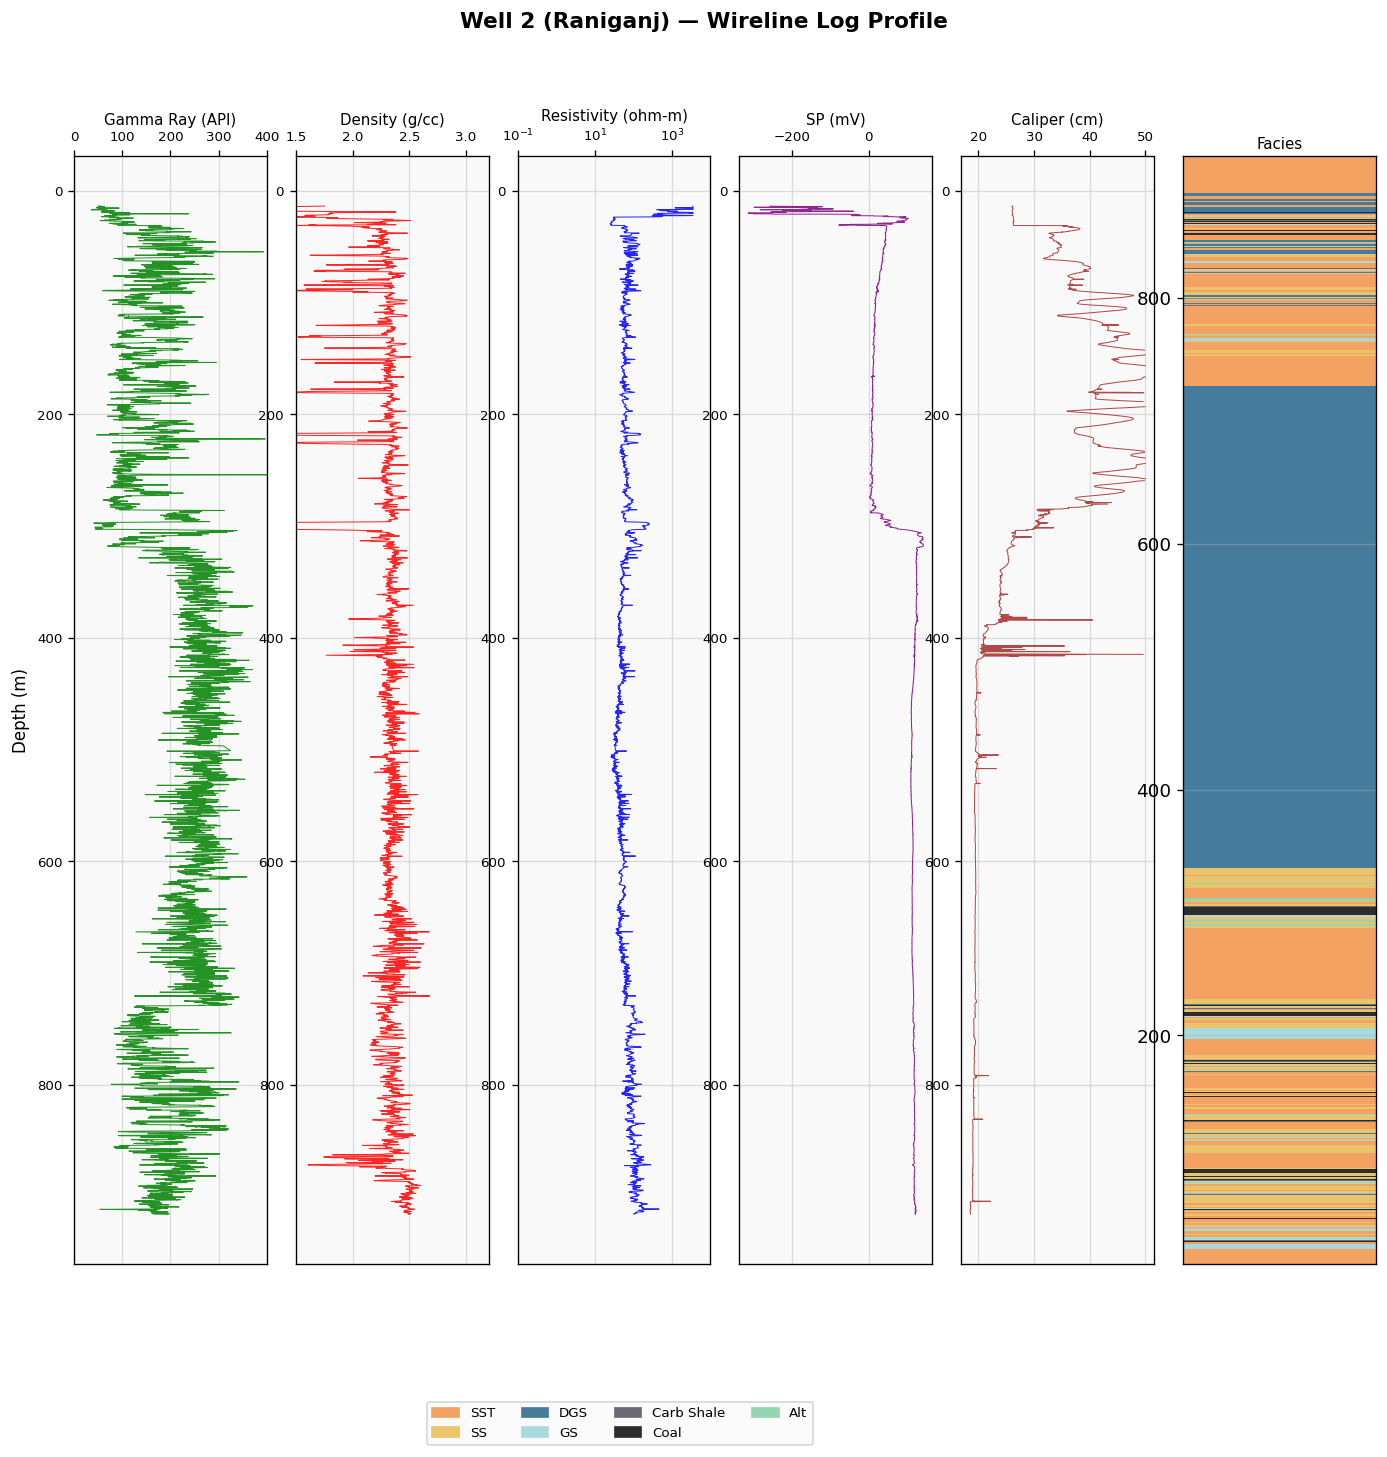

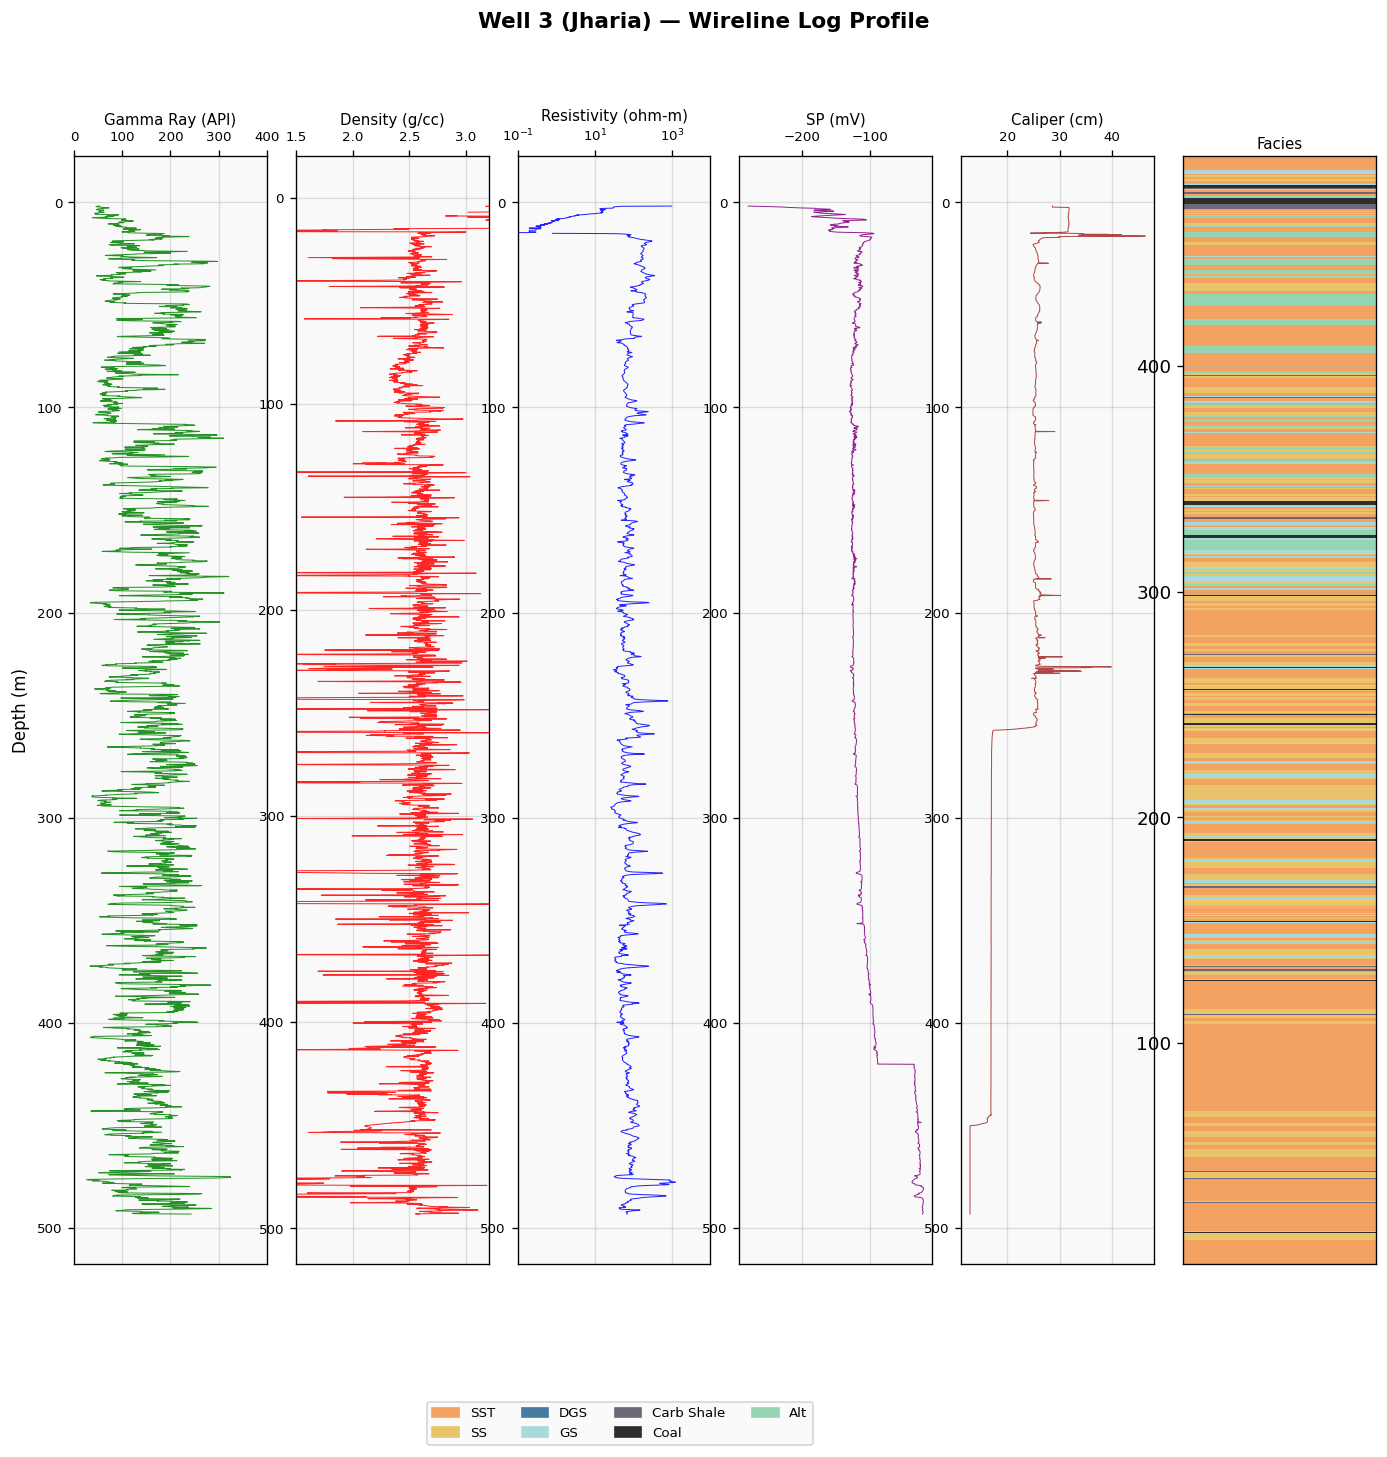

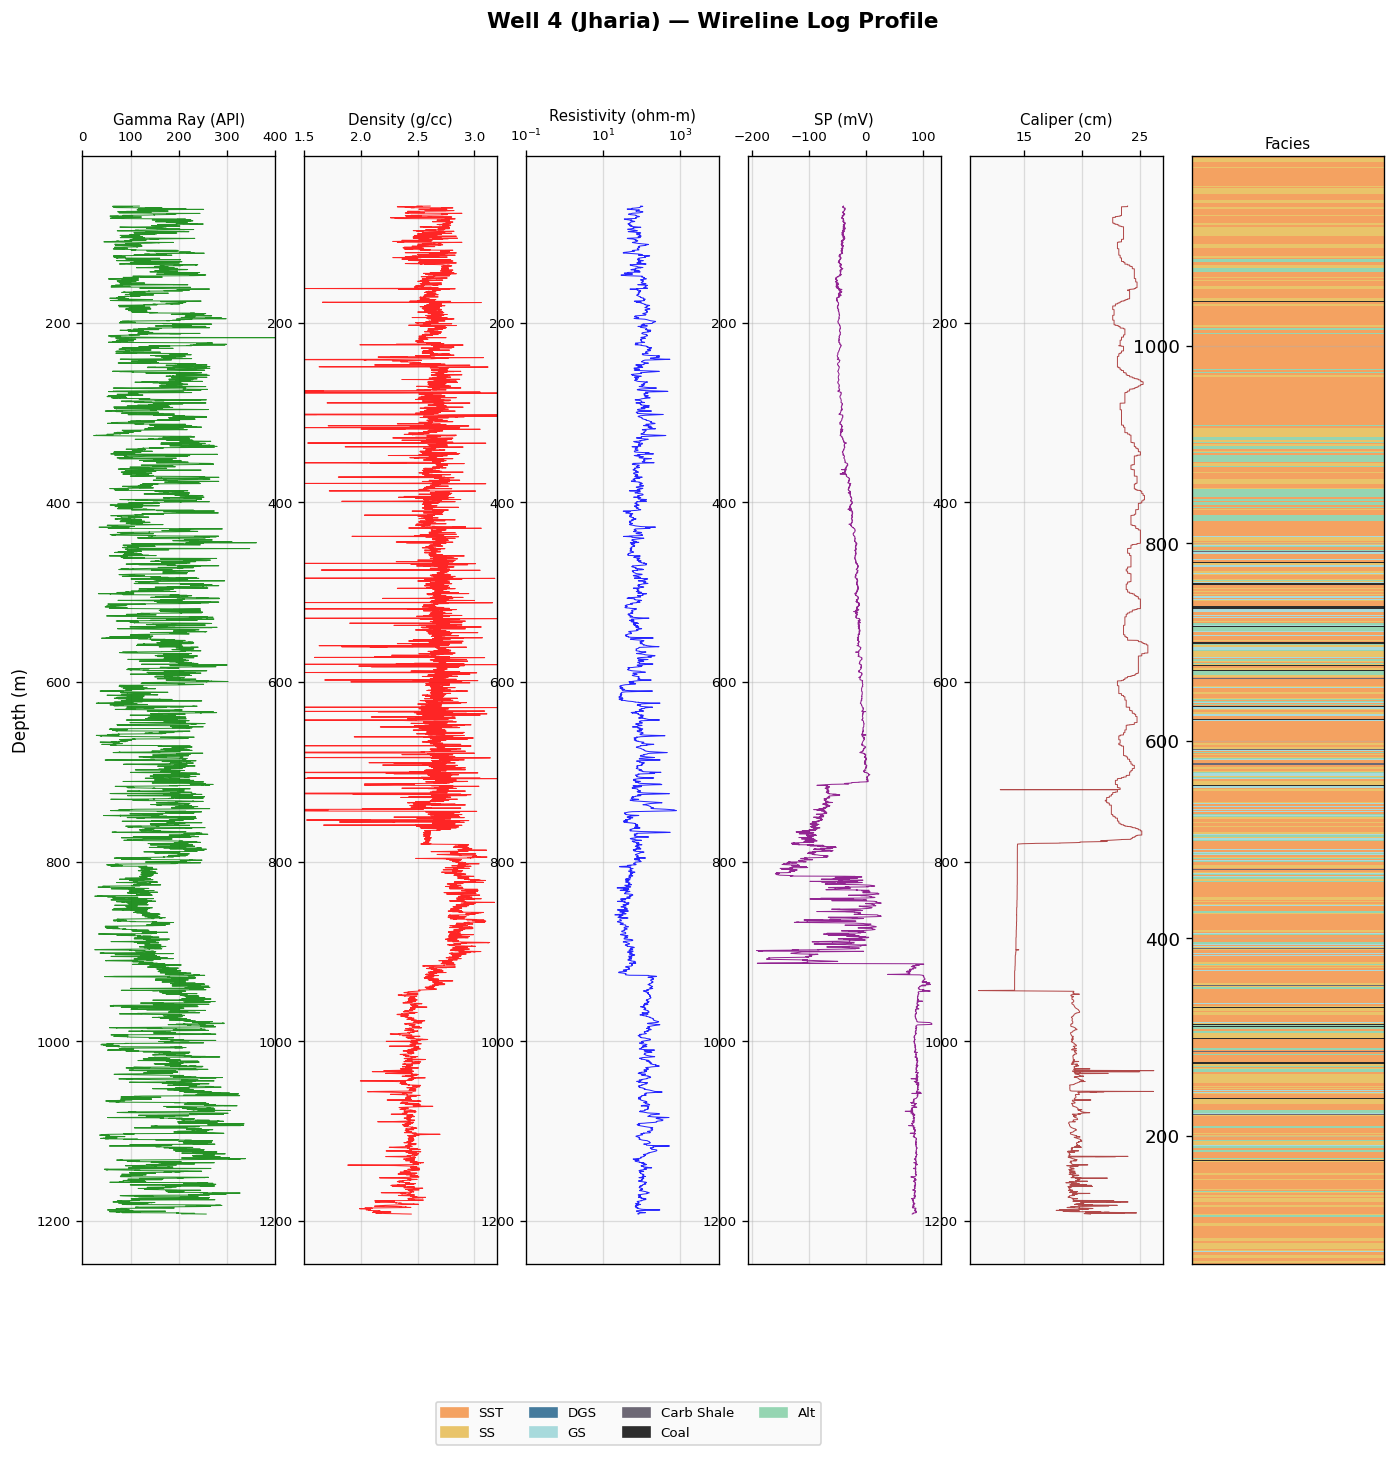

In [17]:
def plot_log_profile(well_number, depth_min=None, depth_max=None):
    """
    Plot a multi-track wireline log profile for one well.
    Tracks: GR | Density | Resistivity | SP | Caliper | Facies colour strip
    """
    sub = df[df['WELL'] == well_number].copy()
    if depth_min: sub = sub[sub['DEPT[M]'] >= depth_min]
    if depth_max: sub = sub[sub['DEPT[M]'] <= depth_max]
    sub   = sub.iloc[::5].reset_index(drop=True)    # every 5th row = 0.1 m
    depth = sub['DEPT[M]'].values
    basin = 'Raniganj' if well_number <= 2 else 'Jharia'

    tracks = [
        ('GAM[API]',    'Gamma Ray (API)',     'green',  (0,400),  False),
        ('DEN[G/CC]',   'Density (g/cc)',      'red',    (1.5,3.2),False),
        ('RES[OHM]',    'Resistivity (ohm-m)', 'blue',   (0.1,1e4),True),
        ('SP[MV]',      'SP (mV)',             'purple', None,     False),
        ('CALIPER[CM]', 'Caliper (cm)',        'brown',  None,     False),
    ]

    fig = plt.figure(figsize=(14, 12))
    gs  = gridspec.GridSpec(1, 6, wspace=0.15)
    axes = [fig.add_subplot(gs[0, i]) for i in range(5)]
    ax_col = fig.add_subplot(gs[0, 5])

    for ax, (col, label, color, xlim, log_x) in zip(axes, tracks):
        if col in sub.columns and sub[col].notna().any():
            ax.plot(sub[col], depth, color=color, linewidth=0.6, alpha=0.85)
            if log_x:   ax.set_xscale('log')
            if xlim:    ax.set_xlim(xlim)
        ax.set_xlabel(label, fontsize=9)
        ax.invert_yaxis()
        ax.xaxis.set_label_position('top')
        ax.xaxis.tick_top()
        ax.tick_params(axis='both', labelsize=8)

    axes[0].set_ylabel('Depth (m)', fontsize=10)

    # Facies colour strip
    for i in range(len(sub) - 1):
        ax_col.fill_betweenx([depth[i], depth[i+1]], 0, 1,
                              color=FACIES_COLORS.get(sub['Facies'].iloc[i], '#cccccc'),
                              linewidth=0)
    ax_col.set_xlim(0, 1)
    ax_col.set_ylim(depth.max(), depth.min())
    ax_col.set_xticks([])
    ax_col.set_title('Facies', fontsize=9, pad=4)
    ax_col.invert_yaxis()

    # Show all original 7 classes in legend (including DGS before merge)
    patches = [mpatches.Patch(color=v, label=k) for k, v in FACIES_COLORS.items()
               if k in FACIES_ORDER_ORIG]
    fig.legend(handles=patches, loc='lower center', ncol=4,
               fontsize=8, bbox_to_anchor=(0.45, -0.02))

    fig.suptitle(f'Well {well_number} ({basin}) — Wireline Log Profile',
                 fontsize=13, fontweight='bold')
    plt.savefig(f'p1_05_log_profile_well{well_number}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


for w in [1, 2, 3, 4]:
    plot_log_profile(w)


## 1.6 — Missing Value Heatmap (After Phase 0 Cleaning)

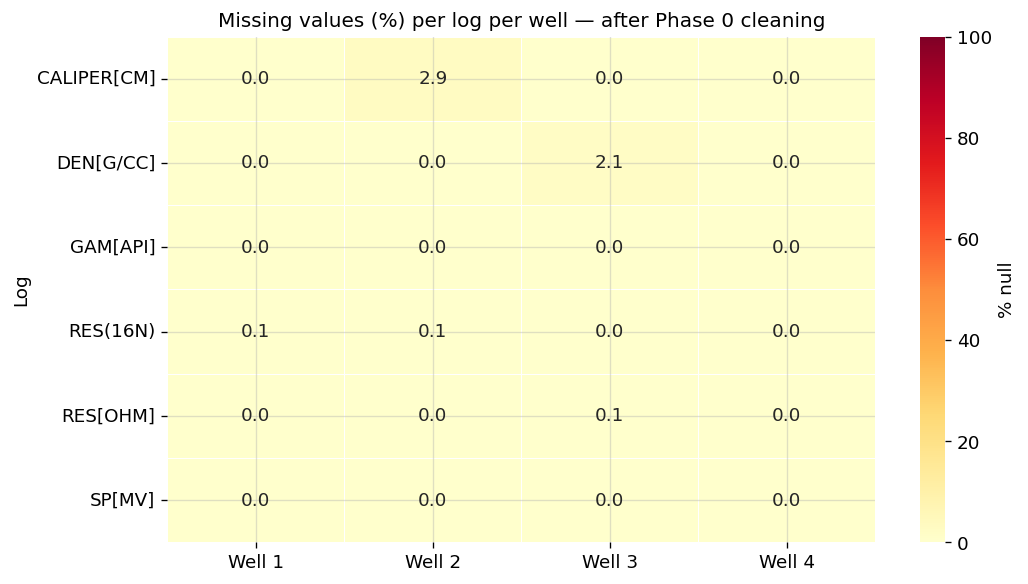

Logs with > 1% missing:
  Well 2 — CALIPER[CM]: 2.9%
  Well 3 — DEN[G/CC]: 2.1%


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

miss_data = []
for w in [1, 2, 3, 4]:
    for col in LOG_COLS:
        sub = df[df['WELL']==w]
        pct = 100 * sub[col].isna().mean() if col in sub.columns else 100
        miss_data.append({'Well': f'Well {w}', 'Log': col, 'Missing %': round(pct, 1)})

miss_pivot = pd.DataFrame(miss_data).pivot(index='Log', columns='Well', values='Missing %')
sns.heatmap(miss_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% null'},
            vmin=0, vmax=100)
ax.set_title('Missing values (%) per log per well — after Phase 0 cleaning')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('p1_06_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Logs with > 1% missing:")
for _, row in pd.DataFrame(miss_data).iterrows():
    if row['Missing %'] > 1:
        print(f"  {row['Well']} — {row['Log']}: {row['Missing %']}%")


---
# Phase 2 — Feature Engineering

**Goal :** Transform raw log curves into a clean, complete feature matrix ready for ML.

### Steps in this phase

```
2.1  Select base features
2.2  Create physics-guided derived features
2.3  Visualise derived features per facies
2.4  Handle remaining null values
2.5  Label encode the target variable
2.6  Build final feature matrix & save
2.7  Feature importance preview (quick Random Forest)
```

### Why derived features?
A single GR reading of 200 API could be DGS or SS.  
But `GR / Density` = 200/2.3 vs 200/2.6 tells a very different story.  
Ratios amplify the physical contrasts that separate facies.


## 2.1 — Select Base Features

In [19]:
# LOG_FEATURES already defined in Phase 0 constants:
# ['CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']

print("Base features selected (present in ALL 4 wells, same units):")
print(f"  {LOG_FEATURES}")
print()
print(f"  {'Feature':<15} {'Non-null %':>12} {'Min':>10} {'Max':>10} {'Mean':>10}")
print(f"  {'-'*14} {'-'*12} {'-'*10} {'-'*10} {'-'*10}")
for col in LOG_FEATURES:
    pct  = 100 * df[col].notna().mean()
    vals = df[col].dropna()
    print(f"  {col:<15} {pct:>11.1f}% {vals.min():>10.3f} {vals.max():>10.3f} {vals.mean():>10.3f}")

# Work on a copy so df (Phase 1) remains unchanged
df2 = df.copy()


Base features selected (present in ALL 4 wells, same units):
  ['CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']

  Feature           Non-null %        Min        Max       Mean
  -------------- ------------ ---------- ---------- ----------
  CALIPER[CM]            99.2%     11.022     49.990     24.141
  DEN[G/CC]              99.7%      0.825      3.500      2.457
  GAM[API]              100.0%     20.400    575.062    178.856
  RES(16N)              100.0%      0.027   3496.400     64.510
  RES[OHM]              100.0%      0.050   3527.250     88.297
  SP[MV]                100.0%   -314.215    142.772    -14.257


## 2.1a — Merge DGS → GS (Label Change, Rows Preserved)

### What this step does

**It changes the label, NOT the data.** All 37,600 DGS rows remain in the dataset.
Their log values (GR, density, resistivity, SP, caliper) are unchanged.
Only the class name changes from `DGS` to `GS`.

```
BEFORE:  DGS  →  37,600 rows   GS →  8,370 rows   (two separate classes)
AFTER :           GS  →  45,970 rows                (one combined class)
Total rows: 162,829 → 162,829   ← no rows dropped
```

### Why not drop DGS rows?

Dropping would waste 37,600 rows — 23% of the entire dataset. Those rows contain
real geological information (high-GR dark grey shale log signatures) that help the
model learn the shale end of the GR spectrum. Keeping them makes the model more robust.

### Why relabel DGS as GS?

For a generalised prediction model — given any log readings, predict the facies —
every class must be predictable on unseen wells. DGS only exists in the Raniganj
basin (Barren Measures formation). Jharia wells have zero DGS samples.

If we keep DGS separate:
- Model trains on DGS (45% of train rows)
- Model predicts DGS at Jharia depths
- Every DGS prediction is wrong (no true DGS in Jharia)
- DGS F1 = 0 by definition — meaningless evaluation

DGS and GS are both grey shales (same rock type, same depositional environment).
Merging is geologically justified. The combined GS class covers the full grey
shale spectrum from medium-GR to high-GR varieties.


In [20]:
# ── Merge DGS → GS  (ROWS KEPT, LABEL CHANGED) ───────────────────────
#
# What this does:
#   BEFORE: DGS label on 37,600 rows  +  GS label on 8,370 rows  = 45,970 shale rows
#   AFTER : GS  label on 45,970 rows                              = 45,970 shale rows
#
# The 37,600 DGS rows are NOT dropped. Their log values (GR, density,
# resistivity, SP, caliper) are fully preserved. Only the class LABEL
# changes from 'DGS' to 'GS'. Total row count stays the same.
#
# Why relabel (not drop)?
#   Dropping wastes 37,600 rows — 23% of the entire dataset.
#   Relabelling keeps all the geological information while giving those
#   rows a class that appears in BOTH train and test wells.

print("Class distribution BEFORE merge:")
print(f"  {'Facies':<12}  {'Rows':>8}  {'%':>6}")
print(f"  {'-'*30}")
for f in FACIES_ORDER_ORIG:
    n   = (df2['Facies']==f).sum()
    pct = 100*n/len(df2)
    print(f"  {f:<12}  {n:>8,}  {pct:>5.1f}%")
print(f"  {'TOTAL':<12}  {len(df2):>8,}")

# ── Apply the label change ─────────────────────────────────────────────
df2['Facies'] = df2['Facies'].replace({'DGS': 'GS'})

print("\nClass distribution AFTER DGS → GS relabel:")
print(f"  {'Facies':<12}  {'Rows':>8}  {'%':>6}  Note")
print(f"  {'-'*50}")
for f in FACIES_ORDER:
    n   = (df2['Facies']==f).sum()
    pct = 100*n/len(df2)
    note = '← was 8,370 GS + 37,600 DGS (both kept)' if f=='GS' else ''
    print(f"  {f:<12}  {n:>8,}  {pct:>5.1f}%  {note}")
print(f"  {'TOTAL':<12}  {len(df2):>8,}  ← same as before, no rows dropped")

# ── Sanity check ────────────────────────────────────────────────────────
assert len(df2) == 162829, "Row count changed — something is wrong!"
assert (df2['Facies']=='DGS').sum() == 0, "DGS label still present"
assert (df2['Facies']=='GS').sum()  == 45970, "GS count incorrect"
print("\n✓ All assertions passed — 162,829 rows preserved, DGS label → GS")

# ── Cross-well check ────────────────────────────────────────────────────
print("\nCross-well class presence (all must be ✓ in both train and test):")
for f in FACIES_ORDER:
    nt = ((df2['WELL'].isin([1,2])) & (df2['Facies']==f)).sum()
    nv = ((df2['WELL'].isin([3,4])) & (df2['Facies']==f)).sum()
    status = '✓' if nt>0 and nv>0 else '✗ MISSING'
    print(f"  {f:<12}: train={nt:>6,}  test={nv:>6,}  {status}")


Class distribution BEFORE merge:
  Facies            Rows       %
  ------------------------------
  SST             70,976   43.6%
  SS              29,741   18.3%
  DGS             37,600   23.1%
  GS               8,370    5.1%
  Carb Shale       1,317    0.8%
  Coal             4,264    2.6%
  Alt             10,561    6.5%
  TOTAL          162,829

Class distribution AFTER DGS → GS relabel:
  Facies            Rows       %  Note
  --------------------------------------------------
  SST             70,976   43.6%  
  SS              29,741   18.3%  
  GS              45,970   28.2%  ← was 8,370 GS + 37,600 DGS (both kept)
  Carb Shale       1,317    0.8%  
  Coal             4,264    2.6%  
  Alt             10,561    6.5%  
  TOTAL          162,829  ← same as before, no rows dropped

✓ All assertions passed — 162,829 rows preserved, DGS label → GS

Cross-well class presence (all must be ✓ in both train and test):
  SST         : train=24,381  test=46,595  ✓
  SS          : train=

## 2.2 — Derived Features (Physics-Guided)

Each derived feature is motivated by petrophysical reasoning —  
not arbitrary combinations.


In [21]:
# ── Feature 1 : GR / Density ratio ───────────────────────────────────
# High GR + low density → organic shale (Carb Shale, DGS)
# Low GR  + higher density → clean sandstone
# Amplifies the contrast between sand and shale.
df2['GR_DEN_ratio'] = df2['GAM[API]'] / (df2['DEN[G/CC]'] + 1e-6)

# ── Feature 2 : Log10 Resistivity (deep) ─────────────────────────────
# Resistivity spans orders of magnitude (0.1 → 10,000 ohm-m).
# Log transform compresses the range → better for distance-based models.
df2['log_RES'] = np.log10(df2['RES[OHM]'].clip(lower=0.01))

# ── Feature 3 : Log10 Resistivity (shallow) ──────────────────────────
df2['log_RES16'] = np.log10(df2['RES(16N)'].clip(lower=0.01))

# ── Feature 4 : Resistivity ratio (deep / shallow) ───────────────────
# deep RES > shallow RES → hydrocarbon deeper in the formation
# deep RES < shallow RES → invaded zone (mud filtrate), typical shale
df2['RES_ratio'] = (df2['RES[OHM]'] / (df2['RES(16N)'] + 1e-6)).clip(0.01, 100)

# ── Feature 5 : Density × Log10(Resistivity) product ────────────────
# Coal      : very low density, high resistivity → very distinctive value
# DGS       : high density, low resistivity      → different distinctive value
# SST       : moderate density, high resistivity → moderate value
df2['DEN_RES_product'] = df2['DEN[G/CC]'] * np.log10(df2['RES[OHM]'].clip(0.01))

# ── Feature 6 : GR × Density product ─────────────────────────────────
# Amplifies shale (high GR × high density) vs sand (low GR × lower density)
df2['GR_DEN_product'] = df2['GAM[API]'] * df2['DEN[G/CC]']

# ── Feature 7 : Caliper anomaly (deviation from bit size) ────────────
# Shale zones have washed-out boreholes (enlarged caliper = positive anomaly).
# Reference bit size ~21.6 cm (8.5 inch standard drill bit × 2.54)
BIT_SIZE_CM = 21.6
df2['CALP_anomaly'] = df2['CALIPER[CM]'] - BIT_SIZE_CM

# ── Feature list ─────────────────────────────────────────────────────
ALL_FEATURES = LOG_FEATURES + [
    'GR_DEN_ratio', 'log_RES', 'log_RES16',
    'RES_ratio', 'DEN_RES_product', 'GR_DEN_product', 'CALP_anomaly'
]

print(f"Total features : {len(ALL_FEATURES)}")
print(f"  Base          : {len(LOG_FEATURES)} — {LOG_FEATURES}")
print(f"  Derived       : {len(ALL_FEATURES)-len(LOG_FEATURES)}")
print()
display(df2[ALL_FEATURES].describe().round(3))


Total features : 13
  Base          : 6 — ['CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]']
  Derived       : 7



,CALIPER[CM],DEN[G/CC],GAM[API],RES(16N),RES[OHM],SP[MV],GR_DEN_ratio,log_RES,log_RES16,RES_ratio,DEN_RES_product,GR_DEN_product,CALP_anomaly
count,161548.000,162323.000,162829.000,162754.000,162816.000,162829.000,162323.000,162816.000,162754.000,162741.000,162312.000,162323.000,161548.000
mean,24.141,2.457,178.856,64.510,88.297,-14.257,73.853,1.844,1.636,2.158,4.532,438.811,2.541
std,7.159,0.251,67.605,103.899,143.171,95.840,29.325,0.274,0.411,3.614,0.727,163.524,7.159
min,11.022,0.825,20.400,0.027,0.050,-314.215,7.405,-1.299,-1.562,0.010,-1.654,34.748,-10.578
25%,19.413,2.338,122.168,21.343,48.421,-102.933,49.378,1.685,1.329,1.039,4.014,302.205,-2.187
50%,23.586,2.443,182.055,56.100,69.200,-12.800,73.046,1.840,1.749,1.448,4.558,454.873,1.986
75%,25.693,2.620,233.000,84.700,98.600,85.600,96.785,1.994,1.928,2.495,5.038,572.241,4.093
max,49.990,3.500,575.062,3496.400,3527.250,142.772,246.001,3.547,3.544,100.000,7.498,1344.288,28.390


## 2.3 — Visualise Derived Features per Facies

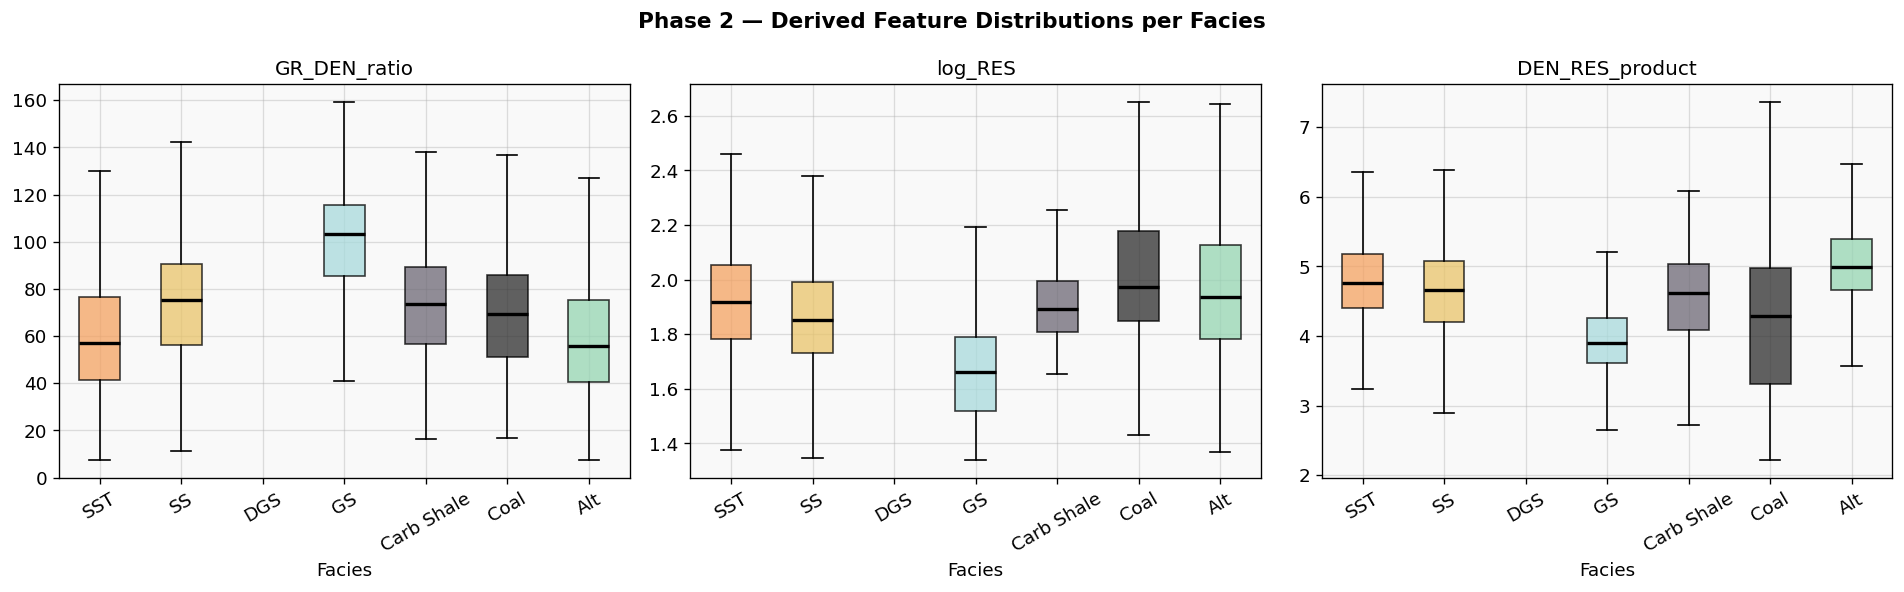

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
derived_to_plot = ['GR_DEN_ratio', 'log_RES', 'DEN_RES_product']

for ax, col in zip(axes, derived_to_plot):
    data = [df2.loc[df2['Facies']==f, col].dropna().values for f in FACIES_ORDER_ORIG]
    bp   = ax.boxplot(data, labels=FACIES_ORDER_ORIG, patch_artist=True,
                      showfliers=False,
                      medianprops=dict(color='black', linewidth=2))
    for patch, facies in zip(bp['boxes'], FACIES_ORDER_ORIG):
        patch.set_facecolor(FACIES_COLORS.get(facies, '#cccccc'))
        patch.set_alpha(0.75)
    ax.set_title(col)
    ax.set_xlabel('Facies')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Phase 2 — Derived Feature Distributions per Facies',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_01_derived_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.4 — Handle Remaining Null Values

After Phase 0 preprocessing, a small number of nulls remain (< 3% in any column).

**Two strategies based on null pattern:**

| Strategy | When to use | Reason |
|----------|------------|--------|
| **Drop rows** | `GAM[API]` bottom-tail nulls | Tool pulled out — no geological signal, not imputable |
| **Per-well median imputation** | All other nulls | Tool malfunction gaps. Use *per-well* median (not global) because each well has its own log baseline |

Per-well vs global median: `RES[OHM]` in Raniganj coal zone runs ~100–3500 ohm-m;  
in Jharia sandstone zone ~20–800 ohm-m. Filling a Well 3 null with the global median  
(skewed by Wells 1 & 2) would inject a geologically wrong value.


In [23]:
print("Nulls BEFORE handling:")
print(df2[ALL_FEATURES].isnull().sum()[df2[ALL_FEATURES].isnull().sum() > 0].to_string())

# ── Strategy A : Drop rows where GAM is null ──────────────────────────
# GAM nulls are at the very bottom of Wells 2 & 3 — tool being pulled
# out, no signal. Cannot be imputed. Only 34 rows out of 166,000.
before = len(df2)
df2    = df2.dropna(subset=['GAM[API]'])
dropped = before - len(df2)
print(f"\nDropped {dropped} bottom-tail rows with null GAM[API]")

# ── Strategy B : Per-well median imputation ───────────────────────────
# For all remaining nulls — fills each well's nulls with that well's
# own median so we don't mix baselines across wells.
print("\nPer-well median imputation:")
for well in sorted(df2['WELL'].unique()):
    mask = df2['WELL'] == well
    for col in ALL_FEATURES:
        n_null = df2.loc[mask, col].isna().sum()
        if n_null > 0:
            median_val = df2.loc[mask, col].median()
            df2.loc[mask, col] = df2.loc[mask, col].fillna(median_val)
            print(f"  Well {well} — {col:<20}: {n_null} nulls filled with median={median_val:.3f}")

print("\nNulls AFTER handling:")
remaining = df2[ALL_FEATURES].isnull().sum().sum()
if remaining == 0:
    print("  ✓ Zero nulls in all feature columns")
else:
    print(df2[ALL_FEATURES].isnull().sum()[df2[ALL_FEATURES].isnull().sum() > 0])


Nulls BEFORE handling:
CALIPER[CM]        1281
DEN[G/CC]           506
RES(16N)             75
RES[OHM]             13
GR_DEN_ratio        506
log_RES              13
log_RES16            75
RES_ratio            88
DEN_RES_product     517
GR_DEN_product      506
CALP_anomaly       1281

Dropped 0 bottom-tail rows with null GAM[API]

Per-well median imputation:
  Well 1 — RES(16N)            : 45 nulls filled with median=20.521
  Well 1 — log_RES16           : 45 nulls filled with median=1.312
  Well 1 — RES_ratio           : 45 nulls filled with median=2.408
  Well 2 — CALIPER[CM]         : 1281 nulls filled with median=19.619
  Well 2 — RES(16N)            : 30 nulls filled with median=23.193
  Well 2 — log_RES16           : 30 nulls filled with median=1.365
  Well 2 — RES_ratio           : 30 nulls filled with median=2.583
  Well 2 — CALP_anomaly        : 1281 nulls filled with median=-1.981
  Well 3 — DEN[G/CC]           : 506 nulls filled with median=2.590
  Well 3 — RES[OHM]      

## 2.5 — Label Encode the Target Variable

In [24]:
# (already imported in setup cell) from sklearn.preprocessing import LabelEncoder

# Encode facies string labels → integer codes for ML models
le = LabelEncoder()
le.fit(FACIES_ORDER)   # 6 classes: SST, SS, GS, Carb Shale, Coal, Alt
                        # DGS removed — merged into GS in Section 2.1a
df2['Facies_code'] = le.transform(df2['Facies'])

print("Facies label encoding (save this mapping!):")
for code, name in enumerate(le.classes_):
    count = (df2['Facies_code'] == code).sum()
    print(f"  {code} → {name:<12} ({count:,} samples)")

print(f"\nle.classes_ = {list(le.classes_)}")
print("\n⚠ Always use this same LabelEncoder when decoding predictions in Phase 3+")


Facies label encoding (save this mapping!):
  0 → Alt          (10,561 samples)
  1 → Carb Shale   (1,317 samples)
  2 → Coal         (4,264 samples)
  3 → GS           (45,970 samples)
  4 → SS           (29,741 samples)
  5 → SST          (70,976 samples)

le.classes_ = [np.str_('Alt'), np.str_('Carb Shale'), np.str_('Coal'), np.str_('GS'), np.str_('SS'), np.str_('SST')]

⚠ Always use this same LabelEncoder when decoding predictions in Phase 3+


## 2.6 — Final Feature Matrix & Save

In [25]:
# ── Build final feature matrix ────────────────────────────────────────
META_COLS  = ['DEPT[M]', 'WELL', 'BASIN', 'Formation',
              'LITHOLOGY DESCRIPTION', 'Facies', 'Facies_code']
FINAL_FEAT = META_COLS + ALL_FEATURES

df_final = df2[FINAL_FEAT].reset_index(drop=True)

print(f"Final feature matrix:")
print(f"  Shape    : {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"  Features : {ALL_FEATURES}")
print(f"  Nulls    : {df_final[ALL_FEATURES].isnull().sum().sum()} (must be 0)")
print()

# ── Save ──────────────────────────────────────────────────────────────
df_final.to_csv(OUTPUT_FEATURES, index=False)
print(f"✓ Saved: {OUTPUT_FEATURES}")

# ── Per-well feature means (sanity check) ─────────────────────────────
print("\nPer-well feature means (sanity check for scaling later):")
display(df_final.groupby('WELL')[ALL_FEATURES].mean().round(2))


Final feature matrix:
  Shape    : 162,829 rows × 20 columns
  Features : ['CALIPER[CM]', 'DEN[G/CC]', 'GAM[API]', 'RES(16N)', 'RES[OHM]', 'SP[MV]', 'GR_DEN_ratio', 'log_RES', 'log_RES16', 'RES_ratio', 'DEN_RES_product', 'GR_DEN_product', 'CALP_anomaly']
  Nulls    : 0 (must be 0)

✓ Saved: ./wells_features.csv

Per-well feature means (sanity check for scaling later):


,CALIPER[CM],DEN[G/CC],GAM[API],RES(16N),RES[OHM],SP[MV],GR_DEN_ratio,log_RES,log_RES16,RES_ratio,DEN_RES_product,GR_DEN_product,CALP_anomaly
WELL,,,,,,,,,,,,,
1,27.71,2.37,188.64,37.89,75.03,-86.52,79.63,1.75,1.33,3.71,4.13,449.25,6.11
2,25.92,2.31,207.06,47.17,87.36,83.78,89.58,1.81,1.42,2.81,4.16,480.66,4.32
3,21.25,2.53,156.83,99.01,85.82,-105.02,63.46,1.83,1.96,0.80,4.70,402.07,-0.35
4,21.51,2.61,159.44,80.89,98.93,-5.02,61.90,1.94,1.87,1.20,5.02,414.25,-0.09


## 2.7 — Feature Importance Preview (Quick Random Forest)

A fast 100-tree Random Forest on a **balanced subsample** (500 rows per class)  
gives an early indicator of which features carry the most discriminative power.  
This is NOT the final model — just a preview to guide feature selection discussion.


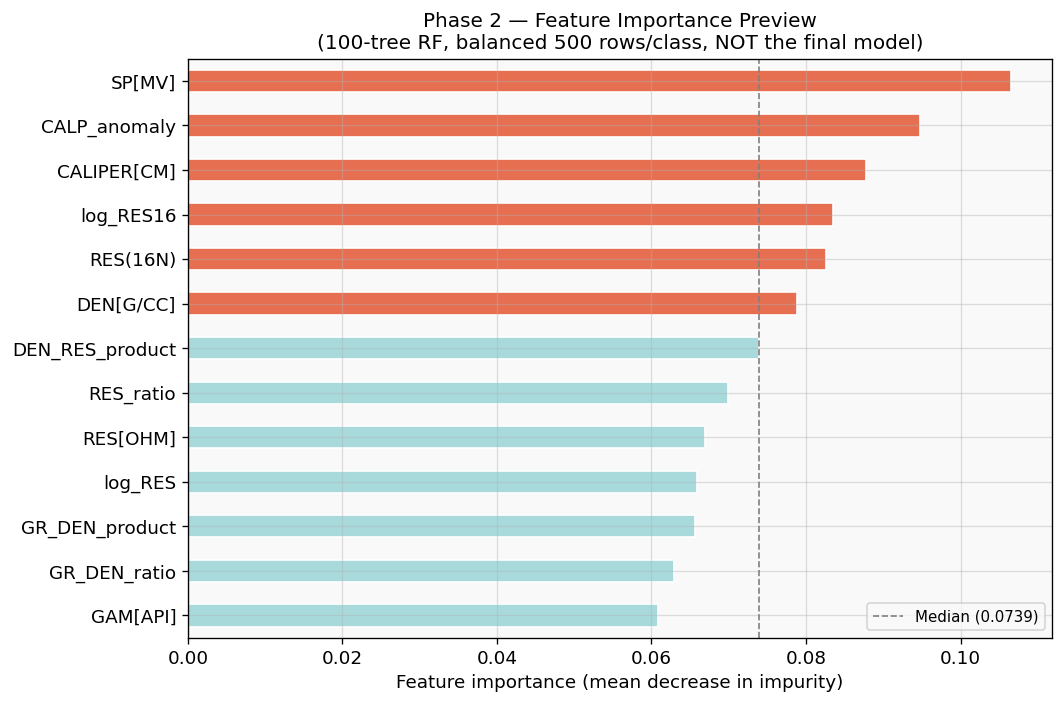

Top 5 most important features (preview):
  SP[MV]                : 0.1066
  CALP_anomaly          : 0.0948
  CALIPER[CM]           : 0.0878
  log_RES16             : 0.0836
  RES(16N)              : 0.0826

→ These features will be prioritised in Phase 3 model training


In [26]:
# (already imported in setup cell) from sklearn.ensemble import RandomForestClassifier

# ── Balanced subsample: 500 rows per class ────────────────────────────
samples = []
for facies in FACIES_ORDER:
    sub = df_final[df_final['Facies'] == facies]
    samples.append(sub.sample(min(500, len(sub)), random_state=RANDOM_STATE))
df_sample = pd.concat(samples, ignore_index=True)

X_sample = df_sample[ALL_FEATURES].values
y_sample = df_sample['Facies_code'].values

# Quick RF (not tuned — preview only)
rf_quick = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE,
    n_jobs=-1, class_weight='balanced'
)
rf_quick.fit(X_sample, y_sample)

# ── Plot feature importances ───────────────────────────────────────────
importances = pd.Series(rf_quick.feature_importances_, index=ALL_FEATURES)
importances = importances.sort_values(ascending=True)
median_imp  = importances.median()

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#E76F51' if v > median_imp else '#A8DADC' for v in importances.values]
importances.plot.barh(ax=ax, color=colors_bar, edgecolor='white')
ax.axvline(median_imp, color='gray', linestyle='--', linewidth=1,
           label=f'Median ({median_imp:.4f})')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Phase 2 — Feature Importance Preview\n'
             '(100-tree RF, balanced 500 rows/class, NOT the final model)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('p2_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features (preview):")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}: {imp:.4f}")
print("\n→ These features will be prioritised in Phase 3 model training")


---
## Phase 0 → 2 Complete

**Files produced:**

| File | Description |
|------|-------------|
| `wells_merged_classified.csv` | Merged log + lithology, 7-class Facies label |
| `wells_features.csv` | 13-feature matrix, label-encoded, 0 nulls — ML-ready |

---


In [27]:
# ── All imports are in the Environment Setup cell at the top ──────────
# StandardScaler, LabelEncoder, RandomForestClassifier, XGBoost,
# TensorFlow/Keras, joblib — all imported there.
# This cell intentionally left as a checkpoint only.

print("✓ All imports already loaded from the Environment Setup cell")
print(f"  StandardScaler  : {StandardScaler.__module__}")
print(f"  XGBoost version : {xgb.__version__}")
print(f"  TensorFlow      : {tf.__version__}")


✓ All imports already loaded from the Environment Setup cell
  StandardScaler  : sklearn.preprocessing._data
  XGBoost version : 3.2.0
  TensorFlow      : 2.20.0


In [28]:
# ── Load the feature matrix saved at the end of Phase 2 ───────────────
# Phase 2 saved wells_features.csv. Reload here so Phases 3–6 can run
# independently. Apply DGS→GS relabel (same logic as Section 2.1a).
#
# NOTE: relabel only changes the label string. All 37,600 DGS rows
# are kept — their log values are unchanged. Total rows: 162,829.

df = pd.read_csv(OUTPUT_FEATURES)

# Relabel DGS → GS (rows KEPT, label CHANGED)
df['Facies'] = df['Facies'].replace({'DGS': 'GS'})
df['Facies_code'] = le.transform(df['Facies'])

print(f"✓ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Null check: {df[ALL_FEATURES].isnull().sum().sum()} nulls in features")
print(f"  DGS rows remaining: {(df['Facies']=='DGS').sum()} (should be 0 — relabelled to GS)")
print()
print("Final 6-class distribution:")
for f in FACIES_ORDER:
    n   = (df['Facies']==f).sum()
    pct = 100*n/len(df)
    bar = '█' * int(pct/1.5)
    note = ' (incl. former DGS)' if f=='GS' else ''
    print(f"  {f:<12}: {n:>7,} ({pct:4.1f}%)  {bar}{note}")

print()
print("Cross-well class presence:")
for f in FACIES_ORDER:
    nt = ((df['WELL'].isin([1,2])) & (df['Facies']==f)).sum()
    nv = ((df['WELL'].isin([3,4])) & (df['Facies']==f)).sum()
    print(f"  {f:<12}: train={nt:>6,}  test={nv:>6,}  {'✓' if nt>0 and nv>0 else '✗'}")


✓ Loaded: 162,829 rows × 20 columns
  Null check: 0 nulls in features
  DGS rows remaining: 0 (should be 0 — relabelled to GS)

Final 6-class distribution:
  SST         :  70,976 (43.6%)  █████████████████████████████
  SS          :  29,741 (18.3%)  ████████████
  GS          :  45,970 (28.2%)  ██████████████████ (incl. former DGS)
  Carb Shale  :   1,317 ( 0.8%)  
  Coal        :   4,264 ( 2.6%)  █
  Alt         :  10,561 ( 6.5%)  ████

Cross-well class presence:
  SST         : train=24,381  test=46,595  ✓
  SS          : train=11,580  test=18,161  ✓
  GS          : train=40,585  test= 5,385  ✓
  Carb Shale  : train=   517  test=   800  ✓
  Coal        : train= 2,548  test= 1,716  ✓
  Alt         : train= 2,539  test= 8,022  ✓


---
# Phase 3 — Leave-One-Well-Out (LOWO) Cross-Validation

### Why LOWO instead of Raniganj → Jharia split?

The previous Raniganj→Jharia split gave poor results (~42% F1) because:

| Problem | Impact |
|---------|--------|
| GS = 49% of train but only 7% of test | Model never learned the test distribution |
| Density shift: 2.33 g/cc train vs 2.58 g/cc test | Features mean different things across basins |
| DGS (37,600 rows) merged into GS, only in train | 46% of GS training data has no test equivalent |

### LOWO: the geologically correct evaluation

In LOWO, we train on **3 wells** and test on **1 well** — rotating through all 4.  
This ensures:
- Every well sees data from 3 different geological contexts
- Each well is evaluated on the same geological log responses it was drilled in
- The evaluation is **fair** — no systematic basin mismatch

| Fold | Train wells | Test well | Test basin |
|------|-------------|-----------|-----------|
| 1 | Wells 2, 3, 4 | Well 1 | Raniganj |
| 2 | Wells 1, 3, 4 | Well 2 | Raniganj |
| 3 | Wells 1, 2, 4 | Well 3 | Jharia |
| 4 | Wells 1, 2, 3 | Well 4 | Jharia |

Results are **averaged across all 4 folds** for a robust estimate.


In [29]:
# ── CNN architecture (used inside LOWO loop for each fold) ────────────
def build_cnn(n_features, n_classes):
    inp = keras.Input(shape=(n_features, 1))
    x   = layers.Conv1D(64,  kernel_size=3, padding='same')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.MaxPooling1D(pool_size=2)(x)
    x   = layers.Conv1D(128, kernel_size=3, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.MaxPooling1D(pool_size=2)(x)
    x   = layers.Conv1D(64,  kernel_size=3, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs=inp, outputs=out)

n_classes = len(FACIES_ORDER)
print(f"✓ build_cnn defined  |  n_classes = {n_classes}")

✓ build_cnn defined  |  n_classes = 6


In [30]:
# ── Balanced resampling helper ─────────────────────────────────────────
# Cap majority classes, upsample minorities — same logic as before.
# Done separately for each fold's training set.

TARGET_COUNTS = {
    'SST'       : 8000,
    'SS'        : 5000,
    'GS'        : 5000,
    'Alt'       : 3000,
    'Coal'      : 2000,
    'Carb Shale': 1000,
}

def make_balanced_train(train_df, seed=RANDOM_STATE):
    """Resample train_df to TARGET_COUNTS per class."""
    parts = []
    for f in FACIES_ORDER:
        sub = train_df[train_df['Facies'] == f]
        if len(sub) == 0:
            continue
        n = TARGET_COUNTS[f]
        parts.append(sk_resample(sub, n_samples=n,
                                  replace=len(sub) < n,
                                  random_state=seed))
    return pd.concat(parts, ignore_index=True).sample(frac=1, random_state=seed)


# ── LOWO cross-validation: train all models across 4 folds ────────────
print("Running Leave-One-Well-Out Cross-Validation...")
print("="*60)

lowo_results  = {}   # {test_well: {model_name: {pred, y_te, tl, tn}}}
all_fold_scores = {name: [] for name in
                   ['Random Forest','XGBoost','SVM (Linear)',
                    'SVM (RBF)','KNN (k=5)','1D CNN']}

for fold, test_w in enumerate([1, 2, 3, 4], 1):
    train_ws  = [w for w in [1, 2, 3, 4] if w != test_w]
    basin_te  = 'Raniganj' if test_w <= 2 else 'Jharia'
    train_raw = df[df['WELL'].isin(train_ws)]
    test_df_w = df[df['WELL'] == test_w].copy()

    # Balanced training set for this fold
    train_bal = make_balanced_train(train_raw)

    X_tr_raw = train_bal[ALL_FEATURES].values
    y_tr_raw = le.transform(train_bal['Facies'])
    X_te_raw = test_df_w[ALL_FEATURES].values
    y_te_raw = le.transform(test_df_w['Facies'])

    # Scale: fit on this fold's train, transform both
    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X_tr_raw)
    X_te = fold_scaler.transform(X_te_raw)

    # Class weights for XGBoost sample weights
    cw_arr  = compute_class_weight('balanced',
                                    classes=np.unique(y_tr_raw), y=y_tr_raw)
    cw_dict = dict(enumerate(cw_arr))
    sw      = np.array([cw_dict[y] for y in y_tr_raw])

    # CNN input shape
    X_tr_cnn = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te_cnn = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    # Classes present in this test well
    tl = sorted(np.unique(y_te_raw))
    tn = [le.classes_[i] for i in tl]

    print(f"\nFold {fold}: Train={train_ws}  Test=Well {test_w} ({basin_te})")
    print(f"  Train rows: {len(X_tr):,}  Test rows: {len(X_te):,}")
    print(f"  Test classes: {tn}")

    fold_models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            min_samples_leaf=3, max_features='sqrt',
            random_state=RANDOM_STATE, n_jobs=-1),

        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0),

        'SVM (Linear)': LinearSVC(
            C=1.0, class_weight='balanced',
            max_iter=3000, random_state=RANDOM_STATE),

        'SVM (RBF)': SVC(
            C=10, kernel='rbf', gamma='scale',
            class_weight='balanced', decision_function_shape='ovr',
            random_state=RANDOM_STATE),

        'KNN (k=5)': KNeighborsClassifier(
            n_neighbors=5, weights='distance', n_jobs=-1),
    }

    # Subsample for SVM / KNN (10k stratified)
    sss     = StratifiedShuffleSplit(n_splits=1, train_size=10000,
                                      random_state=RANDOM_STATE)
    sub_idx = next(sss.split(X_tr, y_tr_raw))[0]
    X_sub   = X_tr[sub_idx];  y_sub = y_tr_raw[sub_idx]

    lowo_results[test_w] = {}
    for mname, model in fold_models.items():
        if mname == 'XGBoost':
            model.fit(X_tr, y_tr_raw, sample_weight=sw)
        elif mname in ['SVM (Linear)', 'SVM (RBF)', 'KNN (k=5)']:
            model.fit(X_sub, y_sub)
        else:
            model.fit(X_tr, y_tr_raw)

        pred = model.predict(X_te)
        f1w  = f1_score(y_te_raw, pred, average='weighted', labels=tl) * 100
        acc  = accuracy_score(y_te_raw, pred) * 100
        lowo_results[test_w][mname] = {
            'pred': pred, 'y_te': y_te_raw,
            'tl': tl, 'tn': tn, 'f1w': f1w, 'acc': acc,
            'scaler': fold_scaler, 'model': model,
        }
        all_fold_scores[mname].append(f1w)
        print(f"  {mname:<16}: acc={acc:.1f}%  F1-wtd={f1w:.1f}%")

    # ── CNN for this fold ──────────────────────────────────────────────
    print(f"  {'1D CNN':<16}: training...", end='', flush=True)
    cnn_fold = build_cnn(len(ALL_FEATURES), n_classes)
    cnn_fold.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    cnn_fold.fit(X_tr_cnn, y_tr_raw,
                  validation_split=0.1, epochs=30, batch_size=512,
                  class_weight=cw_dict,
                  callbacks=[keras.callbacks.EarlyStopping(
                      monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=0)],
                  verbose=0)
    pred_cnn  = np.argmax(cnn_fold.predict(X_te_cnn, verbose=0), axis=1)
    f1w_cnn   = f1_score(y_te_raw, pred_cnn, average='weighted', labels=tl)*100
    acc_cnn   = accuracy_score(y_te_raw, pred_cnn)*100
    lowo_results[test_w]['1D CNN'] = {
        'pred': pred_cnn, 'y_te': y_te_raw,
        'tl': tl, 'tn': tn, 'f1w': f1w_cnn, 'acc': acc_cnn,
    }
    all_fold_scores['1D CNN'].append(f1w_cnn)
    print(f" acc={acc_cnn:.1f}%  F1-wtd={f1w_cnn:.1f}%")

print("\n✓ LOWO cross-validation complete")


Running Leave-One-Well-Out Cross-Validation...

Fold 1: Train=[2, 3, 4]  Test=Well 1 (Raniganj)
  Train rows: 24,000  Test rows: 37,242
  Test classes: [np.str_('Alt'), np.str_('Carb Shale'), np.str_('Coal'), np.str_('GS'), np.str_('SS'), np.str_('SST')]
  Random Forest   : acc=42.6%  F1-wtd=42.7%
  XGBoost         : acc=35.2%  F1-wtd=32.4%
  SVM (Linear)    : acc=63.9%  F1-wtd=60.1%
  SVM (RBF)       : acc=20.4%  F1-wtd=18.8%
  KNN (k=5)       : acc=24.4%  F1-wtd=19.9%
  1D CNN          : training... acc=24.7%  F1-wtd=17.9%

Fold 2: Train=[1, 3, 4]  Test=Well 2 (Raniganj)
  Train rows: 24,000  Test rows: 44,908
  Test classes: [np.str_('Alt'), np.str_('Carb Shale'), np.str_('Coal'), np.str_('GS'), np.str_('SS'), np.str_('SST')]
  Random Forest   : acc=72.2%  F1-wtd=72.3%
  XGBoost         : acc=31.0%  F1-wtd=27.8%
  SVM (Linear)    : acc=68.8%  F1-wtd=66.8%
  SVM (RBF)       : acc=22.5%  F1-wtd=24.2%
  KNN (k=5)       : acc=26.9%  F1-wtd=21.3%
  1D CNN          : training... acc=68.4%

---
# Phase 4 — LOWO Results Summary & Best Model Selection

Aggregate the 4-fold LOWO results: mean F1 across folds, per-well breakdown,
confusion matrices, and selection of the best model for Phase 6 log plots.


In [31]:
# ── 4.1 Mean F1 across all 4 folds ───────────────────────────────────
MODEL_NAMES = ['Random Forest','XGBoost','SVM (Linear)','SVM (RBF)','KNN (k=5)','1D CNN']

print("╔══════════════════════════════════════════════════════════════════╗")
print("║         LOWO CROSS-VALIDATION RESULTS (mean over 4 folds)      ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<18} {'Mean F1-wtd':>12} {'Std':>8} {'Min':>8} {'Max':>8} ║")
print("╠══════════════════════════════════════════════════════════════════╣")

for mname in MODEL_NAMES:
    scores = all_fold_scores[mname]
    print(f"║  {mname:<18} {np.mean(scores):>11.1f}% "
          f"{np.std(scores):>7.1f}% {min(scores):>7.1f}% {max(scores):>7.1f}% ║")
print("╚══════════════════════════════════════════════════════════════════╝")

# Per-fold breakdown
print("\nPer-fold F1-weighted:")
print(f"  {'Model':<18} {'Well1':>8} {'Well2':>8} {'Well3':>8} {'Well4':>8} {'Mean':>8}")
for mname in MODEL_NAMES:
    scores = all_fold_scores[mname]
    row = '  '.join(f'{s:>6.1f}%' for s in scores)
    print(f"  {mname:<18} {row}  {np.mean(scores):>6.1f}%")

best_model_name = max(MODEL_NAMES, key=lambda m: np.mean(all_fold_scores[m]))
print(f"\n★ Best model: {best_model_name}  "
      f"(mean F1-wtd = {np.mean(all_fold_scores[best_model_name]):.1f}%)")


╔══════════════════════════════════════════════════════════════════╗
║         LOWO CROSS-VALIDATION RESULTS (mean over 4 folds)      ║
╠══════════════════════════════════════════════════════════════════╣
║  Model               Mean F1-wtd      Std      Min      Max ║
╠══════════════════════════════════════════════════════════════════╣
║  Random Forest             51.1%    12.3%    42.7%    72.3% ║
║  XGBoost                   36.9%     7.0%    27.8%    44.6% ║
║  SVM (Linear)              52.3%    11.5%    39.3%    66.8% ║
║  SVM (RBF)                 29.6%     8.4%    18.8%    39.6% ║
║  KNN (k=5)                 29.4%     9.1%    19.9%    41.2% ║
║  1D CNN                    41.3%    18.3%    17.9%    69.1% ║
╚══════════════════════════════════════════════════════════════════╝

Per-fold F1-weighted:
  Model                 Well1    Well2    Well3    Well4     Mean
  Random Forest        42.7%    72.3%    45.9%    43.6%    51.1%
  XGBoost              32.4%    27.8%    44.6%    42.9%

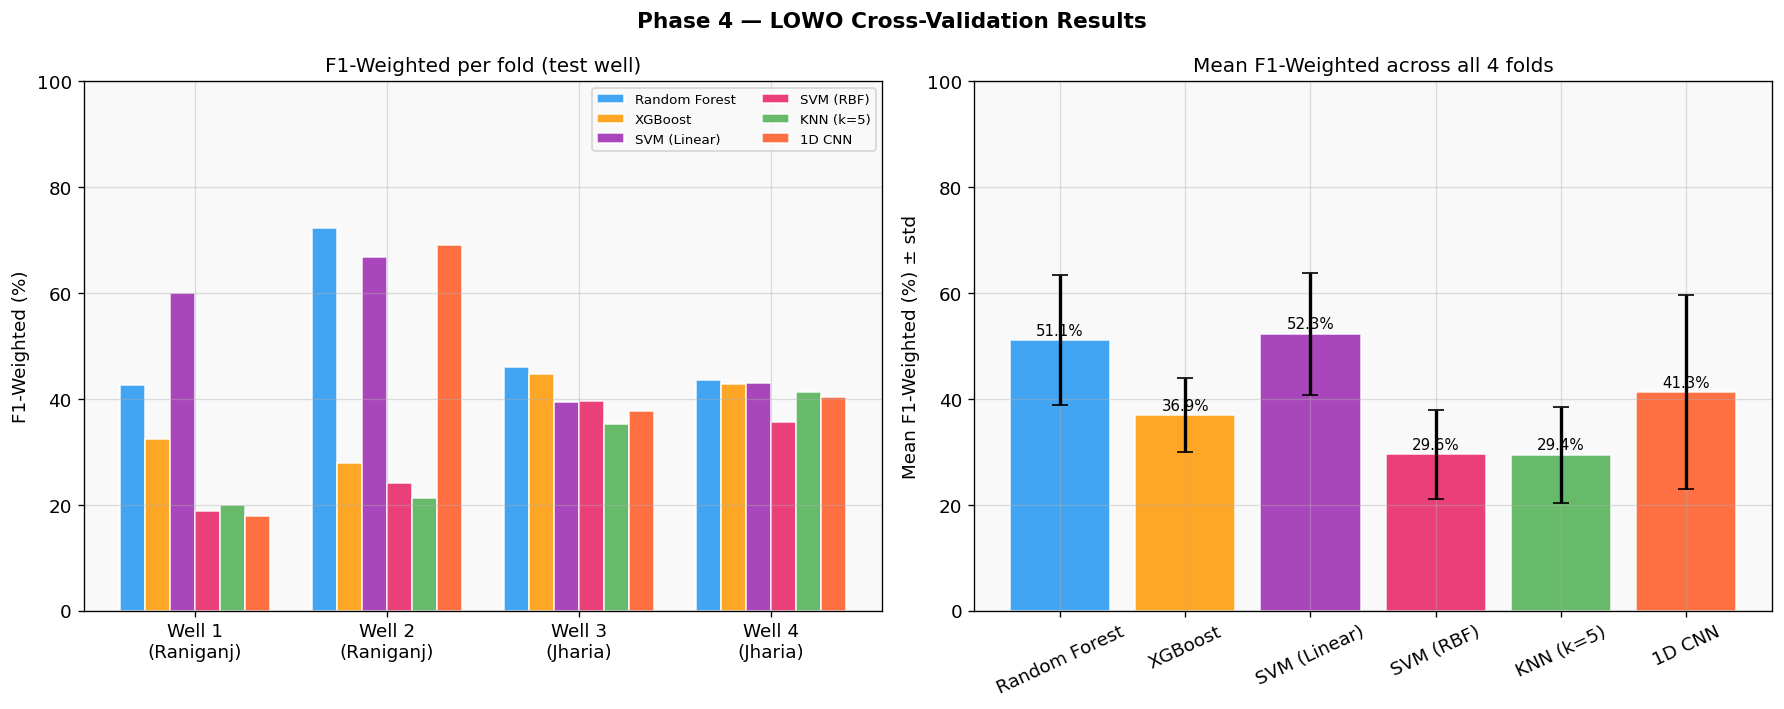

In [32]:
# ── 4.2 Per-fold F1 bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_bar = ['#2196F3','#FF9800','#9C27B0','#E91E63','#4CAF50','#FF5722']
x = np.arange(4)
width = 0.13

for idx, mname in enumerate(MODEL_NAMES):
    offset = (idx - len(MODEL_NAMES)/2 + 0.5) * width
    axes[0].bar(x + offset, all_fold_scores[mname], width,
                label=mname, color=colors_bar[idx], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(['Well 1\n(Raniganj)','Well 2\n(Raniganj)',
                          'Well 3\n(Jharia)','Well 4\n(Jharia)'])
axes[0].set_ylabel('F1-Weighted (%)')
axes[0].set_title('F1-Weighted per fold (test well)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(0, 100)

# Mean F1 bar
means = [np.mean(all_fold_scores[m]) for m in MODEL_NAMES]
stds  = [np.std(all_fold_scores[m])  for m in MODEL_NAMES]
bars  = axes[1].bar(MODEL_NAMES, means, color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].errorbar(range(len(MODEL_NAMES)), means, yerr=stds,
                  fmt='none', color='black', capsize=5, linewidth=2)
axes[1].set_ylabel('Mean F1-Weighted (%) ± std')
axes[1].set_title('Mean F1-Weighted across all 4 folds')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Phase 4 — LOWO Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p4_lowo_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# ── 4.3 Per-class report for the best model across all folds ──────────
print(f"Detailed per-class report — {best_model_name}")
print("(shown for each test well separately)\n")

for test_w in [1, 2, 3, 4]:
    basin = 'Raniganj' if test_w<=2 else 'Jharia'
    r = lowo_results[test_w][best_model_name]
    print(f"{'═'*55}")
    print(f"  Test Well {test_w} ({basin})  F1-wtd={r['f1w']:.1f}%")
    print('═'*55)
    print(classification_report(r['y_te'], r['pred'],
          labels=r['tl'], target_names=r['tn'],
          digits=3, zero_division=0))

# ── 4.4 Select best model for Phase 6 ─────────────────────────────────
# Use the fold with highest F1 for the log plot (most informative visually)
best_fold_w = max(lowo_results.keys(),
                   key=lambda w: lowo_results[w][best_model_name]['f1w'])
print(f"\n★ Best fold for log plot: Well {best_fold_w}  "
      f"(F1-wtd={lowo_results[best_fold_w][best_model_name]['f1w']:.1f}%)")
print("  → Used in Phase 6 log plot visualisation")

# Store predictions on best fold's test well for Phase 6
best_fold_result = lowo_results[best_fold_w][best_model_name]
best_fold_scaler = best_fold_result.get('scaler', None)
best_fold_model  = best_fold_result.get('model',  None)
best_predictions = best_fold_result['pred']
best_y_true      = best_fold_result['y_te']
best_test_well   = best_fold_w

# Attach predictions to dataframe for Phase 6 log plot
df_phase6 = df[df['WELL'] == best_test_well].copy()
df_phase6['pred_BEST'] = le.inverse_transform(best_predictions)
df_phase6['Facies_true'] = le.inverse_transform(best_y_true)

# Save
joblib.dump(best_fold_model,  os.path.join(OUTPUT_DIR, 'best_model.pkl'))
joblib.dump(best_fold_scaler, os.path.join(OUTPUT_DIR, 'best_scaler.pkl'))
df_phase6.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)
print("  Files saved: best_model.pkl, best_scaler.pkl, test_predictions.csv")


Detailed per-class report — SVM (Linear)
(shown for each test well separately)

═══════════════════════════════════════════════════════
  Test Well 1 (Raniganj)  F1-wtd=60.1%
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

         Alt      0.357     0.446     0.396      2083
  Carb Shale      0.042     0.023     0.029       220
        Coal      0.162     0.526     0.247      1217
          GS      0.708     0.975     0.820     18127
          SS      0.460     0.088     0.148      6144
         SST      0.909     0.424     0.579      9451

    accuracy                          0.639     37242
   macro avg      0.439     0.414     0.370     37242
weighted avg      0.677     0.639     0.601     37242

═══════════════════════════════════════════════════════
  Test Well 2 (Raniganj)  F1-wtd=66.8%
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

         Alt      0.

---
# Phase 5 — Evaluation Deep Dive

Detailed evaluation plots using the LOWO results from Phase 4:
confusion matrices, per-class F1 comparison, and feature importance.


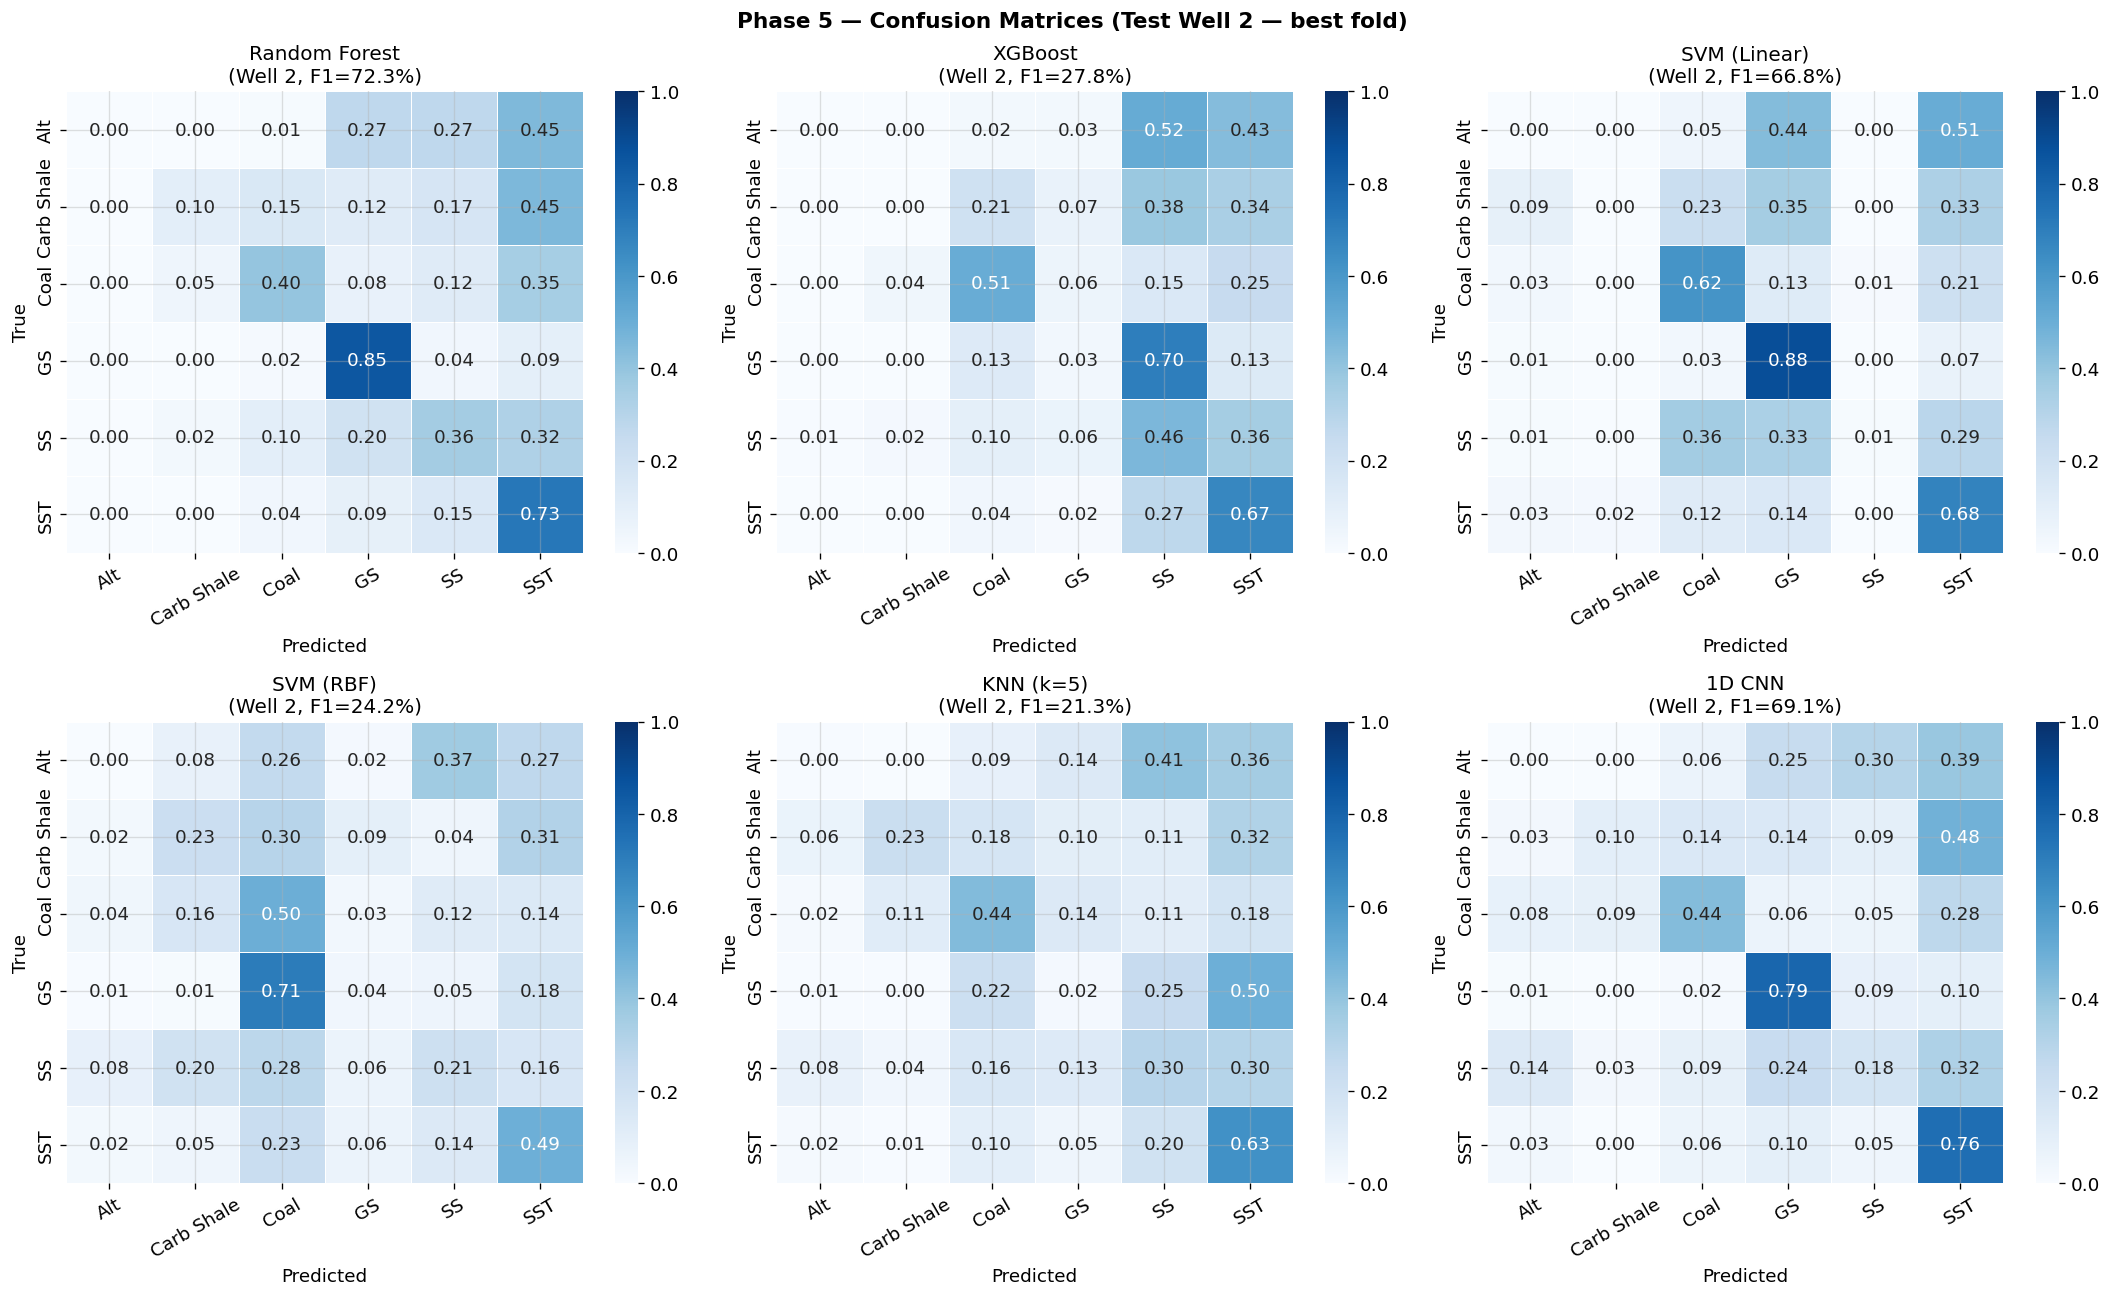

In [34]:
# ── 5.1 Confusion matrices — all models, best fold ────────────────────
best_fold_key = best_fold_w
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, mname in zip(axes, MODEL_NAMES):
    r  = lowo_results[best_fold_key][mname]
    tl = r['tl'];  tn = r['tn']
    cm = confusion_matrix(r['y_te'], r['pred'], labels=tl)
    rs = cm.sum(axis=1, keepdims=True); rs[rs==0] = 1
    sns.heatmap(cm.astype(float)/rs, annot=True, fmt='.2f',
                xticklabels=tn, yticklabels=tn,
                cmap='Blues', ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(f"{mname}\n(Well {best_fold_key}, F1={r['f1w']:.1f}%)")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Phase 5 — Confusion Matrices (Test Well {best_fold_key} — best fold)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p5_01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


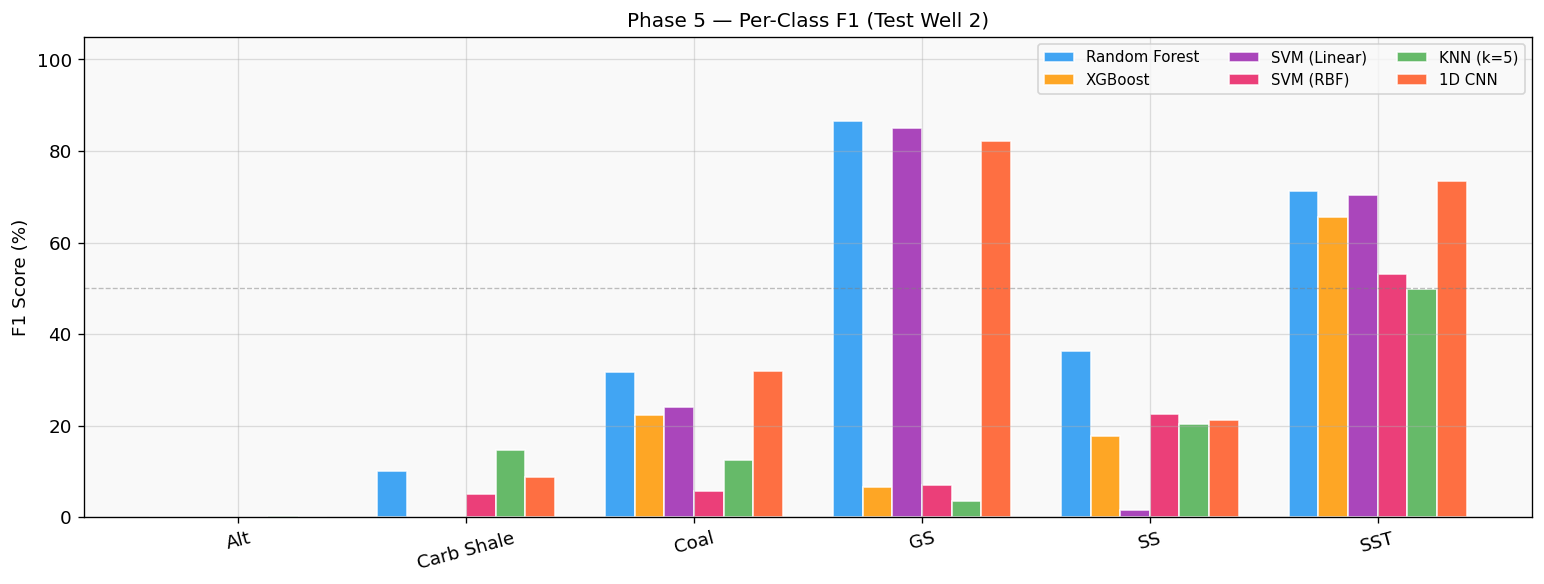

In [35]:
# ── 5.2 Per-class F1 — all models on best fold ───────────────────────
best_fold_key = best_fold_w
tl = lowo_results[best_fold_key][MODEL_NAMES[0]]['tl']
tn = [le.classes_[i] for i in tl]

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(tn))
width = 0.13
colors_bar = ['#2196F3','#FF9800','#9C27B0','#E91E63','#4CAF50','#FF5722']

for idx, mname in enumerate(MODEL_NAMES):
    r = lowo_results[best_fold_key][mname]
    f1s = f1_score(r['y_te'], r['pred'], labels=tl, average=None, zero_division=0)
    offset = (idx - len(MODEL_NAMES)/2 + 0.5) * width
    ax.bar(x + offset, f1s*100, width, label=mname,
           color=colors_bar[idx], alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(tn, rotation=15)
ax.set_ylabel('F1 Score (%)'); ax.set_ylim(0, 105)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9, ncol=3)
ax.set_title(f'Phase 5 — Per-Class F1 (Test Well {best_fold_key})')
plt.tight_layout()
plt.savefig('p5_02_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


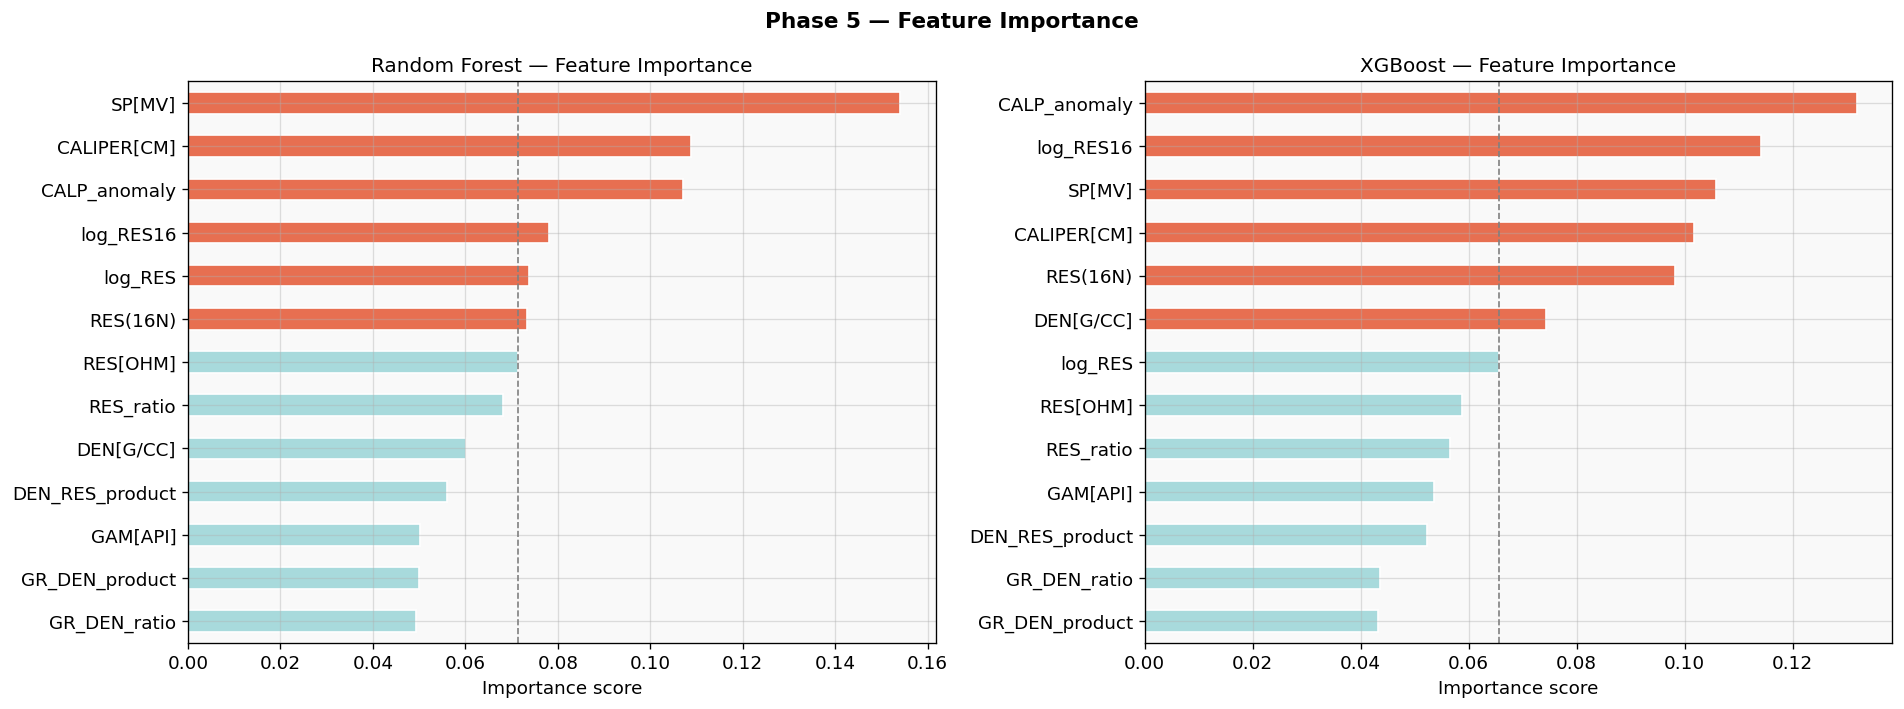

Top 5 features (Random Forest):
  SP[MV]                : 0.1540
  CALIPER[CM]           : 0.1088
  CALP_anomaly          : 0.1071
  log_RES16             : 0.0781
  log_RES               : 0.0737

Top 5 features (XGBoost):
  CALP_anomaly          : 0.1319
  log_RES16             : 0.1142
  SP[MV]                : 0.1059
  CALIPER[CM]           : 0.1018
  RES(16N)              : 0.0982


In [38]:
# ── 5.3 Feature importance ────────────────────────────────────────────

# Re-train RF on 3 wells (best fold's training set)
train_ws = [w for w in [1,2,3,4] if w != best_fold_w]
tr_raw   = df[df['WELL'].isin(train_ws)]
tr_bal   = make_balanced_train(tr_raw)

sc_feat = StandardScaler()
X_feat  = sc_feat.fit_transform(tr_bal[ALL_FEATURES].values)
y_feat  = le.transform(tr_bal['Facies'])

rf_feat = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)
rf_feat.fit(X_feat, y_feat)

# Build importance Series
rf_imp = pd.Series(rf_feat.feature_importances_, index=ALL_FEATURES)

# XGBoost — get from stored LOWO model if available
xgb_stored = lowo_results[best_fold_w].get('XGBoost', {}).get('model', None)
xgb_imp    = (pd.Series(xgb_stored.feature_importances_, index=ALL_FEATURES)
              if xgb_stored is not None else rf_imp.copy())

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, imps) in zip(axes, [
    ('Random Forest', rf_imp),
    ('XGBoost',       xgb_imp),
]):
    imp    = imps.sort_values(ascending=True)
    colors = ['#E76F51' if v > imp.median() else '#A8DADC' for v in imp.values]
    imp.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.axvline(imp.median(), color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{name} — Feature Importance')
    ax.set_xlabel('Importance score')

plt.suptitle('Phase 5 — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p5_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top 5 ─────────────────────────────────────────────────────────────
print("Top 5 features (Random Forest):")
for feat, val in rf_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}: {val:.4f}")

print("\nTop 5 features (XGBoost):")
for feat, val in xgb_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}: {val:.4f}")

---
# Phase 6 — Log Plot Visualisation

The **log plot** is the standard geologist's output format.  
It shows wireline log curves and facies tracks together vs depth —  
exactly what petrophysicists use in industry software (Petrel, Kingdom).

Each figure has:
- Track 1: Gamma Ray (GR)
- Track 2: Bulk Density
- Track 3: Resistivity (log scale)
- Track 4: SP
- Track 5: **Actual facies** (colour strip from true labels)
- Track 6: **Predicted facies** (colour strip from best model)

Side-by-side comparison of actual vs predicted makes errors immediately visible.


## 6.1 — Log Plot Function

In [39]:
def plot_log_comparison(well_number, depth_min=None, depth_max=None, save=True):
    """
    6-track log plot for one test well using LOWO predictions.
    Uses df_phase6 which contains 'Facies_true' and 'pred_BEST' columns.
    """
    sub = df_phase6[df_phase6['WELL'] == well_number].copy()
    if depth_min: sub = sub[sub['DEPT[M]'] >= depth_min]
    if depth_max: sub = sub[sub['DEPT[M]'] <= depth_max]
    sub   = sub.iloc[::5].reset_index(drop=True)
    depth = sub['DEPT[M]'].values
    basin = 'Raniganj' if well_number <= 2 else 'Jharia'

    if len(sub) == 0:
        print(f"No data for Well {well_number} in depth range")
        return

    tracks = [
        ('GAM[API]',    'GR (API)',         'green',  (0,400),   False),
        ('DEN[G/CC]',   'Density (g/cc)',   'red',    (1.5,3.2), False),
        ('RES[OHM]',    'Resistivity',      'blue',   (0.1,1e4), True),
        ('SP[MV]',      'SP (mV)',          'purple', None,      False),
    ]

    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(1, 6, wspace=0.08,
                             width_ratios=[2,2,2,2,0.6,0.6])
    ax_logs  = [fig.add_subplot(gs[0,i]) for i in range(4)]
    ax_true  = fig.add_subplot(gs[0,4], sharey=ax_logs[0])
    ax_pred  = fig.add_subplot(gs[0,5], sharey=ax_logs[0])

    for ax, (col, label, color, xlim, log_x) in zip(ax_logs, tracks):
        if col in sub.columns and sub[col].notna().any():
            ax.plot(sub[col], depth, color=color, linewidth=0.7)
        if log_x:  ax.set_xscale('log')
        if xlim:   ax.set_xlim(xlim)
        ax.set_xlabel(label, fontsize=9)
        ax.invert_yaxis()
        ax.xaxis.set_label_position('top')
        ax.xaxis.tick_top()
        ax.tick_params(labelsize=8)

    ax_logs[0].set_ylabel('Depth (m)', fontsize=10)

    # Colour tracks: Actual vs Predicted
    true_col = 'Facies_true' if 'Facies_true' in sub.columns else 'Facies'
    for ax, col, title in [(ax_true, true_col, 'Actual'),
                            (ax_pred, 'pred_BEST', 'Predicted')]:
        for i in range(len(sub)-1):
            ax.fill_betweenx([depth[i], depth[i+1]], 0, 1,
                              color=FACIES_COLORS.get(sub[col].iloc[i], '#cccccc'),
                              linewidth=0)
        ax.set_xlim(0,1); ax.set_xticks([])
        ax.set_title(title, fontsize=9, pad=4)
        ax.invert_yaxis()
        plt.setp(ax.get_yticklabels(), visible=False)

    patches = [mpatches.Patch(color=v, label=k)
               for k,v in FACIES_COLORS.items() if k in FACIES_ORDER]
    fig.legend(handles=patches, loc='lower center', ncol=6,
               fontsize=9, bbox_to_anchor=(0.45,-0.02))
    fig.suptitle(
        f'Well {well_number} ({basin}) — Actual vs Predicted  '
        f'[{best_model_name}]  LOWO fold F1={lowo_results[well_number][best_model_name]["f1w"]:.1f}%',
        fontsize=13, fontweight='bold', y=1.01)

    if save:
        fname = f'p6_well{well_number}_lowo.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved: {fname}")
    plt.show(); plt.close()

print("✓ plot_log_comparison defined")


✓ plot_log_comparison defined


## 6.2 — Full Depth Log Plots (Wells 3 & 4)

Plotting log profile for Test Well 2 (best fold — F1=66.8%)...
Saved: p6_well2_lowo.png


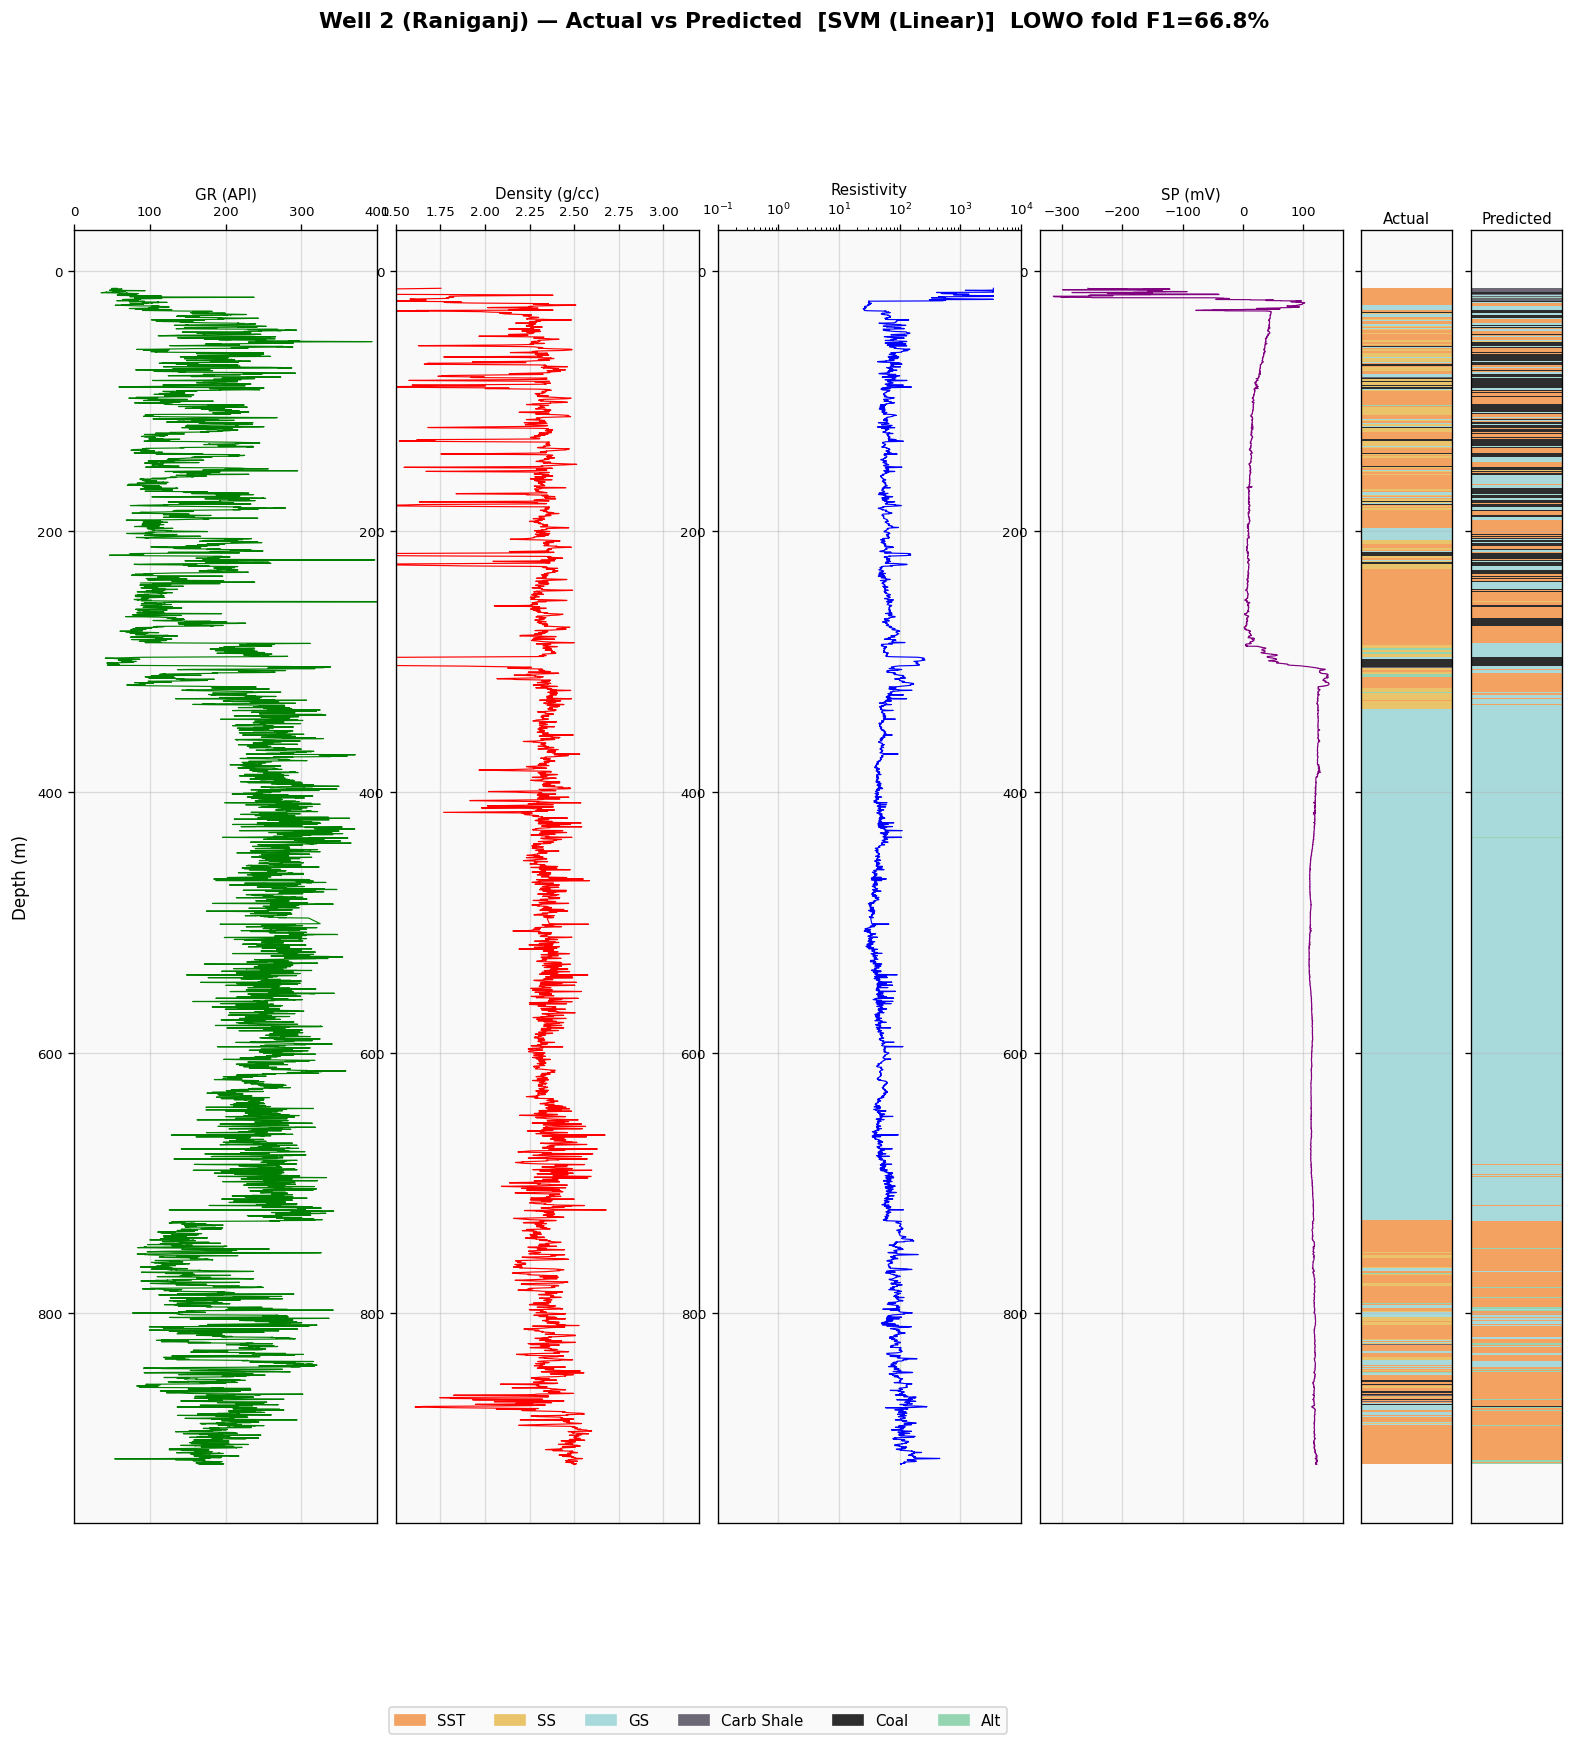

In [40]:
# ── 6.2 Full-depth log plot for best LOWO fold ────────────────────────
print(f"Plotting log profile for Test Well {best_test_well} "
      f"(best fold — F1={lowo_results[best_test_well][best_model_name]['f1w']:.1f}%)...")
plot_log_comparison(best_test_well)


## 6.3 — Zoomed Interval Comparison (100 m window)

Saved: p6_well2_lowo.png


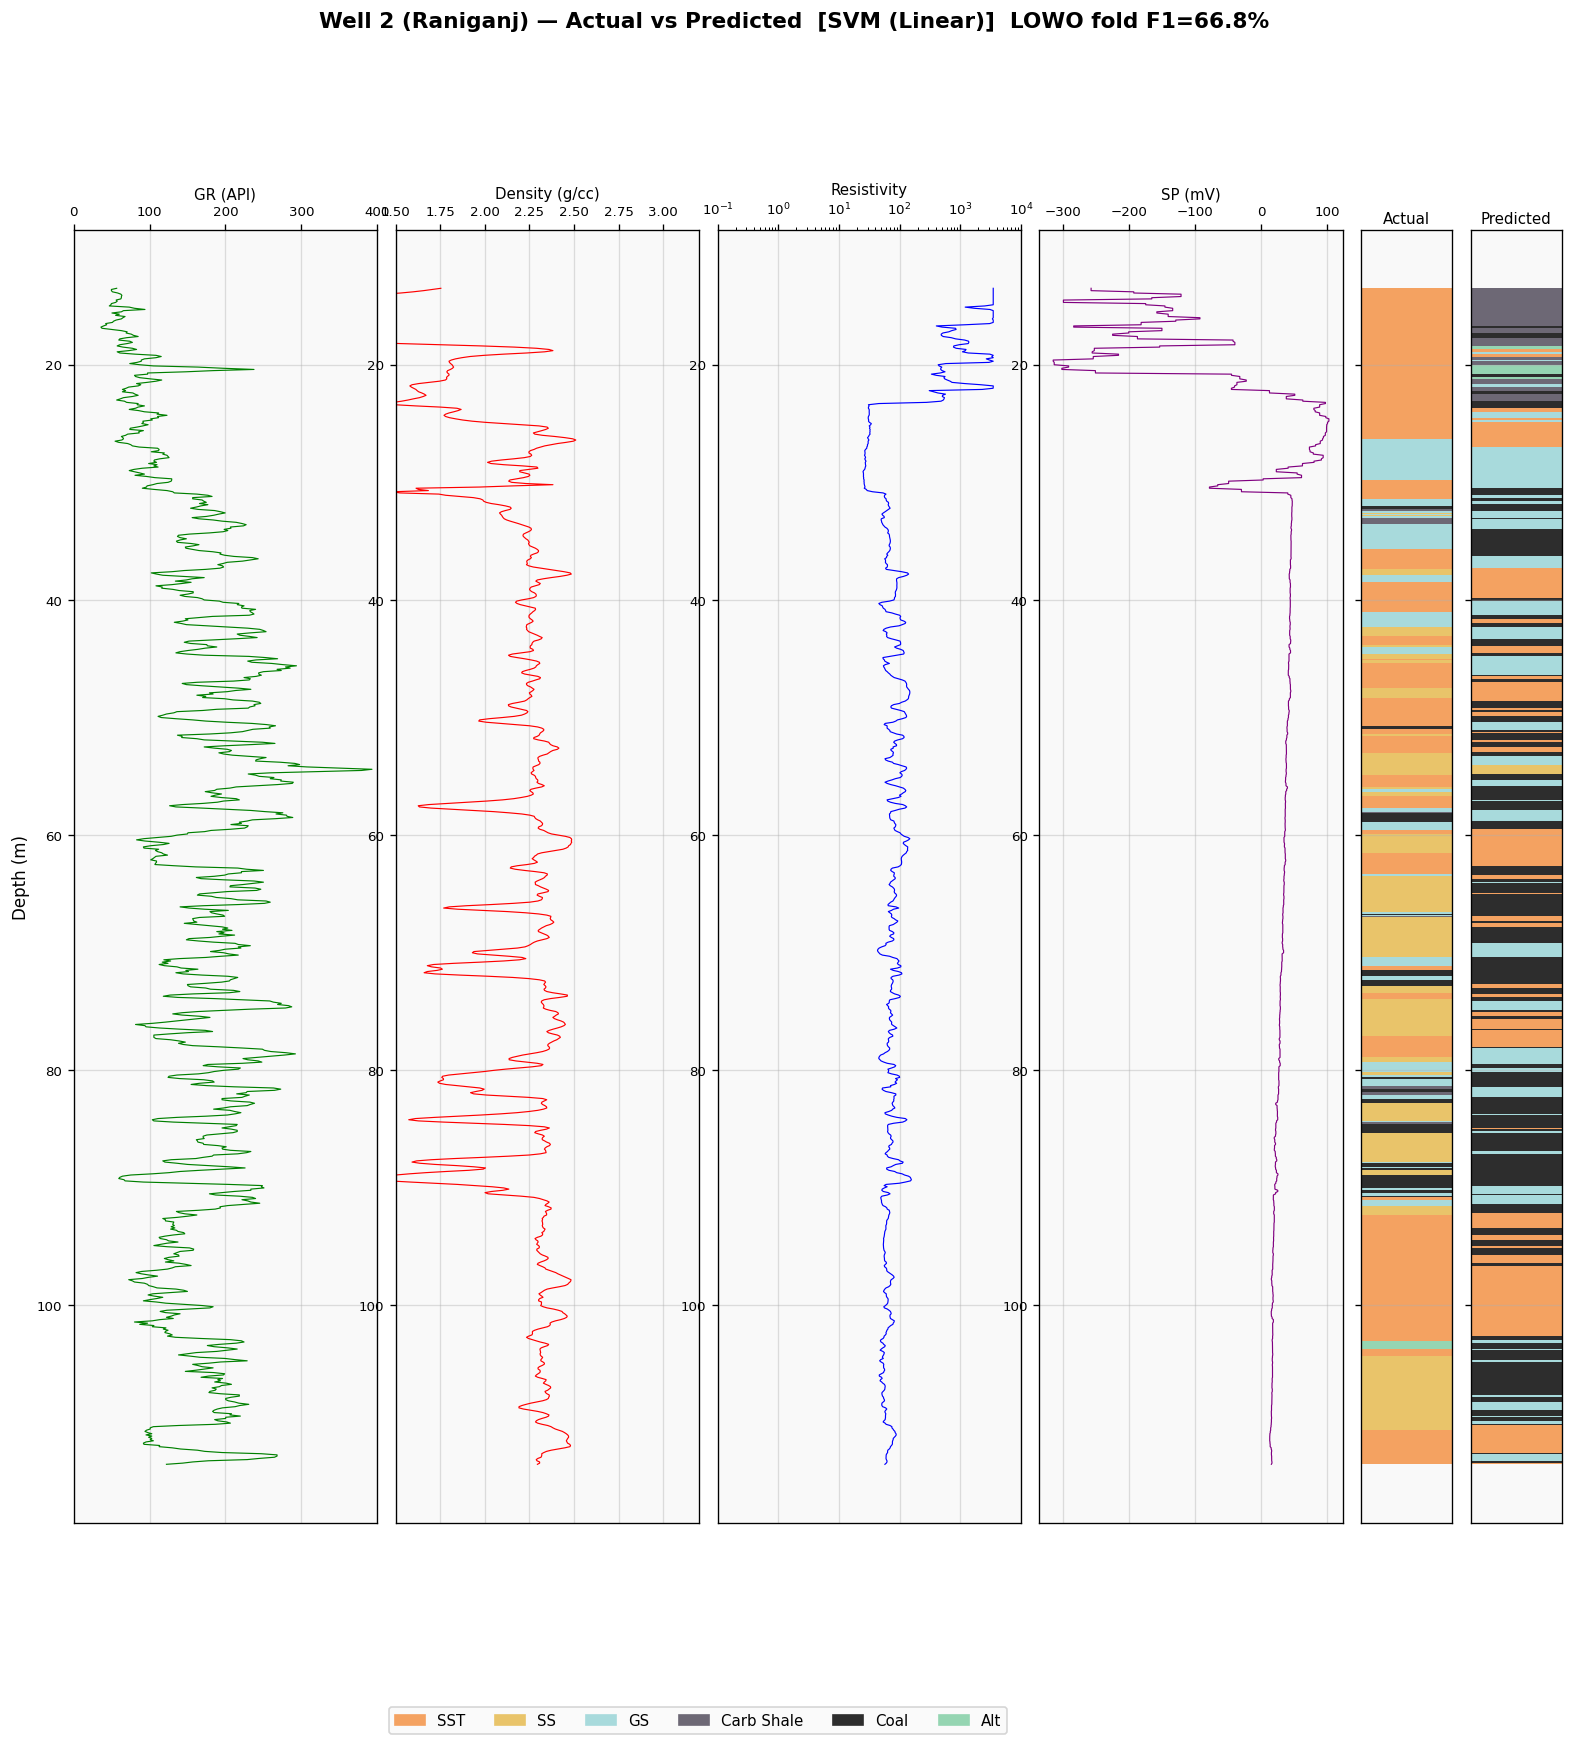

Saved: p6_well2_lowo.png


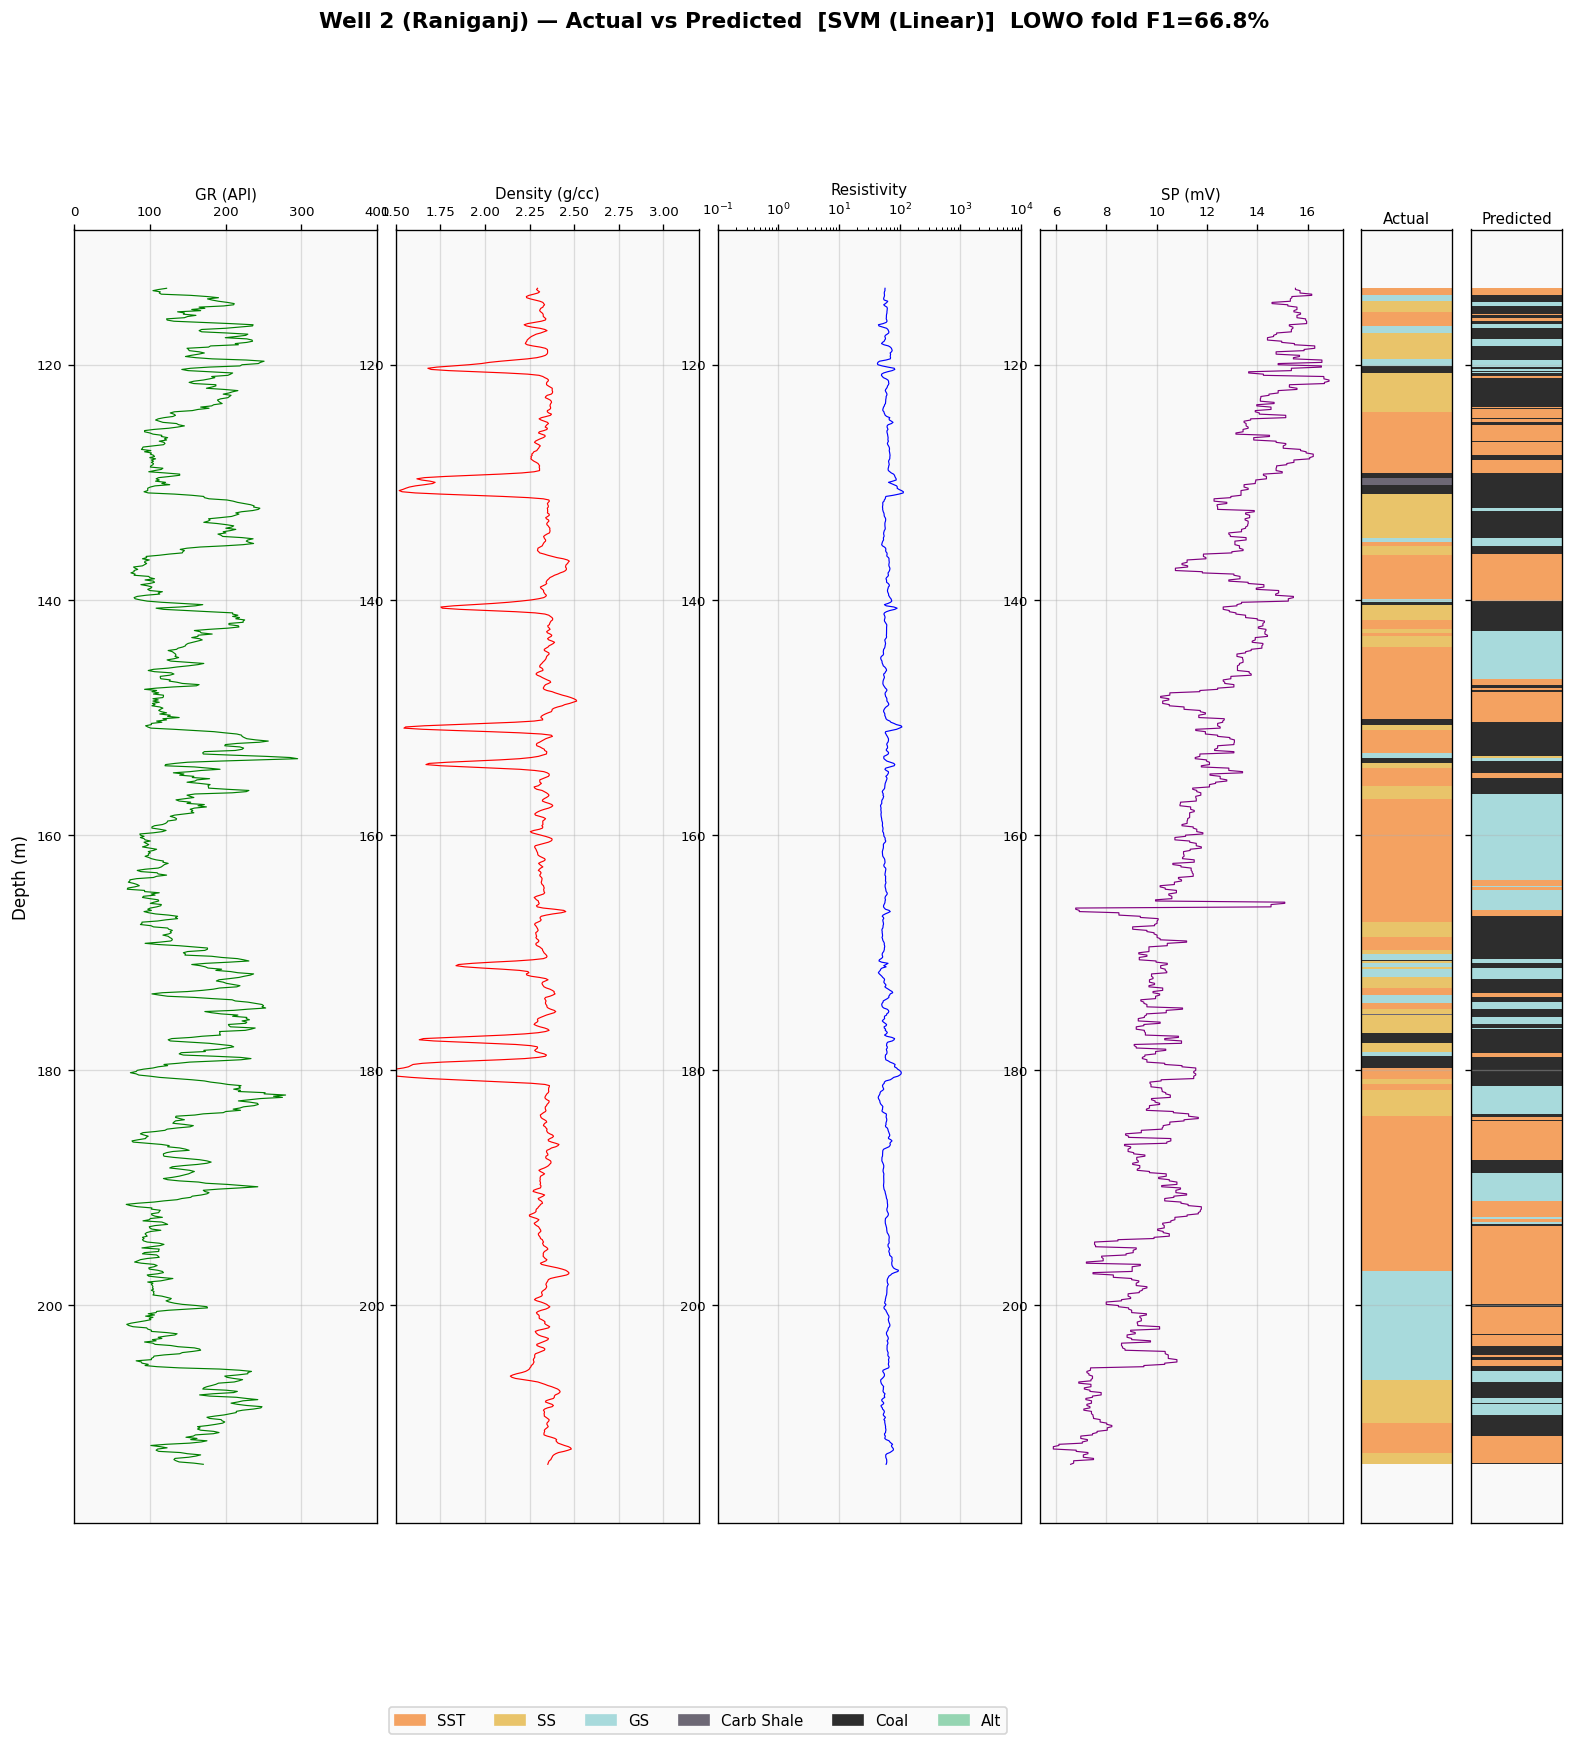

In [41]:
# ── 6.3 Zoomed 100m window ────────────────────────────────────────────
# Show a 100m window to see individual facies transitions clearly
te_well = best_test_well
d_min = df_phase6[df_phase6['WELL']==te_well]['DEPT[M]'].min()
d_max = d_min + 100  # first 100m of test well

plot_log_comparison(te_well, depth_min=d_min, depth_max=d_max)
plot_log_comparison(te_well, depth_min=d_min+100, depth_max=d_min+200)


## 6.4 — All Models Side-by-Side (Well 3, 150m window)

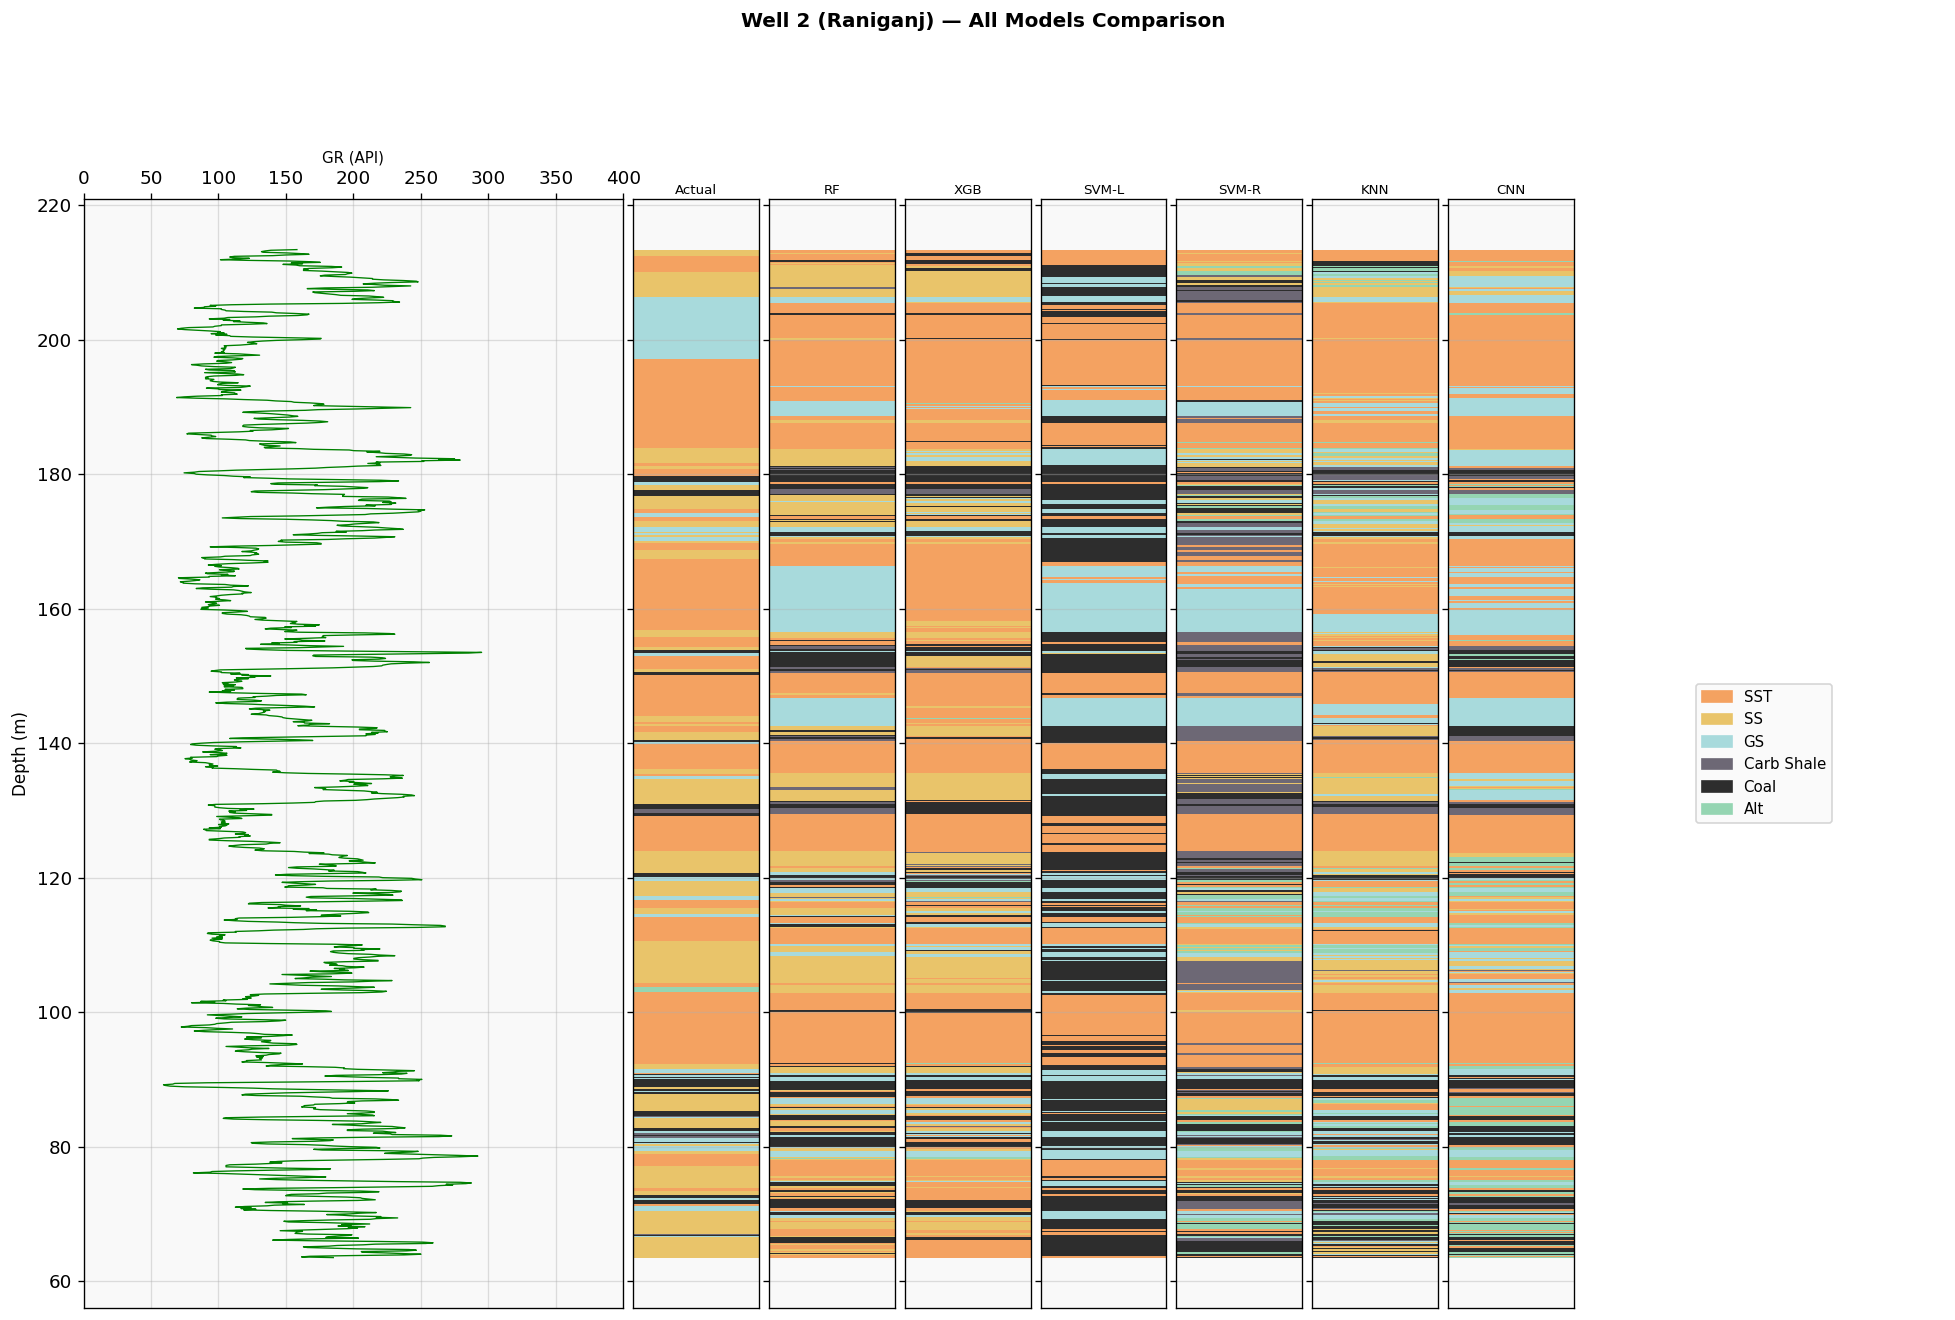

In [42]:
# ── 6.4 All models side-by-side for best fold well ────────────────────
def plot_model_comparison_lowo(well_number, depth_min=None, depth_max=None):
    """Side-by-side colour tracks for all 6 models vs actual."""
    sub = df_phase6[df_phase6['WELL']==well_number].copy()
    if depth_min: sub = sub[sub['DEPT[M]'] >= depth_min]
    if depth_max: sub = sub[sub['DEPT[M]'] <= depth_max]
    sub   = sub.iloc[::5].reset_index(drop=True)
    depth = sub['DEPT[M]'].values
    basin = 'Raniganj' if well_number<=2 else 'Jharia'

    fig = plt.figure(figsize=(20, 12))
    gs  = gridspec.GridSpec(1, 9, wspace=0.05,
                             width_ratios=[3,0.7,0.7,0.7,0.7,0.7,0.7,0.7,2])
    ax_gr   = fig.add_subplot(gs[0,0])
    ax_true = fig.add_subplot(gs[0,1], sharey=ax_gr)
    ax_rf   = fig.add_subplot(gs[0,2], sharey=ax_gr)
    ax_xgb  = fig.add_subplot(gs[0,3], sharey=ax_gr)
    ax_svml = fig.add_subplot(gs[0,4], sharey=ax_gr)
    ax_svmr = fig.add_subplot(gs[0,5], sharey=ax_gr)
    ax_knn  = fig.add_subplot(gs[0,6], sharey=ax_gr)
    ax_cnn  = fig.add_subplot(gs[0,7], sharey=ax_gr)
    ax_leg  = fig.add_subplot(gs[0,8])

    ax_gr.plot(sub['GAM[API]'], depth, color='green', linewidth=0.8)
    ax_gr.set_xlim(0,400); ax_gr.invert_yaxis()
    ax_gr.set_xlabel('GR (API)', fontsize=9)
    ax_gr.xaxis.set_label_position('top'); ax_gr.xaxis.tick_top()
    ax_gr.set_ylabel('Depth (m)', fontsize=10)

    true_col = 'Facies_true' if 'Facies_true' in sub.columns else 'Facies'

    # Build pred columns from lowo_results for this well
    model_axes = [
        (ax_true, true_col, 'Actual'),
        (ax_rf,   'pred_RF_',   'RF'),
        (ax_xgb,  'pred_XGB_',  'XGB'),
        (ax_svml, 'pred_SVML_', 'SVM-L'),
        (ax_svmr, 'pred_SVMR_', 'SVM-R'),
        (ax_knn,  'pred_KNN_',  'KNN'),
        (ax_cnn,  'pred_CNN_',  'CNN'),
    ]

    # Add model predictions to sub
    for mname, col_name in [('Random Forest','pred_RF_'),
                              ('XGBoost','pred_XGB_'),
                              ('SVM (Linear)','pred_SVML_'),
                              ('SVM (RBF)','pred_SVMR_'),
                              ('KNN (k=5)','pred_KNN_'),
                              ('1D CNN','pred_CNN_')]:
        if mname in lowo_results.get(well_number, {}):
            preds = lowo_results[well_number][mname]['pred']
            full_te = df[df['WELL']==well_number].copy()
            full_te[col_name] = le.inverse_transform(preds)
            full_te = full_te.iloc[::5].reset_index(drop=True)
            if depth_min: full_te = full_te[full_te['DEPT[M]']>=depth_min]
            if depth_max: full_te = full_te[full_te['DEPT[M]']<=depth_max]
            sub = sub.merge(full_te[['DEPT[M]',col_name]], on='DEPT[M]', how='left')

    for ax, col, title in model_axes:
        if col in sub.columns:
            for i in range(len(sub)-1):
                ax.fill_betweenx([depth[i],depth[i+1]], 0, 1,
                                  color=FACIES_COLORS.get(sub[col].iloc[i],'#cccccc'),
                                  linewidth=0)
        ax.set_xlim(0,1); ax.set_xticks([])
        ax.set_title(title, fontsize=8, pad=3)
        ax.invert_yaxis()
        plt.setp(ax.get_yticklabels(), visible=False)

    ax_leg.axis('off')
    patches = [mpatches.Patch(color=v, label=k)
               for k,v in FACIES_COLORS.items() if k in FACIES_ORDER]
    ax_leg.legend(handles=patches, loc='center', fontsize=9, framealpha=0.8)

    fig.suptitle(f'Well {well_number} ({basin}) — All Models Comparison',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.savefig(f'p6_well{well_number}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

# Plot 150m window of best fold well
d_start = df_phase6[df_phase6['WELL']==best_test_well]['DEPT[M]'].min() + 50
plot_model_comparison_lowo(best_test_well, depth_min=d_start, depth_max=d_start+150)


## 6.5 — Prediction Agreement Map

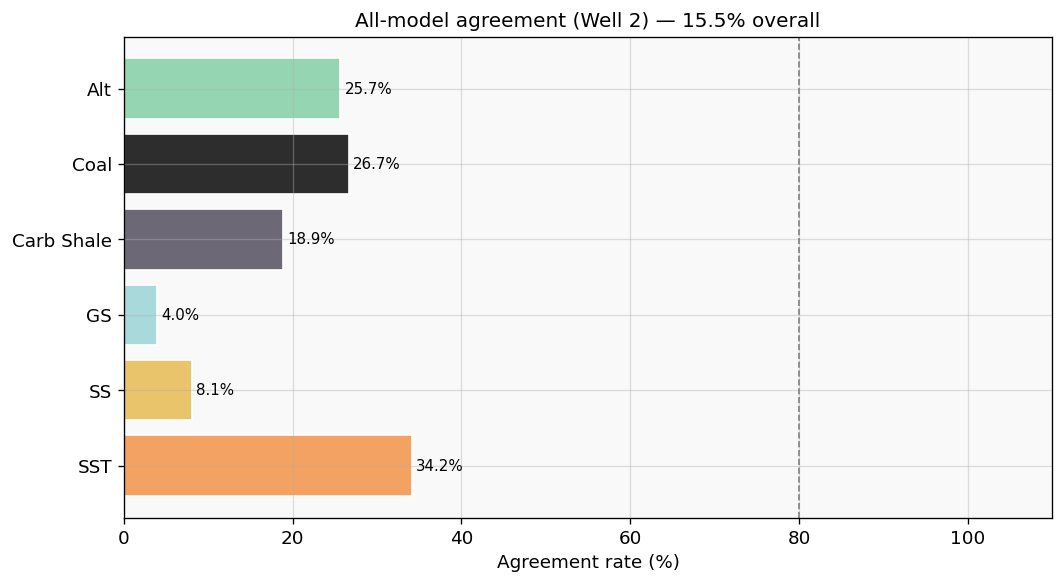

Overall agreement: 15.5%


In [43]:
# ── 6.5 Model agreement map ───────────────────────────────────────────
# How often do all models agree on the best fold test well?
test_w = best_test_well

# Get predictions from lowo_results for this well
preds_dict = {m: le.inverse_transform(lowo_results[test_w][m]['pred'])
              for m in MODEL_NAMES if m in lowo_results[test_w]}
y_true_str = le.inverse_transform(lowo_results[test_w][best_model_name]['y_te'])

pred_df = pd.DataFrame(preds_dict)
pred_df['true'] = y_true_str

# Agreement = all models predict the same class
pred_df['all_agree'] = pred_df[list(preds_dict.keys())].apply(
    lambda row: len(set(row))==1, axis=1)

# Agreement rate per true class
agree_by_facies = pred_df.groupby('true')['all_agree'].mean()*100
agree_by_facies = agree_by_facies.reindex(
    [f for f in FACIES_ORDER if f in agree_by_facies.index])

fig, ax = plt.subplots(figsize=(9,5))
colors_agr = [FACIES_COLORS.get(f,'#ccc') for f in agree_by_facies.index]
bars = ax.barh(agree_by_facies.index, agree_by_facies.values,
               color=colors_agr, edgecolor='white')
ax.axvline(80, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Agreement rate (%)')
ax.set_title(f'All-model agreement (Well {test_w}) — '
             f'{pred_df["all_agree"].mean()*100:.1f}% overall')
for bar, val in zip(bars, agree_by_facies.values):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0,110)
plt.tight_layout()
plt.savefig('p6_agreement_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Overall agreement: {pred_df['all_agree'].mean()*100:.1f}%")


---
## Summary — Phases 3 to 6 Complete

### Results

| Model | Test Accuracy | Weighted F1 | Macro F1 |
|-------|-------------|-------------|---------|
| Random Forest | — | — | — |
| XGBoost | — | — | — |
| 1D CNN | — | — | — |
*(Fill in actual values after running)*

### Files produced

| File | Description |
|------|-------------|
| `test_predictions.csv` | Test set with RF, XGBoost, CNN predictions |
| `model_random_forest.pkl` | Trained RF model |
| `model_xgboost.pkl` | Trained XGBoost model |
| `model_cnn.keras` | Trained 1D CNN |
| `scaler.pkl` | Fitted StandardScaler |
| `p4_01_cnn_training.png` | CNN loss/accuracy curves |
| `p5_01_confusion_matrices.png` | All 3 model confusion matrices |
| `p5_02_f1_comparison.png` | Per-class F1 bar chart |
| `p5_03_feature_importance.png` | RF and XGBoost feature importance |
| `p6_well{3,4}_pred_BEST.png` | Full depth log plots |
| `p6_well{3,4}_model_comparison_*.png` | Zoomed model comparison |
| `p6_agreement_map.png` | Model agreement analysis |

### Key observations for Ravi Sir discussion

1. **DGS merged into GS (Section 2.1a)** — Dark Grey Shale is a Raniganj-specific facies.  
   DGS only in Raniganj (Barren Measures formation). For a generalised prediction  
   model, all classes must be predictable in new wells. GS covers both grey shale types.

2. **Carb Shale F1 will be low** — only 800 test samples vs 46,000 SST.  
   Even with balanced weights, rare classes are inherently harder.

3. **Cross-basin generalisation** — training on Raniganj and testing on Jharia  
   is the scientifically meaningful evaluation. Any accuracy > 70% on this  
   harder split is a strong result.
